# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 6. Компьютерное зрение & генеративные модели


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание:**

* Задача 1 &mdash; 120 баллов
* Задача 2 &mdash; 80 баллов
* Задача 3 &mdash; 30 баллов

In [ ]:
# Bot check

# HW_ID: fpmi_ad6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
# При необходимости установите библиотеки, например, раскомментируйте строку ниже
!pip install torchinfo

In [2]:
import warnings
from typing import Union

import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms

sns.set(font_scale=1, style="darkgrid", palette="Set2")
warnings.simplefilter("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


Перед выполнением задания обязательно посмотрите <a href="https://thetahat.ru/files/ad/main/7/CV_intro no_pause.pdf" target="_blank">презентацию</a> и <a href="https://thetahat.ru/courses/ad/main/7/cv_classification" target="_blank">ноутбук</a> про сверточные сети и классификацию, а так же <a href="https://thetahat.ru/files/ad/main/7/CV_complex_no_pause.pdf" target="_blank">презентацию</a> и <a href="https://thetahat.ru/courses/ad/main/7/cv_complex_examples" target="_blank">ноутбук</a> про перенос стиля и генеративные сети.

&#x2757; **Весь код работы с библиотекой PyTorch необходимо написать самостоятельно, без использования ИИ-инструментов.** Но можно использовать код из ноутбуков, рассказанных на занятии. Можно использовать ИИ-инструменты для написания технического кода (например, построение графиков), оформления ранее написанного кода и в качестве справки. Выводы необходимо делать самостоятельно.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### Задача 1. Классификация MNIST


▫️ Инд. комм. Код определений моделей `model_4` и `model_5` не соответствует представленным для них результатам `summary`, что делает выводы по этим моделям некорректными и невоспроизводимыми.
<font color="green"> Перезапущены ячейки </font>
▫️ Эксп. 1: Неинформативный график из-за большого масштаба. Комм. Стоило настроить ограничения для лучшего восприятия информации с графика. Инд. комм. График лосса в первом эксперименте неинформативен, так как из-за большого масштаба по оси Y сложно сравнить между собой успешные модели.
<font color="red"> у всех моделей точность очень похожа. Есть разница только на первых эпохах. Не вижу смысла определять, какая из этих моделей лучше на сотые процента исходя из графика. Если хочется это посмотреть, есть summury </font>
▫️ Эксп. 1: Нет сравнения количества параметров моделей. Комм. При адекватном числе каналов у сверточного слоя гораздо меньше параметров, чем у линейного. Инд. комм. В выводе по эксперименту 1 отсутствует сравнение количества параметров у рассмотренных моделей.
<font color="green"> добавлен анализ </font>
▫️ В выводе упущены результаты наблюдей по разным конфигурациям сверточной сети. Инд. комм. В итоговом выводе по всей задаче отсутствуют результаты наблюдений из эксперимента 1, где сравнивались сети с разным числом слоев.
<font color="green"> Вывод дополнен</font>

В данной задаче вам нужно провести сравнительный анализ сверточных нейросетей с различными параметрами на датасета рукописных цифр MNIST. С этим датасетом вы уже познакомились в <a href="https://thetahat.ru/courses/ad/main/6/vvad_hw5">предыдущем задании</a>. Классификация в MNIST значительно проще, чем в CIFAR, рассмотренном на <a href="https://thetahat.ru/courses/ad/main/7/cv_classification" target="_blank">занятии</a>, поэтому ваша задача — достичь **на валидации** хотя бы одной из моделей точности 97%. Вы можете свободно использовать код с занятия.

> Использования слоев с семинара (свертка, pooling) более чем достаточно для достижения 97% точности на тесте. Также не делайте сеть глубокой.

> Тестируйте работоспособность кода на CPU с небольшим количеством итераций. Если все работает, и хочется ускорить процесс, переходите на GPU.

Следуйте указаниям ниже.

**1.** Загрузим датаcет из `torchvision.datasets`.

In [3]:
# импорты
import time
import warnings
from collections import defaultdict
from typing import Callable, Dict, List, Tuple, Optional, Union

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn, optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchinfo import summary
from torchvision.transforms.functional import to_tensor, rgb_to_grayscale
from torch.utils.data import DataLoader
import torchvision.models as models

from IPython.display import clear_output

In [4]:
# Данные для обучения
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
# Данные для тестирования
val_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transforms.ToTensor()
)
# Классы объектов в датасете
num_classes = 10
classes_list = [str(i) for i in range(num_classes)]

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


Создайте генераторы батчей.

In [5]:
from torch.utils.data import DataLoader

batch_size = 64  # размер батча

train_batch_gen = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_batch_gen = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [21]:
def plot_histories(histories: List[Dict[str, Dict[str, list]]], names: List[str]) -> None:
    """
    Визуализирует лосс и точность для нескольких моделей на одном графике.

    Параметры:
        histories (List[Dict[str, Dict[str, list]]]): Список историй обучения моделей.
            Каждая история должна содержать ключи "loss" и "acc" с подключами "train" и "val".
        names (List[str]): Список названий моделей для легенды.

    Возвращает:
        None
    """
    # Устанавливаем стиль "darkgrid" только для текущего графика
    with sns.axes_style("darkgrid"):
        # Цвета для графиков
        colors = ["darkblue", "lightcoral", "limegreen", "sandybrown",  "purple"]

        # Создаем фигуру с двумя подграфиками
        fig, axs = plt.subplots(1, 2, figsize=(14, 5))

        # Определяем количество эпох для отображения (минимальное среди всех историй)
        epochs = np.min([len(h["loss"]["train"]) for h in histories])

        # Построение графиков для каждой модели
        for i, (history, name) in enumerate(zip(histories, names)):
            # График лосса
            axs[0].set_title("Лосс")
            axs[0].plot(
                history["loss"]["train"][:epochs],
                label=f"{name}",
                lw=2,
                c=colors[i],
                ls="--",
            )
            axs[0].plot(
                history["loss"]["val"][:epochs],
                lw=1.5,
                c=colors[i],
            )
            axs[0].set_xlabel("Номер эпохи")

            # График точности
            axs[1].set_title("Точность классификации")
            axs[1].plot(
                history["acc"]["train"][:epochs], label=f"{name}", lw=2, c=colors[i], ls="--"
            )
            axs[1].plot(history["acc"]["val"][:epochs], lw=1.5, c=colors[i])
            axs[1].set_xlabel("Номер эпохи")
            axs[1].legend()

        # Создаем фиктивные линии для легенды (train и val)
        dummy_lines = [
            axs[0].plot([], [], c="black", lw=2, ls="--")[0],
            axs[0].plot([], [], c="black", lw=1.5)[0],
        ]

        # Добавляем легенду для типов линий (train и val)
        for i in range(2):
            legend = axs[i].legend(loc=3 - i)  # Легенда для моделей
            axs[i].legend(dummy_lines, ["train", "val"], loc=4)  # Легенда для типов линий
            axs[i].add_artist(legend)  # Добавляем обе легенды на график

        plt.show()


def print_epoch(epoch, num_epochs, history, t):
    """
    Функция для вывода информации про эпоху.
    :param epoch: номер эпохи
    :param num_epochs: общее количество эпох
    :param history: (dict) accuracy и loss на обучении и валидации ("история" обучения)
    :param t: время эпохи в секундах
    """
    clear_output(wait=True)
    print("Эпоха {} из {}, затраченное время {:.3f} сек.".format(epoch + 1, num_epochs, t))
    print("  лосс на обучении: \t{:.6f}".format(history["loss"]["train"][-1]))
    print("  лосс на валидации: \t{:.6f}".format(history["loss"]["val"][-1]))
    print("  точность на обучении: \t\t{:.2f} %".format(history["acc"]["train"][-1] * 100))
    print("  точность на валидации: \t\t{:.2f} %".format(history["acc"]["val"][-1] * 100))

    # Строим графики лосса и точности
    plot_histories([history], ["Model"])


def update_history(
    history: Dict[str, Dict[str, list]], loss: float, acc: float, num_batches: int, mode: str
) -> None:
    """
    Обновляет историю обучения, добавляя в нее loss и accuracy для текущей эпохи.

    Параметры:
        history (Dict[str, Dict[str, list]]): Словарь с историей обучения.
        loss (float): Суммарный loss за эпоху.
        acc (float): Суммарная точность за эпоху.
        num_batches (int): Количество батчей в эпохе.
        mode (str): Режим обучения ("train" или "val").
    """
    # Нормализуем loss и accuracy по количеству батчей
    loss /= num_batches
    acc /= num_batches
    history["loss"][mode].append(loss)
    history["acc"][mode].append(acc)


def get_batch_loss(
    X_batch: torch.Tensor,
    y_batch: torch.Tensor,
    model: nn.Module,
    criterion: Callable,
    current_loss: float,
    current_acc: float,
) -> Tuple[torch.Tensor, float, float]:
    """
    Вычисляет loss и accuracy для одного батча (без backward pass).

    Параметры:
        X_batch (torch.Tensor): Батч входных данных.
        y_batch (torch.Tensor): Батч меток.
        model (nn.Module): Модель для обучения (выдает логиты).
        criterion (Callable): Функция потерь.
        current_loss (float): Текущий лосс за батч.
        current_acc (float): Текущая точность за батч.

    Возвращает:
        Tuple[torch.Tensor, float, float]: Лосс на батче, обновленные суммарные loss и accuracy.
    """
    # Перемещаем данные на устройство (GPU/CPU)
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    # Получаем логиты от модели
    logits = model(X_batch)

    # Вычисляем loss
    loss = criterion(logits, y_batch.long().to(device))

    # Сохраняем лоссы и точность
    current_loss += loss.detach().cpu().numpy()
    y_pred = logits.max(1)[1].detach().cpu().numpy()
    current_acc += np.mean(y_batch.cpu().numpy() == y_pred)
    return loss, current_loss, current_acc


def train(
    model: nn.Module,
    criterion: Callable,
    optimizer: optim.Optimizer,
    train_batch_gen: DataLoader,
    val_batch_gen: DataLoader,
    num_epochs: int = 40,
) -> Dict[str, Dict[str, list]]:
    """
    Обучает модель и возвращает историю обучения.

    Параметры:
        model (nn.Module): Модель для обучения.
        criterion (Callable): Функция потерь.
        optimizer (optim.Optimizer): Оптимизатор.
        train_batch_gen (DataLoader): Генератор батчей для обучения.
        val_batch_gen (DataLoader): Генератор батчей для валидации.
        num_epochs (int): Количество эпох (по умолчанию 40).

    Возвращает:
        Dict[str, Dict[str, list]]: История обучения, содержащая loss и accuracy для обучения и валидации.
    """
    history = defaultdict(lambda: defaultdict(list))

    for epoch in range(num_epochs):
        train_loss, val_loss = 0, 0
        train_acc, val_acc = 0, 0
        start_time = time.time()

        # ----------------------   ОБУЧЕНИЕ   ----------------------#
        model.train(True)

        # На каждой "эпохе" делаем полный проход по данным
        for X_batch, y_batch in train_batch_gen:

            # Вычисляем loss и accuracy для батча
            loss, train_loss, train_acc = get_batch_loss(
                X_batch, y_batch, model, criterion, train_loss, train_acc
            )

            # Обратный проход, вычисление градиентов
            loss.backward()
            # Шаг градиентного спуска для обновления оценок весов
            optimizer.step()
            # Зануление градиентов
            optimizer.zero_grad()

        # Обновляем историю обучения
        update_history(history, train_loss, train_acc, len(train_batch_gen), "train")

        # ----------------------   ВАЛИДАЦИЯ   ----------------------#
        model.train(False)

        # Контекстный менеджер, отключающий подсчет градиентов
        with torch.no_grad():
            # Полный проход по валидационному датасету
            for X_batch, y_batch in val_batch_gen:
                # Вычисляем loss и accuracy для батча
                _, val_loss, val_acc = get_batch_loss(
                    X_batch, y_batch, model, criterion, val_loss, val_acc
                )

        # Обновляем историю валидации
        update_history(history, val_loss, val_acc, len(val_batch_gen), "val")

        # Выводим информацию о текущей эпохе
        print_epoch(epoch, num_epochs, history, time.time() - start_time)
        history["time"]["epoch"].append(time.time() - start_time)

    return history

**2.** Создайте хотя бы 5 сверточных нейросетей с разным количеством линейных и сверточных слоев. Должен присутствовать хотя бы 1 сверточный слой и хотя бы 1 линейный слой. Для каждой посмотрите количество параметров с помощью `torchinfo.summary`. Никакие специальные слои, которые мы не изучали, использовать не нужно.

In [7]:
model_1 = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),   # (1,28,28) -> (8,28,28)
    nn.ReLU(),
    nn.MaxPool2d(2),  # (8,28,28) -> (8,14,14)

    nn.Flatten(),# -> 8*14*14
    nn.Linear(8 * 14 * 14, 10)
)

model_2 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (1,28,28) -> (16,28,28)
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=3, padding=1), # (16,28,28)-> (32,28,28)
    nn.ReLU(),
    nn.MaxPool2d(2), # (32,28,28)->(32,14,14)

    nn.Flatten(),  #32*14*14
    nn.Linear(32*14*14, 10)
)

model_3 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),                             # -> (32,14,14)

    nn.Flatten(),
    nn.Linear(32 * 14 * 14, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_4 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), # (16,28,28)
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=3, padding=1), # (32,28,28)
    nn.ReLU(),
    nn.MaxPool2d(2), #(32,14,14)

    nn.Conv2d(32, 64, kernel_size=3, padding=1), #(64,14,14)
    nn.ReLU(),
    nn.MaxPool2d(2),  #(64,7,7)

    nn.Conv2d(64, 64, kernel_size=3, padding=1), #(64,7,7)
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_5 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (16,28,28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 16, kernel_size=3, padding=1), #(16,28,28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=3, padding=1), # -> (32,28,28)
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),  # (32,14,14)

    nn.Conv2d(32, 32, kernel_size=3, padding=1), # -> (32,28,28)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, padding=1), # (64,14,14)
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),  #(64,7,7)

    nn.Conv2d(64, 64, kernel_size=3, padding=1), #(64,7,7)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

models_dict = {
    "model_1": model_1,
    "model_2": model_2,
    "model_3": model_3,
    "model_4": model_4,
    "model_5": model_5,
}

for model in models_dict.values():
    model.to(device)

Обучите сети, используя функцию потерь `nn.CrossEntropyLoss` и оптимизатор `torch.optim.SGD` с дефолтными параметрами.

Эпоха 15 из 15, затраченное время 8.926 сек.
  лосс на обучении: 	0.326484
  лосс на валидации: 	0.305255
  точность на обучении: 		90.60 %
  точность на валидации: 		91.36 %


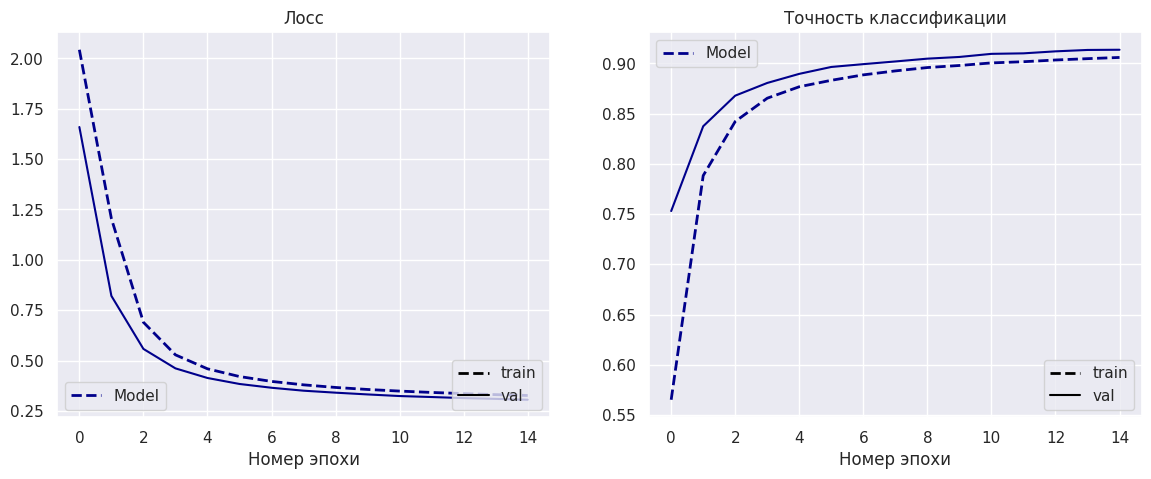

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters())
print("model 1")
history_model_1 = train(model_1,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [9]:
summary(model_1, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 8, 28, 28]            80
├─ReLU: 1-2                              [1, 8, 28, 28]            --
├─MaxPool2d: 1-3                         [1, 8, 14, 14]            --
├─Flatten: 1-4                           [1, 1568]                 --
├─Linear: 1-5                            [1, 10]                   15,690
Total params: 15,770
Trainable params: 15,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.06
Estimated Total Size (MB): 0.12

Эпоха 15 из 15, затраченное время 8.953 сек.
  лосс на обучении: 	0.284397
  лосс на валидации: 	0.269151
  точность на обучении: 		91.75 %
  точность на валидации: 		92.08 %


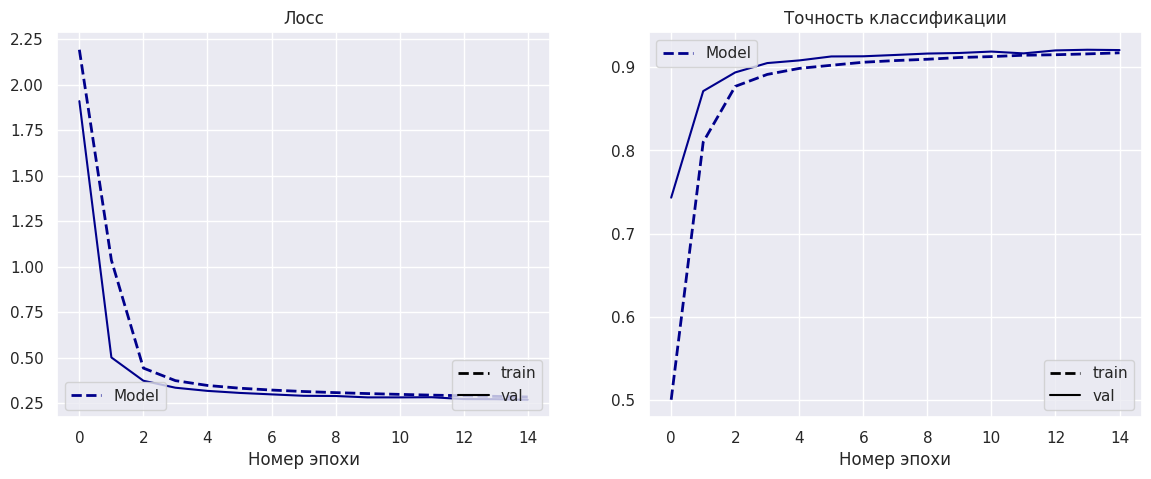

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters())
print("Model 2")
history_model_2 = train(model_2,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [11]:
summary(model_2, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─ReLU: 1-2                              [1, 16, 28, 28]           --
├─Conv2d: 1-3                            [1, 32, 28, 28]           4,640
├─ReLU: 1-4                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-5                         [1, 32, 14, 14]           --
├─Flatten: 1-6                           [1, 6272]                 --
├─Linear: 1-7                            [1, 10]                   62,730
Total params: 67,530
Trainable params: 67,530
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.83
Input size (MB): 0.00
Forward/backward pass size (MB): 0.30
Params size (MB): 0.27
Estimated Total Size (MB): 0.57

Эпоха 15 из 15, затраченное время 9.301 сек.
  лосс на обучении: 	0.209475
  лосс на валидации: 	0.196652
  точность на обучении: 		93.83 %
  точность на валидации: 		94.14 %


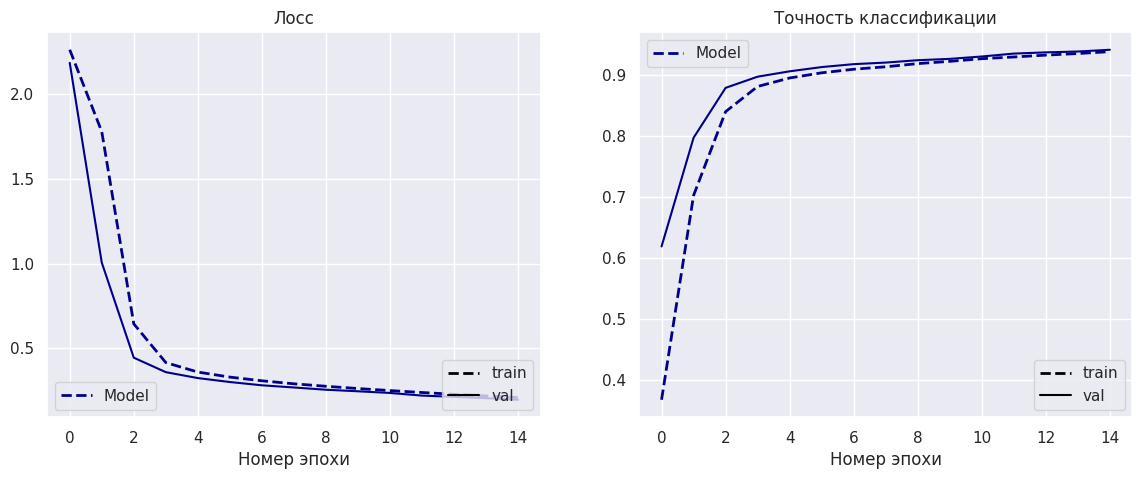

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_3.parameters())
print("Model 3")
history_model_3 = train(model_3,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [13]:
summary(model_3, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─ReLU: 1-2                              [1, 16, 28, 28]           --
├─Conv2d: 1-3                            [1, 32, 28, 28]           4,640
├─ReLU: 1-4                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-5                         [1, 32, 14, 14]           --
├─Flatten: 1-6                           [1, 6272]                 --
├─Linear: 1-7                            [1, 128]                  802,944
├─ReLU: 1-8                              [1, 128]                  --
├─Linear: 1-9                            [1, 10]                   1,290
Total params: 809,034
Trainable params: 809,034
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.57
Input size (MB): 0.00
Forward/backward pass size (MB): 0.30
Params size (MB): 3.24
Estimated Total Si

Эпоха 15 из 15, затраченное время 10.204 сек.
  лосс на обучении: 	0.497891
  лосс на валидации: 	0.416526
  точность на обучении: 		85.38 %
  точность на валидации: 		87.96 %


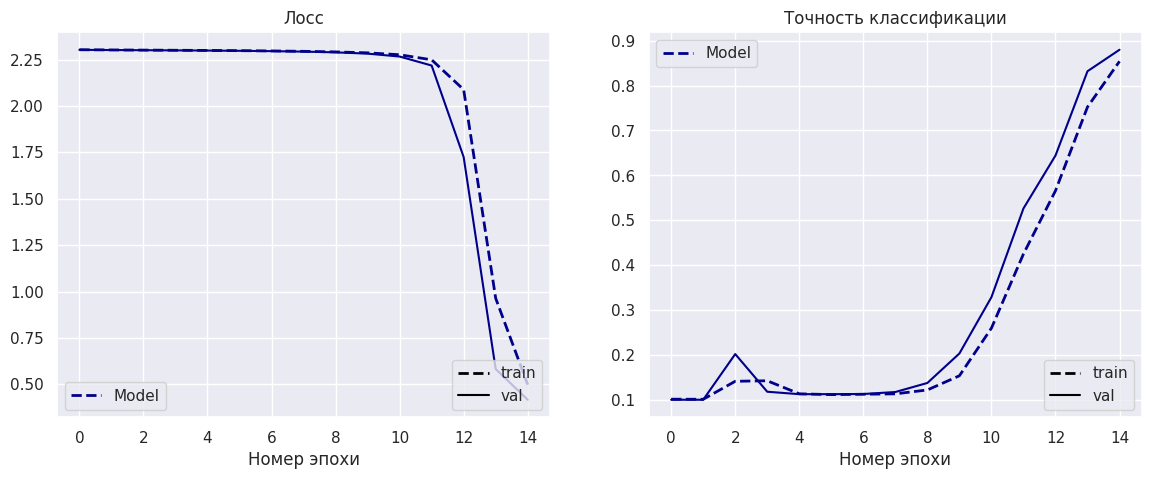

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters())
print("Model 4")
history_model_4 = train(model_4,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [15]:
summary(model_4, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─ReLU: 1-2                              [1, 16, 28, 28]           --
├─Conv2d: 1-3                            [1, 32, 28, 28]           4,640
├─ReLU: 1-4                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-5                         [1, 32, 14, 14]           --
├─Conv2d: 1-6                            [1, 64, 14, 14]           18,496
├─ReLU: 1-7                              [1, 64, 14, 14]           --
├─MaxPool2d: 1-8                         [1, 64, 7, 7]             --
├─Conv2d: 1-9                            [1, 64, 7, 7]             36,928
├─ReLU: 1-10                             [1, 64, 7, 7]             --
├─Flatten: 1-11                          [1, 3136]                 --
├─Linear: 1-12                           [1, 128]                  401,53

Эпоха 15 из 15, затраченное время 10.954 сек.
  лосс на обучении: 	0.042432
  лосс на валидации: 	0.038829
  точность на обучении: 		98.89 %
  точность на валидации: 		98.91 %


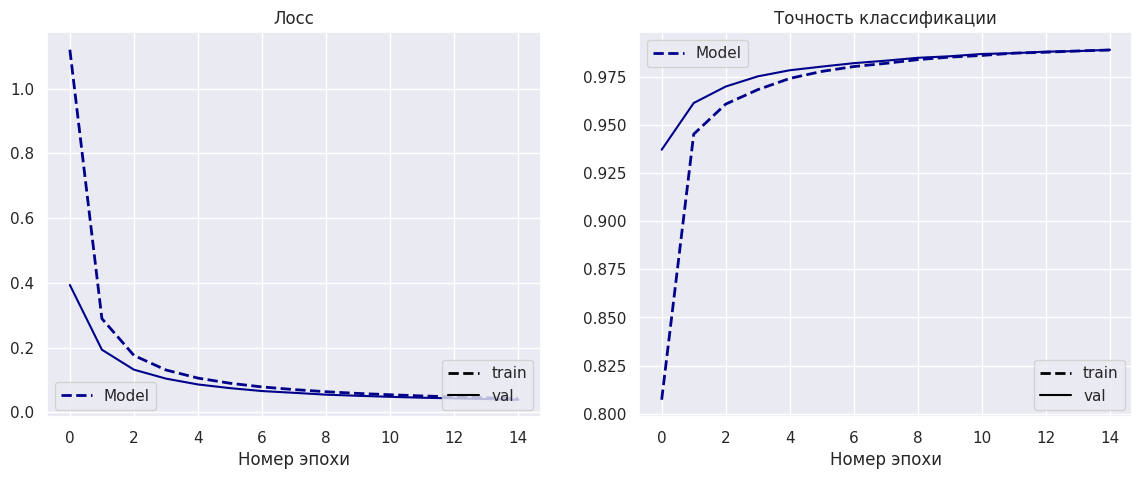

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_5.parameters())
print("Model 5")
history_model_5 = train(model_5,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [17]:
summary(model_5, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─Conv2d: 1-4                            [1, 16, 28, 28]           2,320
├─BatchNorm2d: 1-5                       [1, 16, 28, 28]           32
├─ReLU: 1-6                              [1, 16, 28, 28]           --
├─Conv2d: 1-7                            [1, 32, 28, 28]           4,640
├─BatchNorm2d: 1-8                       [1, 32, 28, 28]           64
├─ReLU: 1-9                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-10                        [1, 32, 14, 14]           --
├─Conv2d: 1-11                           [1, 32, 14, 14]           9,248
├─BatchNorm2d: 1-12                      [1, 32, 14, 14]           64
├─ReL

▫️ Эксп. 1: Нет сравнения количества параметров моделей. Комм. При адекватном числе каналов у сверточного слоя гораздо меньше параметров, чем у линейного. Инд. комм. В выводе по эксперименту 1 отсутствует сравнение количества параметров у рассмотренных моделей.
<font color="green"> Исправление </font>

In [22]:
import pandas as pd

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_df = pd.DataFrame({
    "model": ["model_1", "model_2", "model_3", "model_4", "model_5"],
    "architecture": [
        "1 conv + 1 linear",
        "2 conv + 1 linear",
        "2 conv + 2 linear",
        "4 conv + 2 linear",
        "6 conv + 2 linear + BatchNorm"
    ],
    "params": [
        count_parameters(model_1),
        count_parameters(model_2),
        count_parameters(model_3),
        count_parameters(model_4),
        count_parameters(model_5),
    ]
})

param_df

,model,architecture,params
0,model_1,1 conv + 1 linear,15770
1,model_2,2 conv + 1 linear,67530
2,model_3,2 conv + 2 linear,809034
3,model_4,4 conv + 2 linear,463050
4,model_5,6 conv + 2 linear + BatchNorm,475066


По числу параметров видно, что основной вклад в размер дают именно линейные слои. Например параметров у 4-й модели почти в 2 раза меньше чем у 3-й, хотя используется 4 сверточных слоя а не 2.
Это из-за того, что у "model_3" есть линейный слой размера 128.
Вывод: увеличение числа сверточных слоев не обязательно делает модель больше.

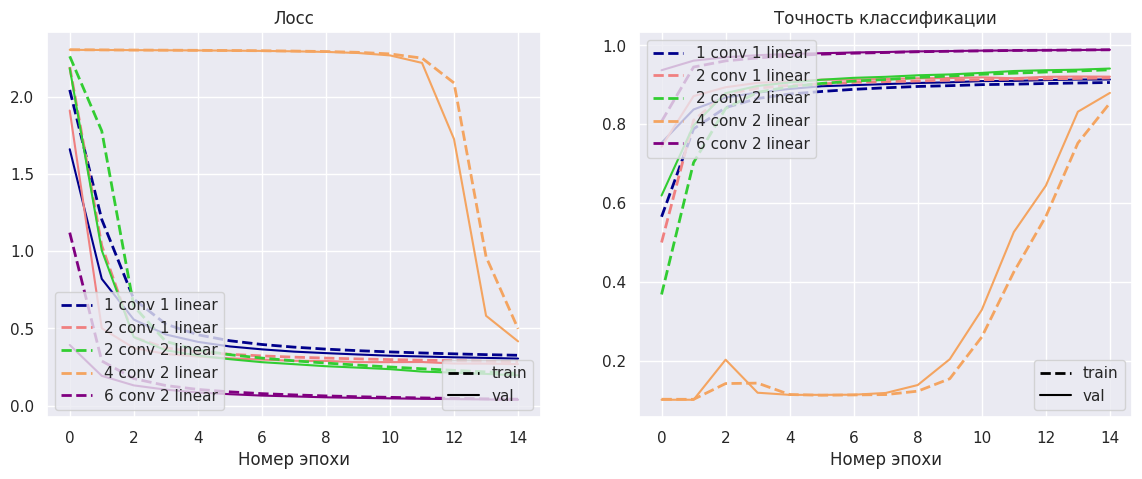

In [18]:
plot_histories([history_model_1,
                history_model_2,
                history_model_3,
                history_model_4,
                history_model_5],
                ['1 conv 1 linear', '2 conv 1 linear',
                 '2 conv 2 linear', '4 conv 2 linear', '6 conv 2 linear'])

In [19]:
def summarize_history(history):
    total_time = sum(history["time"]["epoch"])

    print("=== Итог обучения ===")
    print(f"Суммарное время: {total_time:.3f} сек")
    print(f"Лосс (train): {history['loss']['train'][-1]:.6f}")
    print(f"Лосс (val):   {history['loss']['val'][-1]:.6f}")
    print(f"Точность (train): {history['acc']['train'][-1]*100:.2f}%")
    print(f"Точность (val):   {history['acc']['val'][-1]*100:.2f}%")

In [20]:
print("Результаты модели 1")
summarize_history(history_model_1)
print("Результаты модели 2")
summarize_history(history_model_2)
print("Результаты модели 3")
summarize_history(history_model_3)
print("Результаты модели 4")
summarize_history(history_model_4)
print("Результаты модели 5")
summarize_history(history_model_5)

Результаты модели 1
=== Итог обучения ===
Суммарное время: 149.927 сек
Лосс (train): 0.326484
Лосс (val):   0.305255
Точность (train): 90.60%
Точность (val):   91.36%
Результаты модели 2
=== Итог обучения ===
Суммарное время: 153.101 сек
Лосс (train): 0.284397
Лосс (val):   0.269151
Точность (train): 91.75%
Точность (val):   92.08%
Результаты модели 3
=== Итог обучения ===
Суммарное время: 149.358 сек
Лосс (train): 0.209475
Лосс (val):   0.196652
Точность (train): 93.83%
Точность (val):   94.14%
Результаты модели 4
=== Итог обучения ===
Суммарное время: 157.345 сек
Лосс (train): 0.497891
Лосс (val):   0.416526
Точность (train): 85.38%
Точность (val):   87.96%
Результаты модели 5
=== Итог обучения ===
Суммарное время: 195.637 сек
Лосс (train): 0.042432
Лосс (val):   0.038829
Точность (train): 98.89%
Точность (val):   98.91%


Постройте график лосса и график accuracy, где сравниваются все модели (на train и на val). Нужная функция есть в семинаре.

Сделал выше.

Сделайте вывод. Как количество разных слоев влияет на качество и время обучения?

**Вывод по эксперименту:**

Без применения BatchNorm не удалось поднять accuracy хотя бы до 95%. Что мы видим в последней модели(model 5). Изначально я ее сделал без batchNorm и она была еще хуже чем остальные. Она вообще не обучилась.(у 1-й accuracy менише чем у второй, у второй меньше чем у третьей, а вот у четвертой меньше чем у третьей). Видно, что 4-я модель никак не могла начать обучаться(график обучения сильно отличается от остальных).
- Новые слои повышают точность, но когда слоев больше 3-4, каждый новый слой понижает предсказания
- Что бы исправить это, нужно выравнивать. Используя BatchNorm мне удалось сильно повысить точность.
- Видно, что model_5 начала переобучаться на последних итерациях. Это можно было бы исправить через dropout.

Казалось бы, самая сложная model 5 должна обучаться дольше всех, но так оказалось, что model 2 обучалась дольше всех. И model 5 не сильно дольше(на пару секунд) чем другие модели.

**3.** Теперь выберите лучший вариант, зафиксируйте это количество сверточных и линейных слоев и обучите 4 сверточных нейросети, варьируя размеры ядер сверток всех сверточных слоев нейросети: 3x3, 5x5, 7x7, 9x9.

Замечание. Я не меняю padding, что бы посмотреть "чистую" разницу от ядер.

In [ ]:
import torch.nn as nn

model_5x5 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=5, padding=2),   # (16, 28, 28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 16, kernel_size=5, padding=2),  # (16, 28, 28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=5, padding=2),  # (32, 28, 28)
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2), # (32, 14, 14)

    nn.Conv2d(32, 32, kernel_size=5, padding=2),  # (32, 14, 14)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=5, padding=2),  # (64, 14, 14)
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2), # -> (64, 7, 7)

    nn.Conv2d(64, 64, kernel_size=5, padding=2),  # (64, 7, 7)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_7x7 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=7, padding=3), # (16, 28, 28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 16, kernel_size=7, padding=3), # (16, 28, 28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=7, padding=3), # (32, 28, 28)
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),  # (32, 14, 14)

    nn.Conv2d(32, 32, kernel_size=7, padding=3), # (32, 14, 14)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=7, padding=3), # (64, 14, 14)
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),# -> (64, 7, 7)

    nn.Conv2d(64, 64, kernel_size=7, padding=3),  # (64, 7, 7)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_9x9 = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=9, padding=4), # (16, 28, 28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 16, kernel_size=9, padding=4),  # (16, 28, 28)
    nn.BatchNorm2d(16),
    nn.ReLU(),

    nn.Conv2d(16, 32, kernel_size=9, padding=4), #(32, 28, 28)
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),# (32, 14, 14)

    nn.Conv2d(32, 32, kernel_size=9, padding=4),  # (32, 14, 14)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=9, padding=4),  #  (64, 14, 14)
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),    # - (64, 7, 7)

    nn.Conv2d(64, 64, kernel_size=9, padding=4), # (64, 7, 7)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_5x5.to(device)
model_7x7.to(device)
model_9x9.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_5x5.parameters())
history_model_5x5 = train(model_5x5,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [ ]:
summary(model_5x5, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           416
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─Conv2d: 1-4                            [1, 16, 28, 28]           6,416
├─BatchNorm2d: 1-5                       [1, 16, 28, 28]           32
├─ReLU: 1-6                              [1, 16, 28, 28]           --
├─Conv2d: 1-7                            [1, 32, 28, 28]           12,832
├─BatchNorm2d: 1-8                       [1, 32, 28, 28]           64
├─ReLU: 1-9                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-10                        [1, 32, 14, 14]           --
├─Conv2d: 1-11                           [1, 32, 14, 14]           25,632
├─BatchNorm2d: 1-12                      [1, 32, 14, 14]           64
├─R

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_7x7.parameters())
history_model_7x7 = train(model_7x7,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [ ]:
summary(model_7x7, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           800
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─Conv2d: 1-4                            [1, 16, 28, 28]           12,560
├─BatchNorm2d: 1-5                       [1, 16, 28, 28]           32
├─ReLU: 1-6                              [1, 16, 28, 28]           --
├─Conv2d: 1-7                            [1, 32, 28, 28]           25,120
├─BatchNorm2d: 1-8                       [1, 32, 28, 28]           64
├─ReLU: 1-9                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-10                        [1, 32, 14, 14]           --
├─Conv2d: 1-11                           [1, 32, 14, 14]           50,208
├─BatchNorm2d: 1-12                      [1, 32, 14, 14]           64
├─

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_9x9.parameters())
history_model_9x9 = train(model_9x9,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=15)

In [ ]:
summary(model_9x9, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           1,312
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─Conv2d: 1-4                            [1, 16, 28, 28]           20,752
├─BatchNorm2d: 1-5                       [1, 16, 28, 28]           32
├─ReLU: 1-6                              [1, 16, 28, 28]           --
├─Conv2d: 1-7                            [1, 32, 28, 28]           41,504
├─BatchNorm2d: 1-8                       [1, 32, 28, 28]           64
├─ReLU: 1-9                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-10                        [1, 32, 14, 14]           --
├─Conv2d: 1-11                           [1, 32, 14, 14]           82,976
├─BatchNorm2d: 1-12                      [1, 32, 14, 14]           64


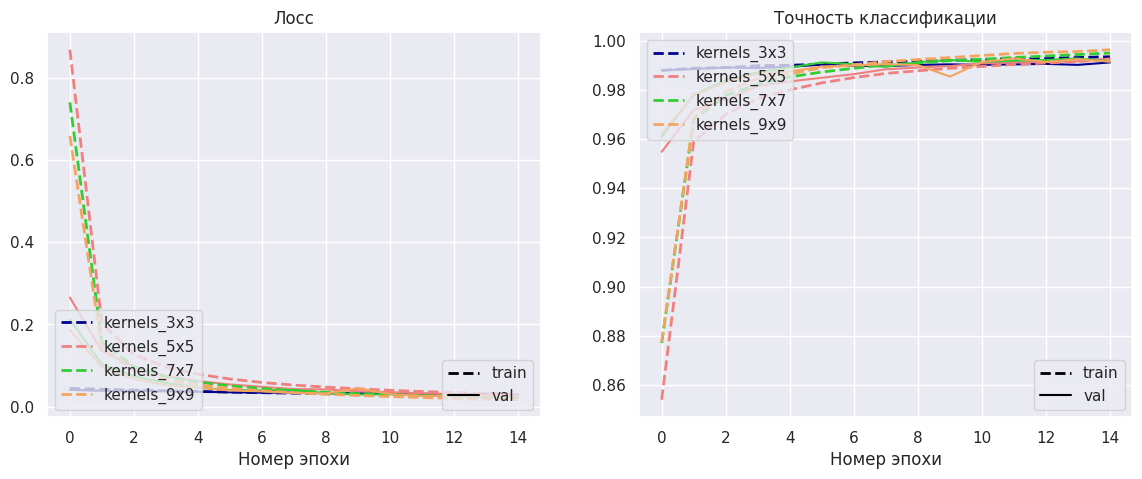

In [ ]:
plot_histories([history_model_5,
                history_model_5x5,
                history_model_7x7,
                history_model_9x9],
                ['kernels_3x3', 'kernels_5x5', 'kernels_7x7', 'kernels_9x9'])

In [ ]:
print("Результаты модели 3x3")
summarize_history(history_model_5)
print("Результаты модели 5x5")
summarize_history(history_model_5x5)
print("Результаты модели 7x7")
summarize_history(history_model_7x7)
print("Результаты модели 9x9")
summarize_history(history_model_9x9)

Результаты модели 3x3
=== Итог обучения ===
Суммарное время: 182.271 сек
Лосс (train): 0.025541
Лосс (val):   0.028738
Точность (train): 99.37%
Точность (val):   99.13%
Результаты модели 5x5
=== Итог обучения ===
Суммарное время: 221.487 сек
Лосс (train): 0.029951
Лосс (val):   0.027491
Точность (train): 99.25%
Точность (val):   99.29%
Результаты модели 7x7
=== Итог обучения ===
Суммарное время: 283.470 сек
Лосс (train): 0.020974
Лосс (val):   0.025460
Точность (train): 99.52%
Точность (val):   99.17%
Результаты модели 9x9
=== Итог обучения ===
Суммарное время: 366.807 сек
Лосс (train): 0.016676
Лосс (val):   0.026076
Точность (train): 99.65%
Точность (val):   99.16%


Постройте график лосса и график accuracy, где сравниваются все модели этого эксперимента (на train и на val).

выше сделано

Сделайте вывод. Как размеры ядер влияют на качество и время обучения?

**Вывод по эксперименту:**

Как мы видим, чем больше размеры ядер, тем дольше обучается модель. Это логично, потому что больше весов нужно подбирать. Качество обучение почти не отличается к 15-й итерации, но на первых итерациях видно, что чем меньше ядры у модели, тем быстрее она обучается и выходит на плато порядка 99%.

Можно сделать вывод, что иногда малые ядра не понижают эффективность, а скорость обучения и сходимости к 'предельной' точности выше.


**4.** Выберите лучшую конфигурацию из всех по accuracy на валидации. Она должна быть не меньше 97%.

Это модель history_model_5x5. Она лучшая, хотя и на доли процента.

Проведите еще один проход валидации выбранной моделью по всему датасету. В нем посчитайте точность по каждому классу и соберите информацию о неправильных предсказаниях. Равномерна ли точность по отношению к классам? Покажите 10-20 примеров, на которых нейросеть выдала неправильную метку. Что можно о них сказать?

In [ ]:
y_test = val_dataset.targets
X_test = val_dataset.data.unsqueeze(1).float() / 255.0

X_test = X_test.to(device)

with torch.no_grad():
  outputs = model_5x5(X_test)
  y_pred = outputs.argmax(dim=1)
y_test = y_test.cpu()
y_pred = y_pred.cpu()

In [ ]:
masks = [(y_test == i) for i in range(10)]
accuracies = [
    (y_test[mask] == y_pred[mask]).float().mean().item()
     for mask in masks
    ]
print("Класс | Accuracy")
print("-----------------")
for i, acc in enumerate(accuracies):
  print(f"{i:>5} | {acc:.4f}")

Класс | Accuracy
-----------------
    0 | 0.9959
    1 | 0.9974
    2 | 0.9922
    3 | 0.9921
    4 | 0.9969
    5 | 0.9910
    6 | 0.9916
    7 | 0.9922
    8 | 0.9928
    9 | 0.9861


Точность по классам не равномерна, как мы видим, наша модель предсказывает цифру 9 хуже чем остальные. Часто на ней ошибается. Выведем несколько цифр, на которых наша модель ошибается.

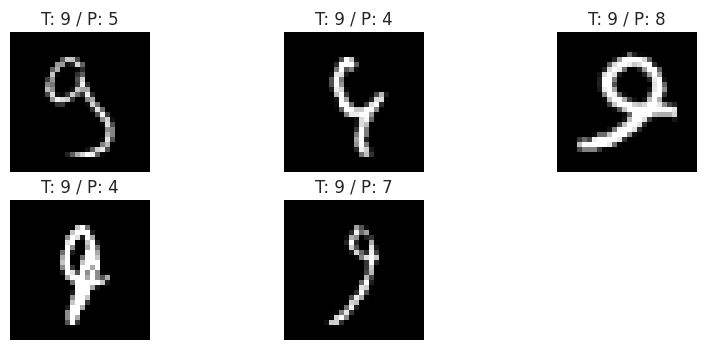

In [ ]:
nine_errors_mask = y_test[masks[9]] != y_pred[masks[9]]
error_indices_local = torch.where(nine_errors_mask)[0]

# индексы всех девяток в исходном датасете
nine_indices = torch.where(masks[9])[0]

plt.figure(figsize=(10, 4))
n = 5
for i in range(n):
  idx = nine_indices[error_indices_local[i]]

  plt.subplot(2, 3, i+1)
  plt.imshow(X_test[idx].squeeze().cpu(), cmap="gray")
  plt.title(f"T: {y_test[idx].item()} / P: {y_pred[idx].item()}")
  plt.axis('off')

plt.show()

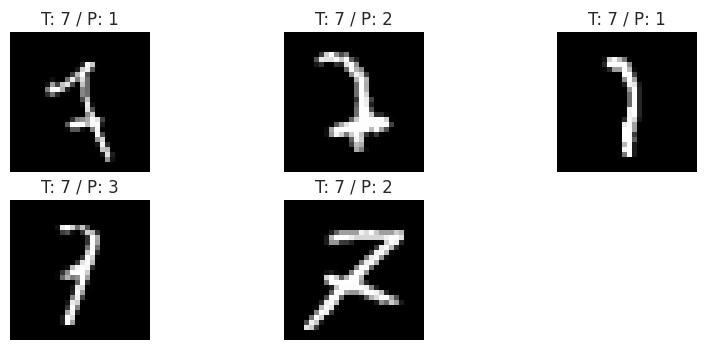

In [ ]:
seven_errors_mask = y_test[masks[7]] != y_pred[masks[7]]
error_indices_local = torch.where(seven_errors_mask)[0]

# индексы всех девяток в исходном датасете
seven_indices = torch.where(masks[7])[0]

plt.figure(figsize=(10, 4))
n = 5
for i in range(n):
  idx = seven_indices[error_indices_local[i]]

  plt.subplot(2, 3, i+1)
  plt.imshow(X_test[idx].squeeze().cpu(), cmap="gray")
  plt.title(f"T: {y_test[idx].item()} / P: {y_pred[idx].item()}")
  plt.axis('off')

plt.show()

Как мы видим по семеркам и девяткам, есть такие цифры, которые человек тут не отличит. Но есть и такие, которые понятны человеку, но модель в них ошиблась.

**Ответ:**

Есть куда еще улучшать модель. Но те цифры, которые остались, уже не очень похожи сами на себя

**5.** **Вывод по всей задаче:**

Использование разных ядер, LeakyRelu повышают точность.
Dropout позоволяет не переучаться на татасете и тоже повышает точность.
Точность 100% не достижима, так как на картинках девятки видно, что некоторые цифры совсем не похожи на 9. Вполне вероятно, что датасет расмечен не ииально и могли быть перепутаны цифры. В частности на примере одна из девяток очень похожа на 4.

---
### Задача 2. Визуализиция сверточных слоев

Обучите модель, состоящую как минимум из 4 сверточных слоев, на датасете MNIST. **Количество выходных каналов в каждом сверточном слое должно быть равно 32**, а точность на тестовых данных должна достигать 97%. Для создания модели будет удобно использовать `torch.nn.Sequential`.


Эпоха 20 из 20, затраченное время 11.420 сек.
  лосс на обучении: 	0.045108
  лосс на валидации: 	0.037783
  точность на обучении: 		98.74 %
  точность на валидации: 		98.88 %


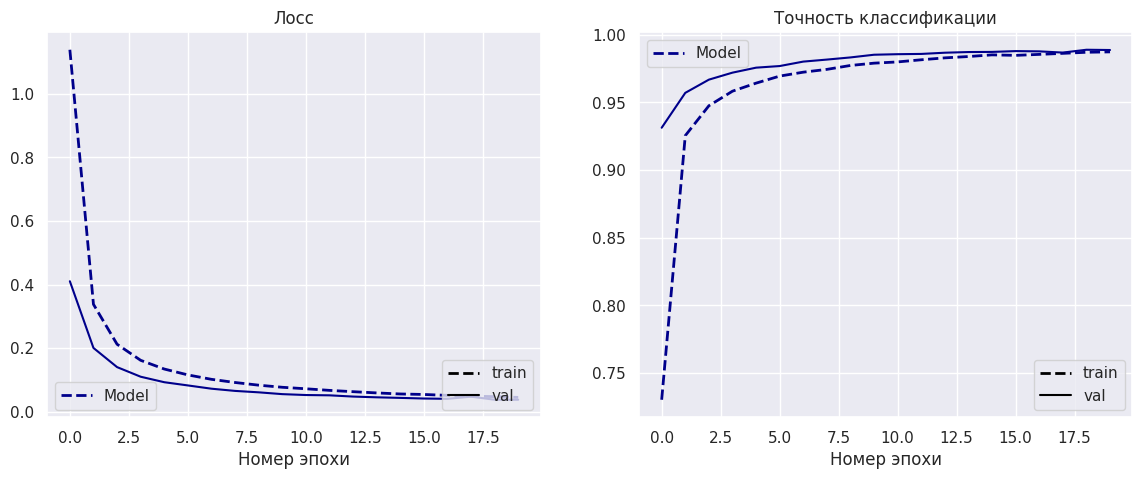

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,28,28) -> (32,28,28)
    nn.BatchNorm2d(32),
    nn.LeakyReLU(0.01),

    nn.Conv2d(32, 32, kernel_size=5, padding=2), # (16,28,28) -> (32,28,28)
    nn.BatchNorm2d(32),
    nn.LeakyReLU(0.01),
    nn.MaxPool2d(2),    # (32,28,28) -> (32,14,14)

    nn.Conv2d(32, 32, kernel_size=3, padding=1), # (32,14,14) -> (32,14,14)
    nn.BatchNorm2d(32),
    nn.LeakyReLU(0.01),

    nn.Conv2d(32, 32, kernel_size=5, padding=2), # (32,14,14) -> (32,14,14)
    nn.BatchNorm2d(32),
    nn.LeakyReLU(0.01),
    nn.MaxPool2d(2),   # (32,14,14) -> (32,7,7)

    nn.Flatten(), # -> 64*7*7
    nn.Linear(32 * 7 * 7, 128),
    nn.LeakyReLU(0.01),
    nn.Dropout(0.2),
    nn.Linear(128, 10)
)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters())
history_mlp = train(model,
                    criterion,
                    optimizer,
                    train_batch_gen,
                    val_batch_gen,
                    num_epochs=20)

Визуализируйте веса свертки на первом слое. Поскольку веса имеют размерность $(32, 1, K_1, K_2)$, т.к. входное изображение имеет один канал, вам необходимо отобразить 32 изображения (по количеству выходных каналов) фильтрами размера $K_1 \times K_2$.

*Совет.* Здесь и далее серии из 32 картинок визуализируйте в виде сетки с помощью `plt.subplots(4, 8, figsize=...)`. Не забывайте указывать параметр `cmap='gray'`.

Shape первого слоя: [32, 1, 3, 3]


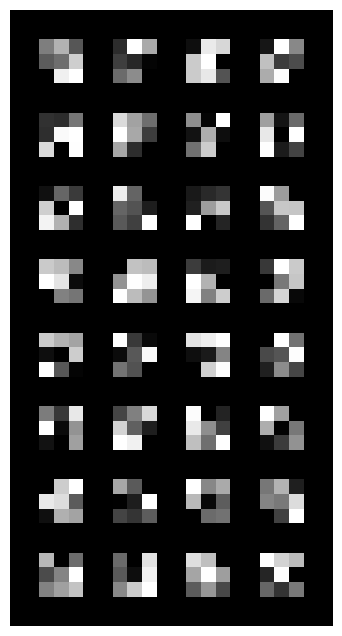

In [ ]:
first_layer = model[0]
print("Shape первого слоя:", list(first_layer.weight.shape))
weights = first_layer.weight.data.cpu()
num_filters = weights.shape[0]

import torchvision.utils as vutils

grid = vutils.make_grid(weights, nrow=4, normalize=True, scale_each=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

Какую функцию они могут нести? Для ответа на вопрос вспомните фильтры, рассмотренные на семинаре.

Это фильтры первого слоя. Это распознователи базовых признаков. Они запоминают локальные паттерны. Ищутся похожие. Вертикальные, горизонтальные полосы, закругления.

Для одного произвольного изображения из датасета MNIST визуализируйте выходы **всех слоев** нейросети, включая активацию и пуллинг, вплоть до операции `Flatten`, но не включая её. Каждый выход будет иметь размерность $(32, H_i, W_i)$. Таким образом, для каждого слоя необходимо создать $32$ изображения размером $H_i \times W_i$.

Label: 7
Layer 0: Conv2d, output shape = (1, 32, 28, 28)
Layer 1: BatchNorm2d, output shape = (1, 32, 28, 28)
Layer 2: LeakyReLU, output shape = (1, 32, 28, 28)
Layer 3: Conv2d, output shape = (1, 32, 28, 28)
Layer 4: BatchNorm2d, output shape = (1, 32, 28, 28)
Layer 5: LeakyReLU, output shape = (1, 32, 28, 28)
Layer 6: MaxPool2d, output shape = (1, 32, 14, 14)
Layer 7: Conv2d, output shape = (1, 32, 14, 14)
Layer 8: BatchNorm2d, output shape = (1, 32, 14, 14)
Layer 9: LeakyReLU, output shape = (1, 32, 14, 14)
Layer 10: Conv2d, output shape = (1, 32, 14, 14)
Layer 11: BatchNorm2d, output shape = (1, 32, 14, 14)
Layer 12: LeakyReLU, output shape = (1, 32, 14, 14)
Layer 13: MaxPool2d, output shape = (1, 32, 7, 7)


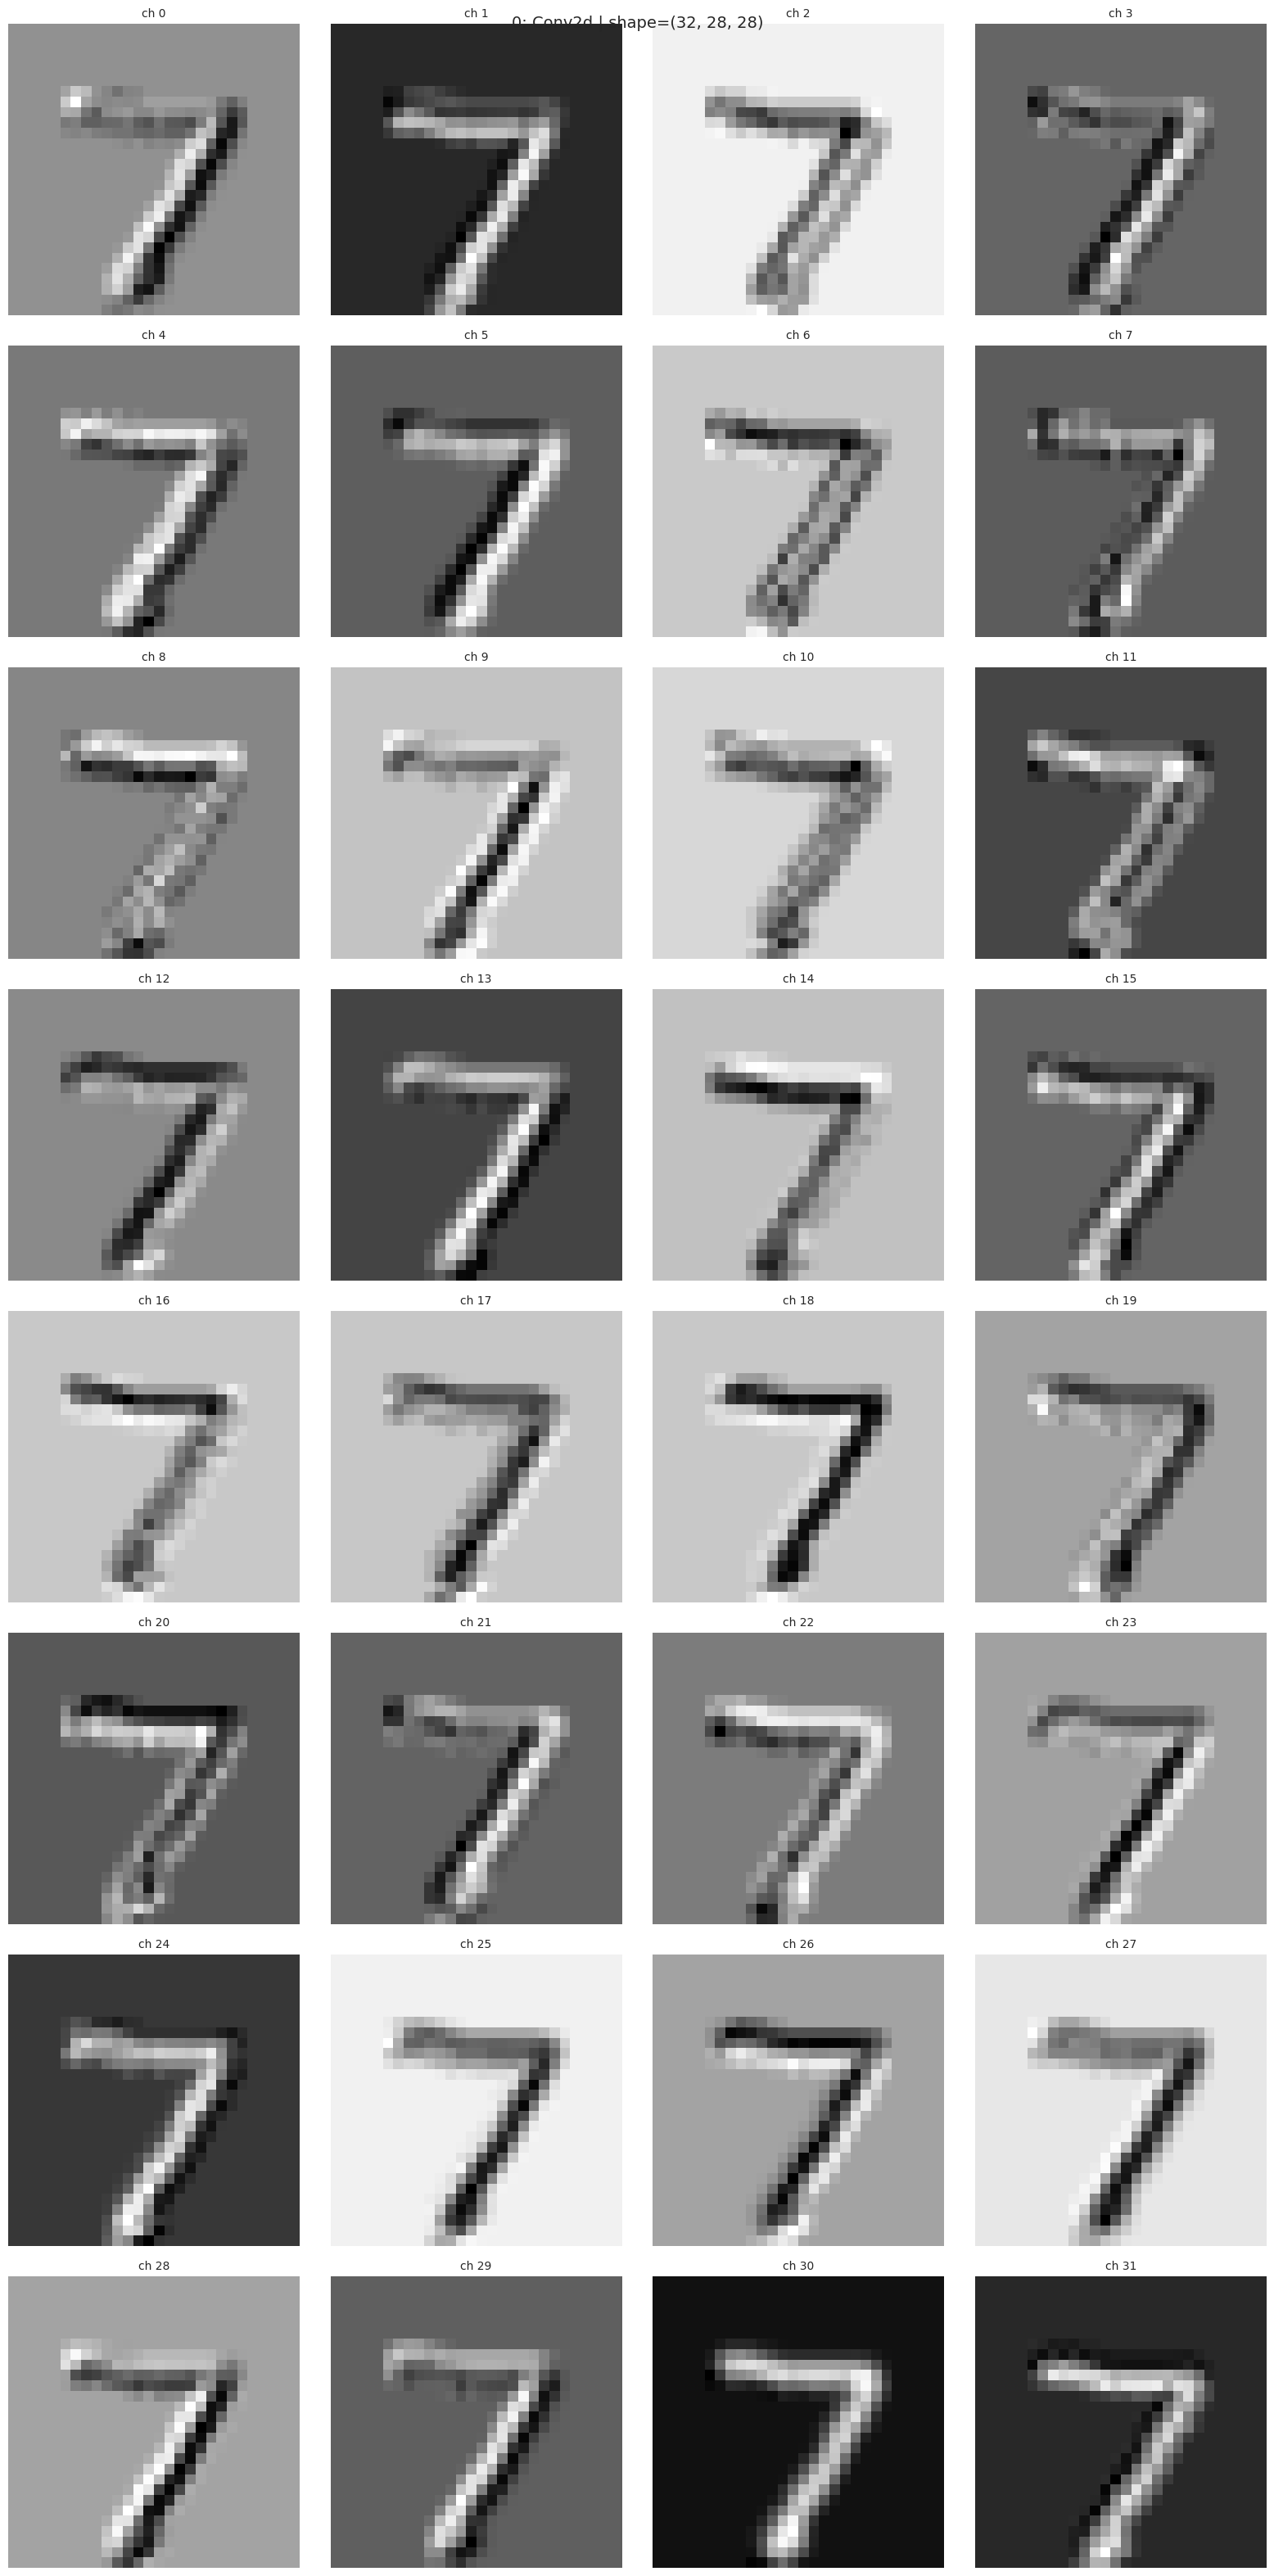

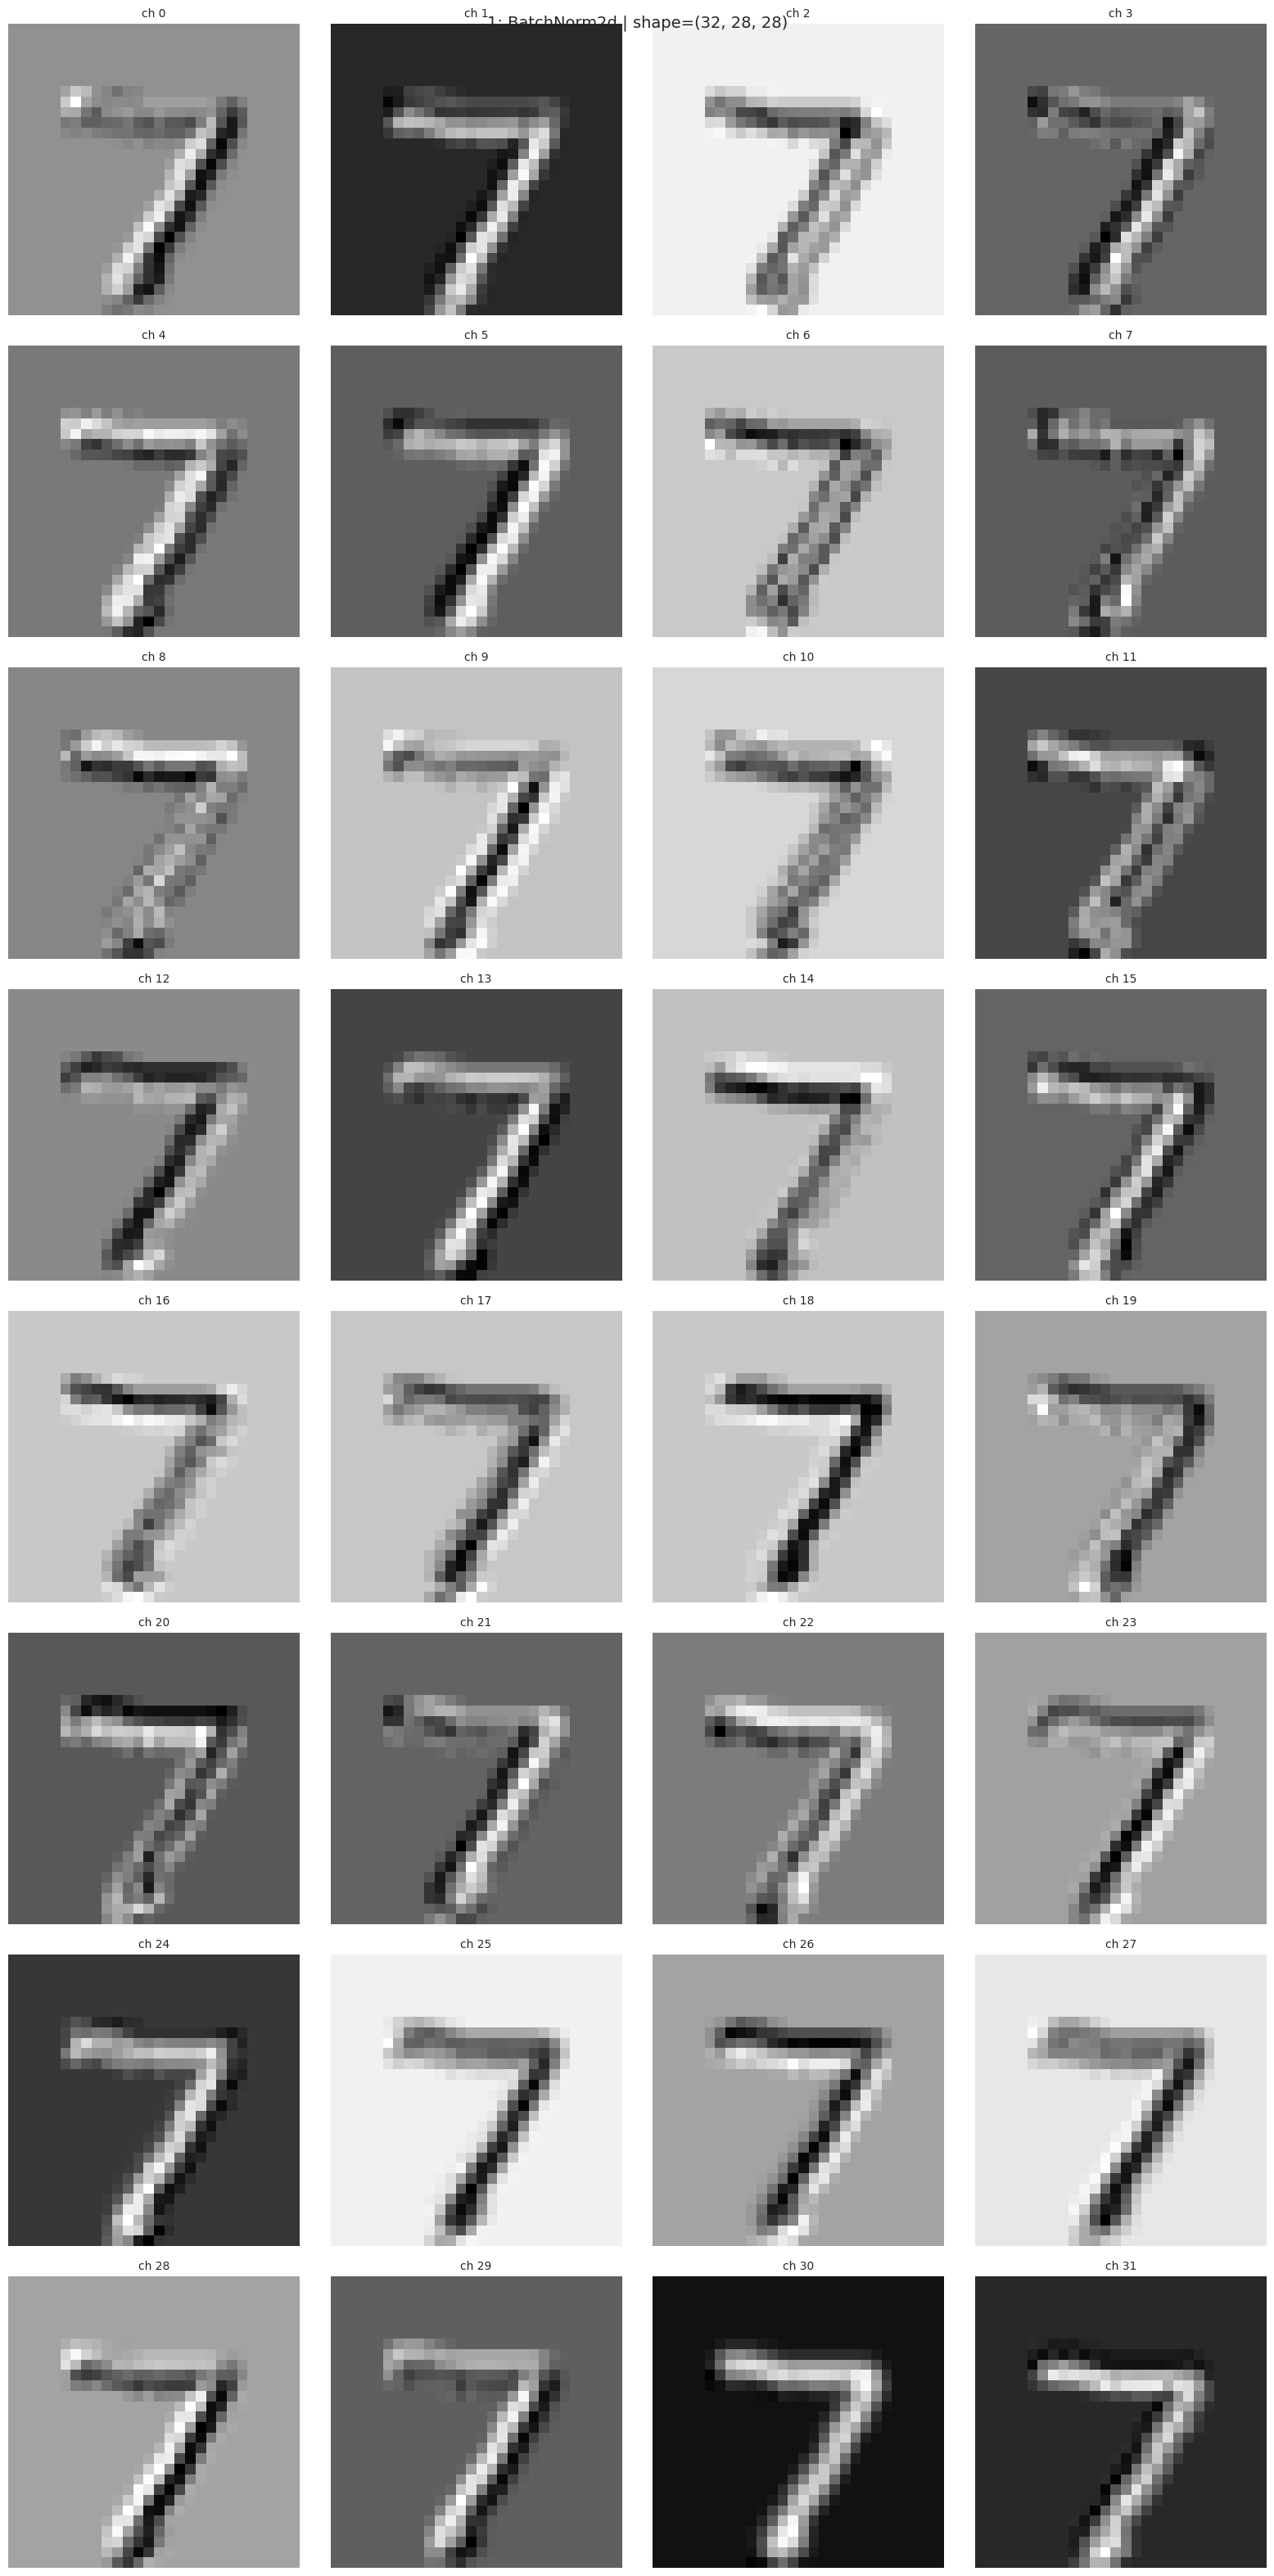

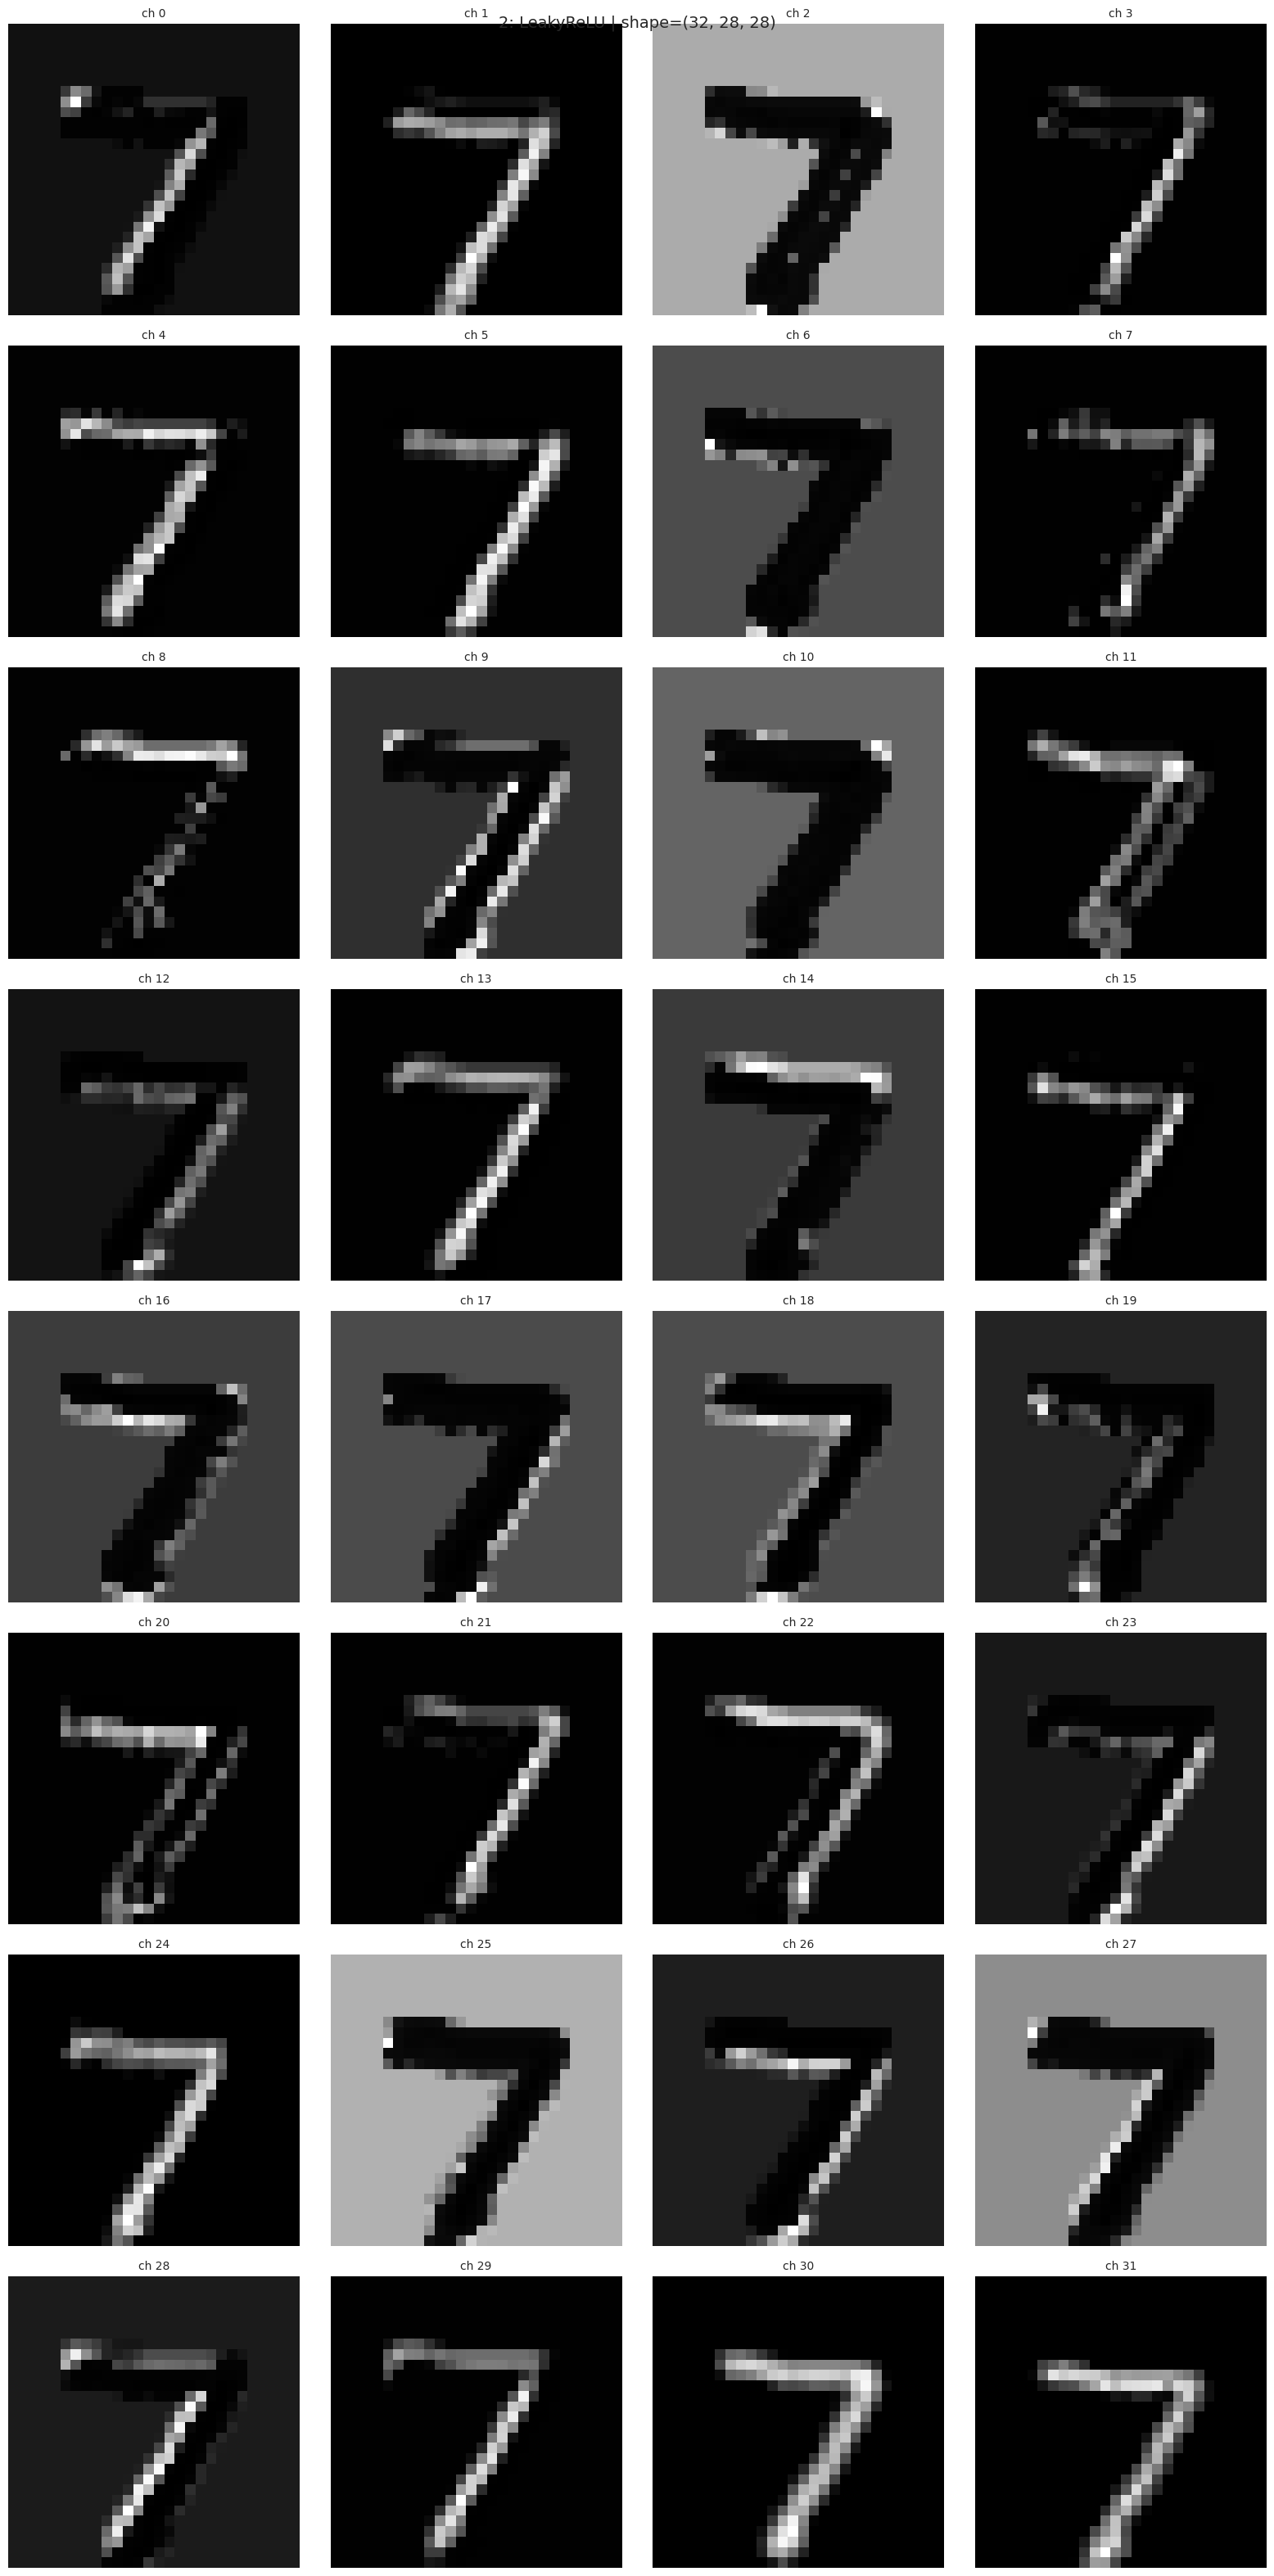

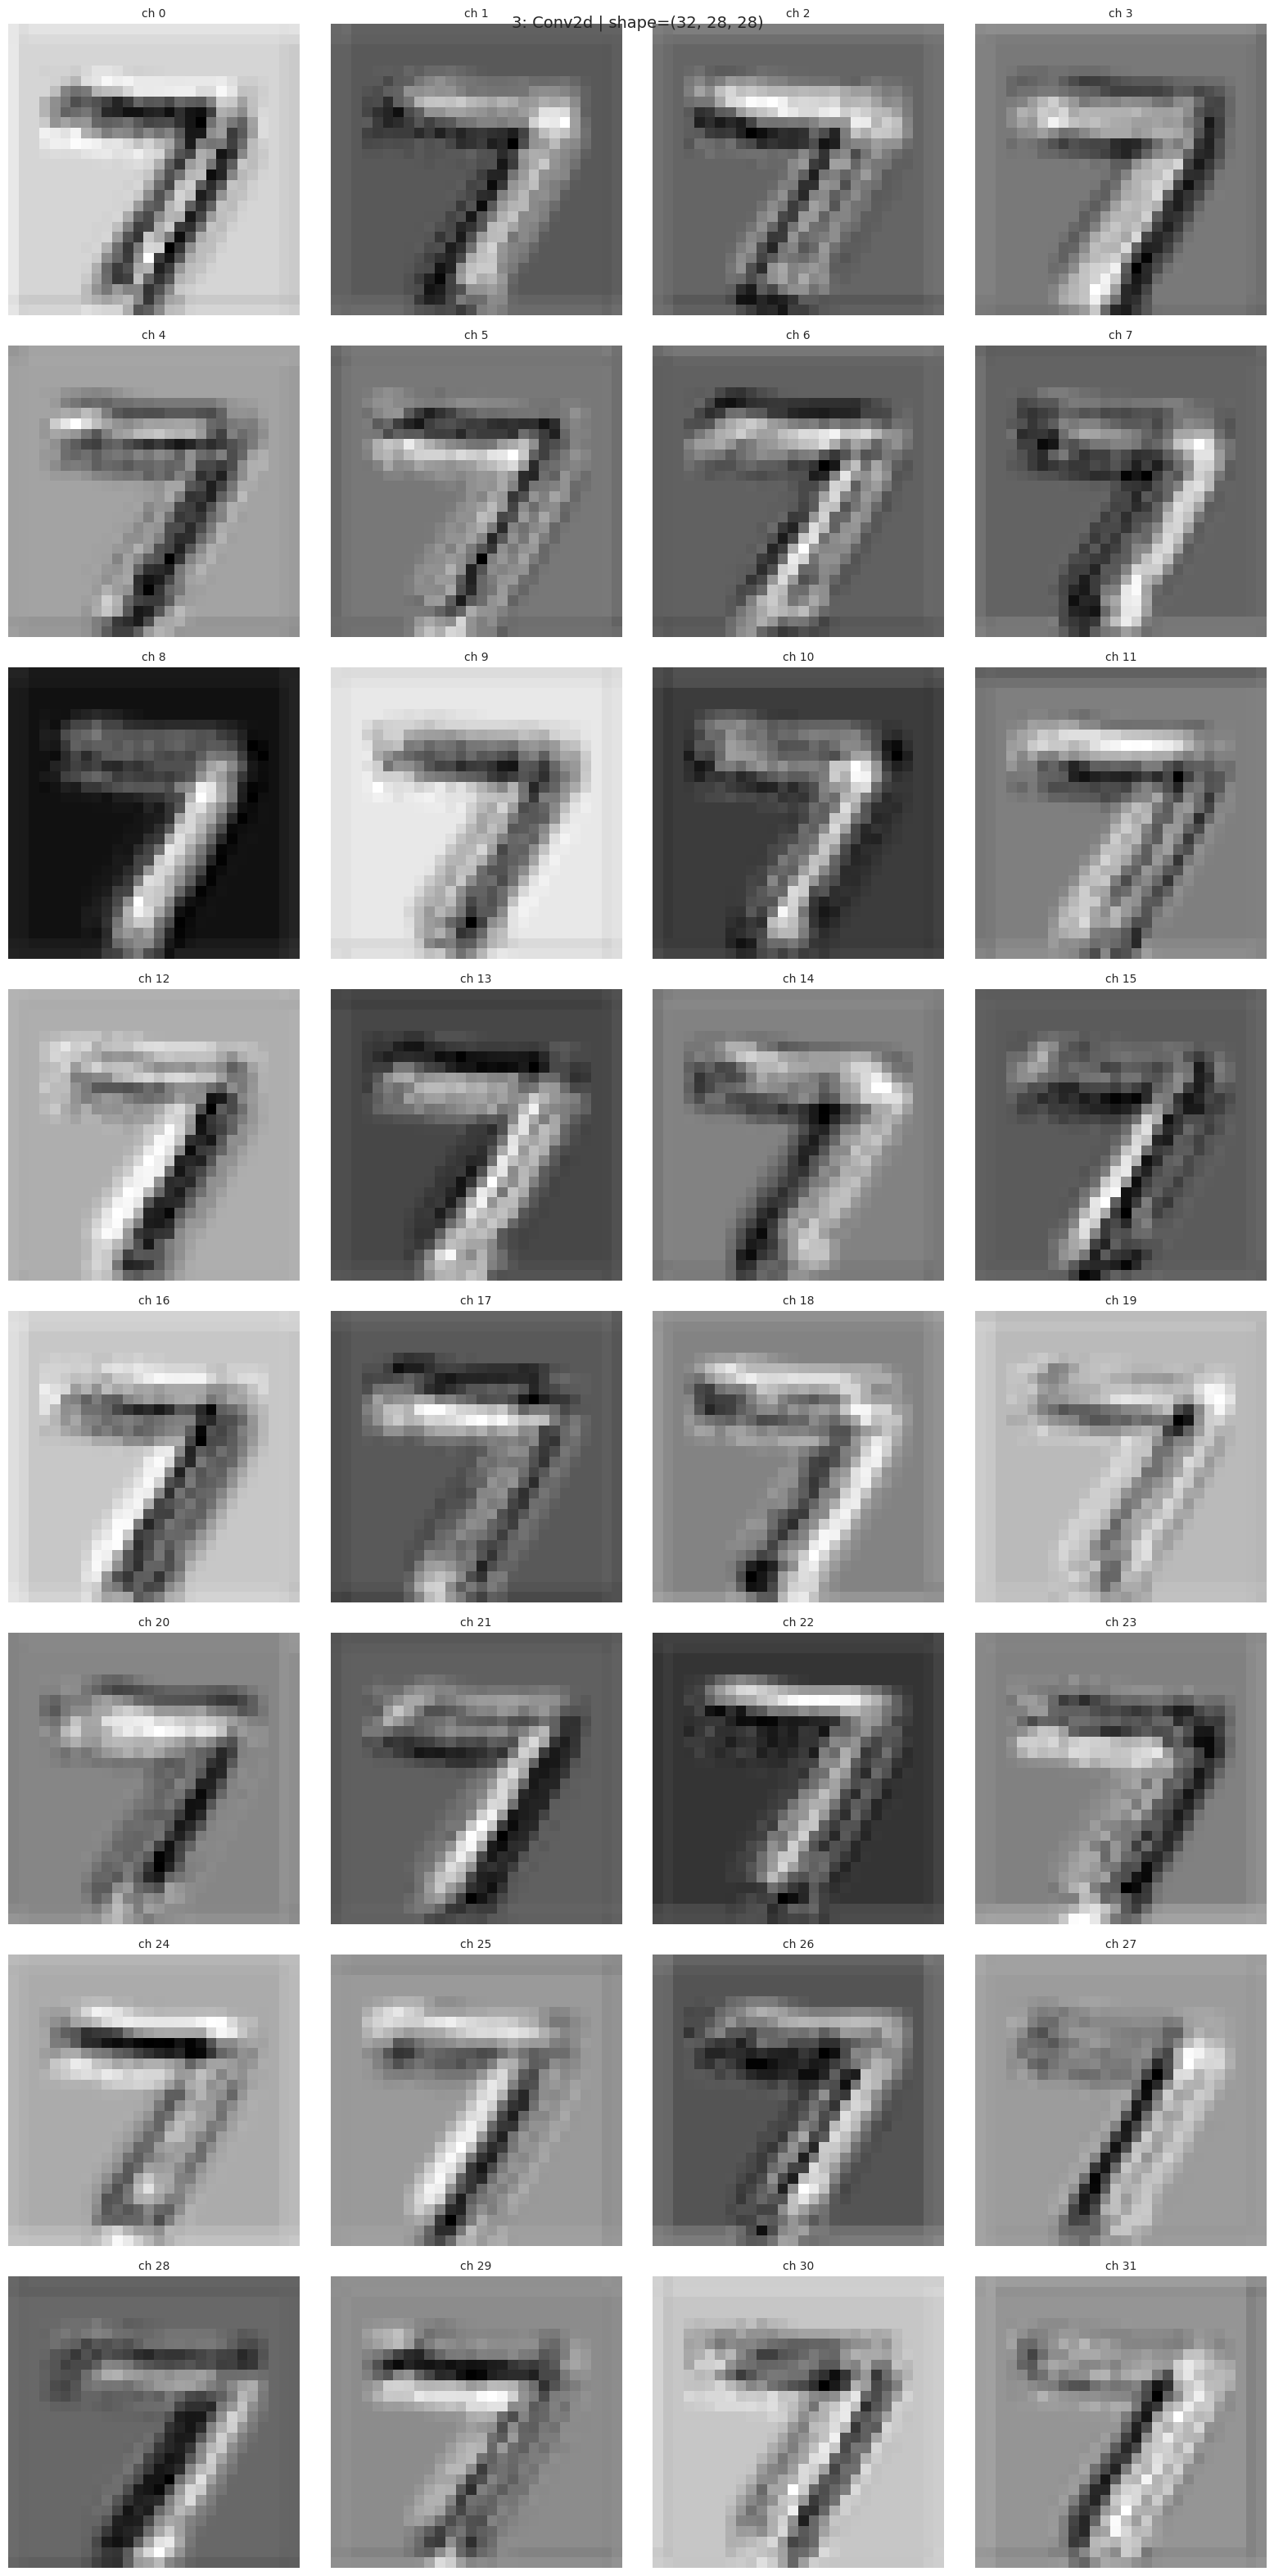

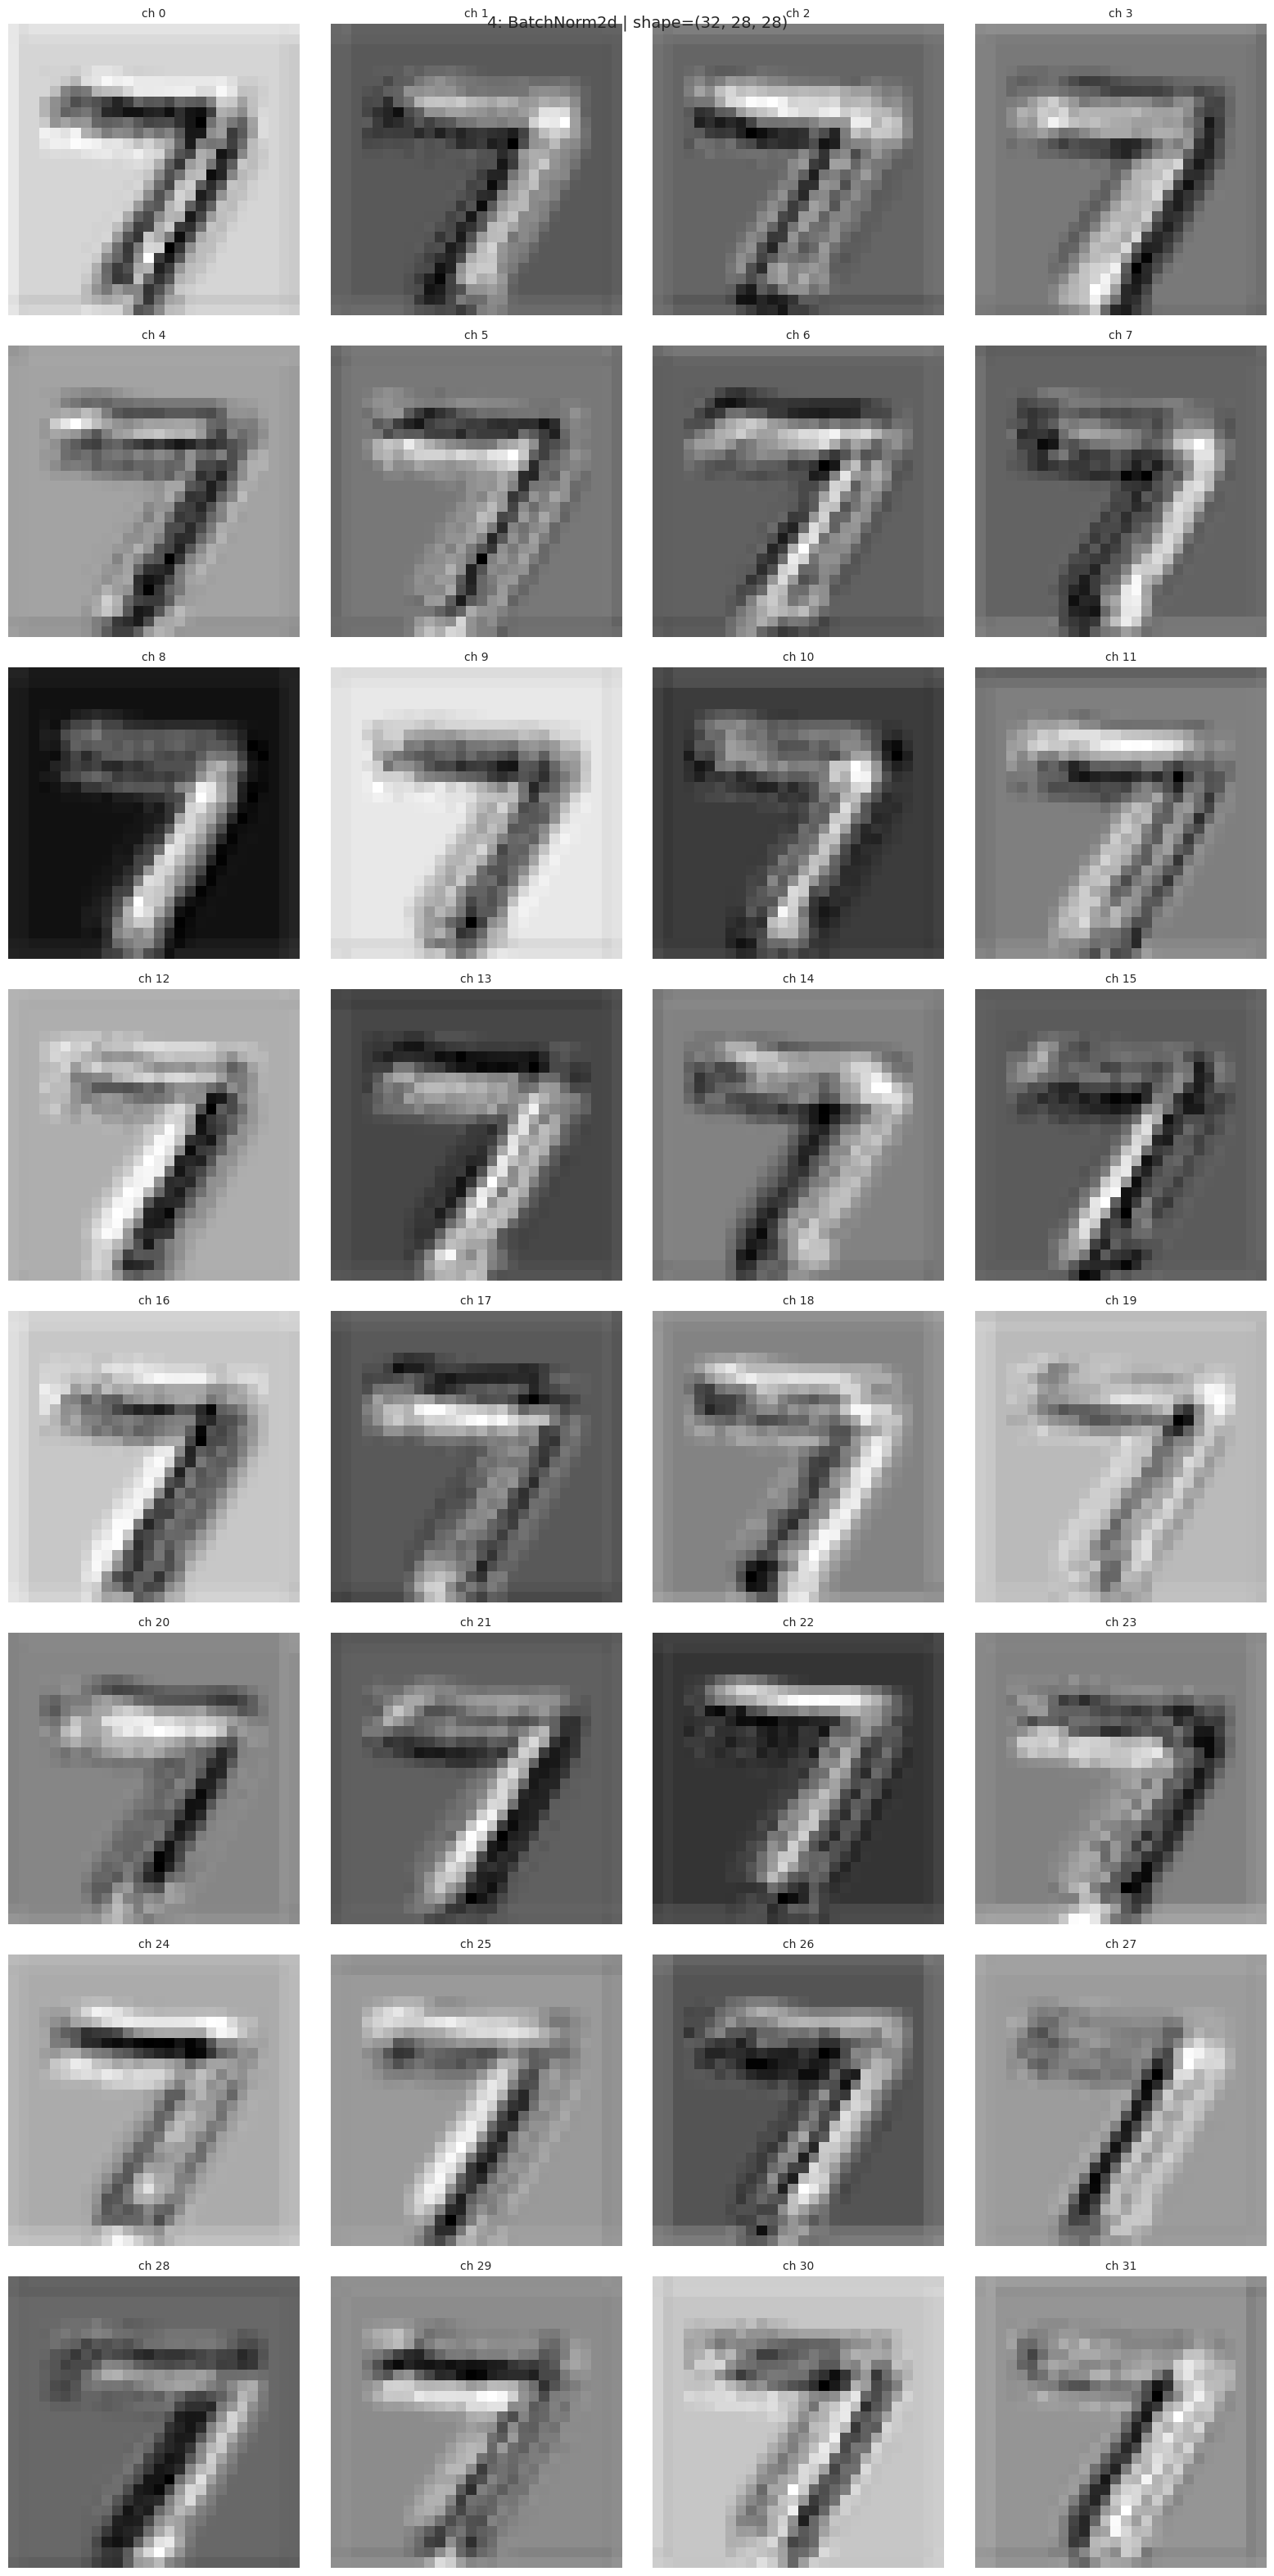

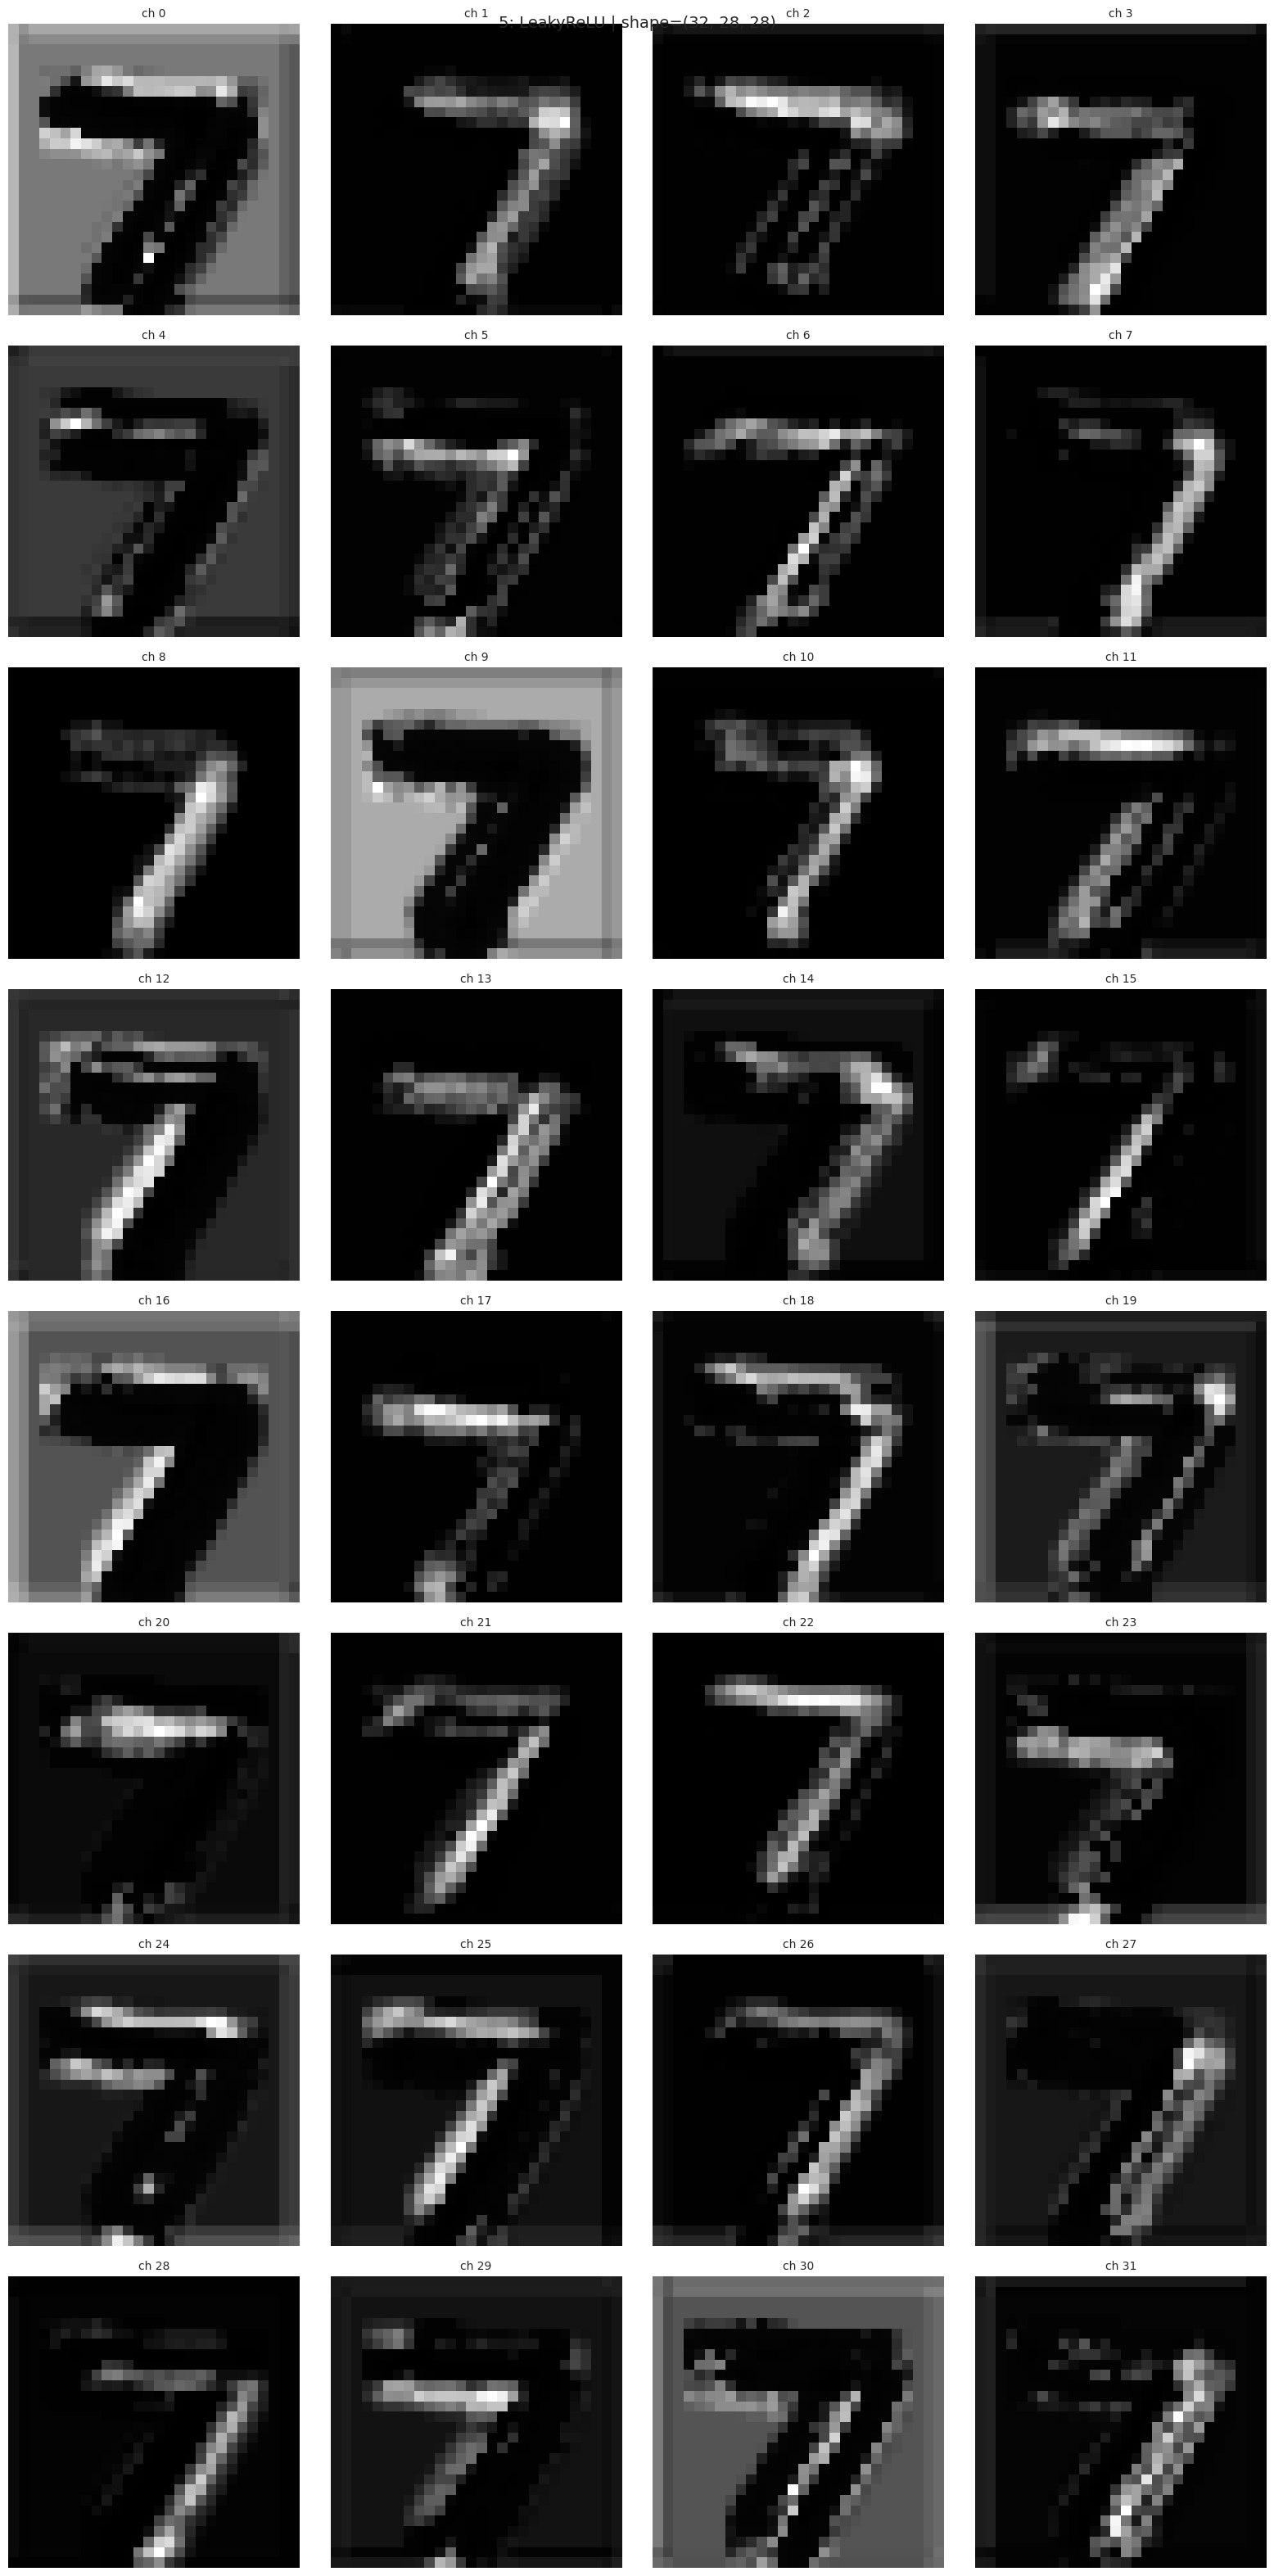

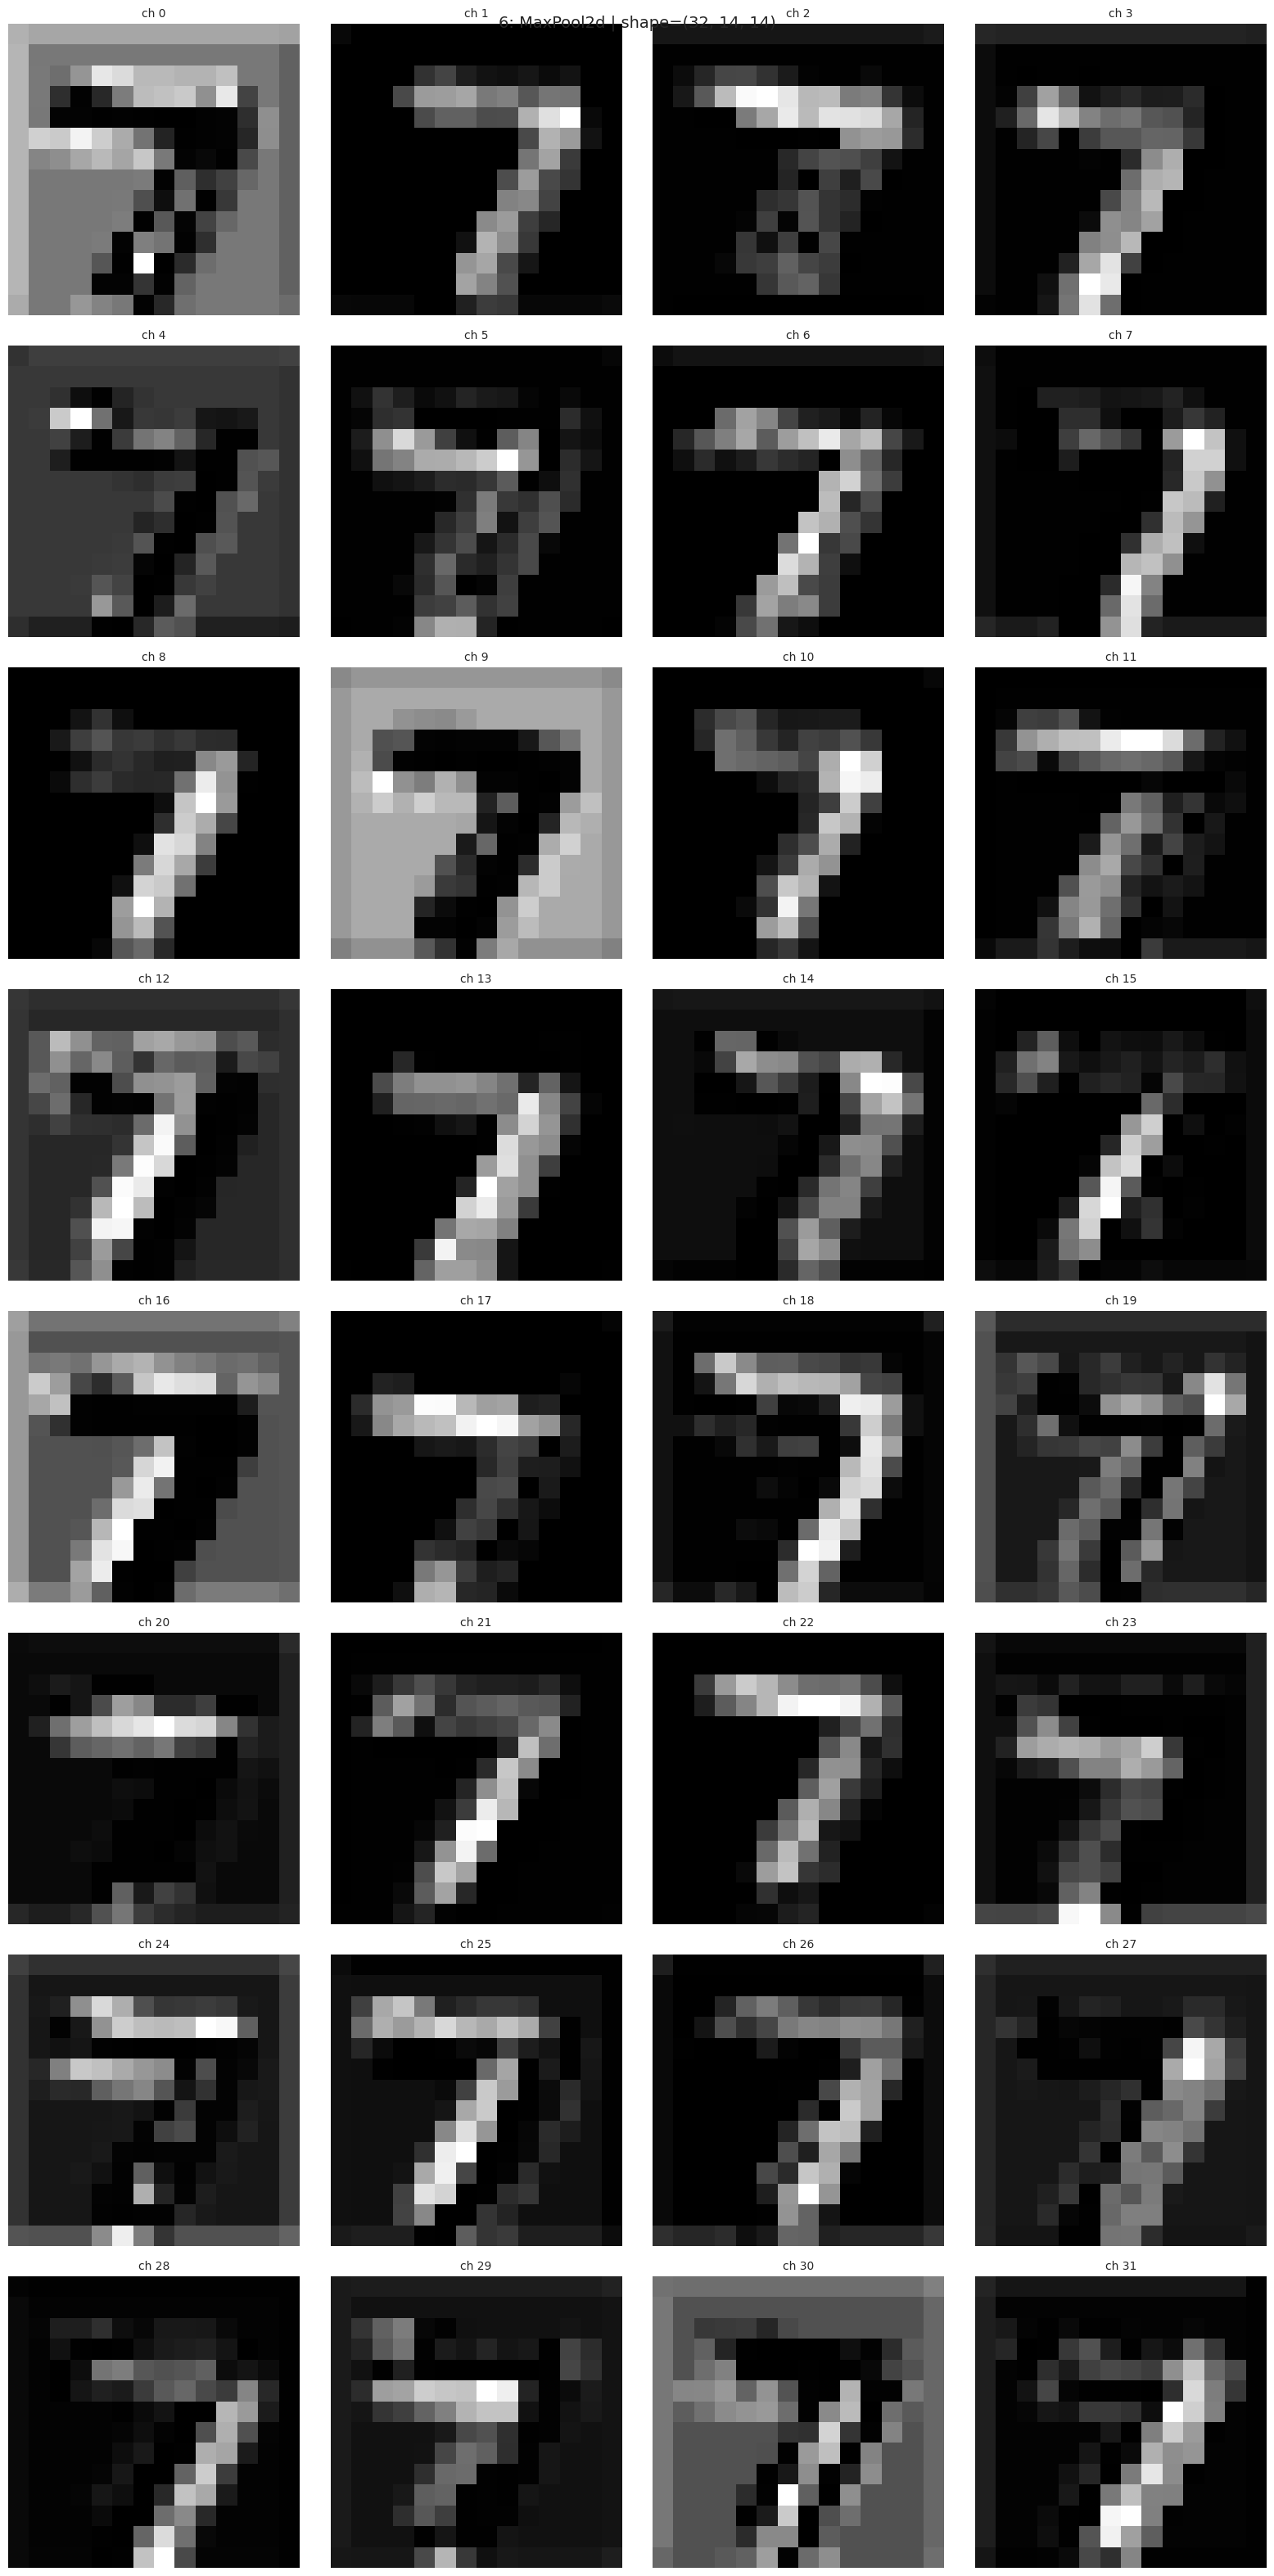

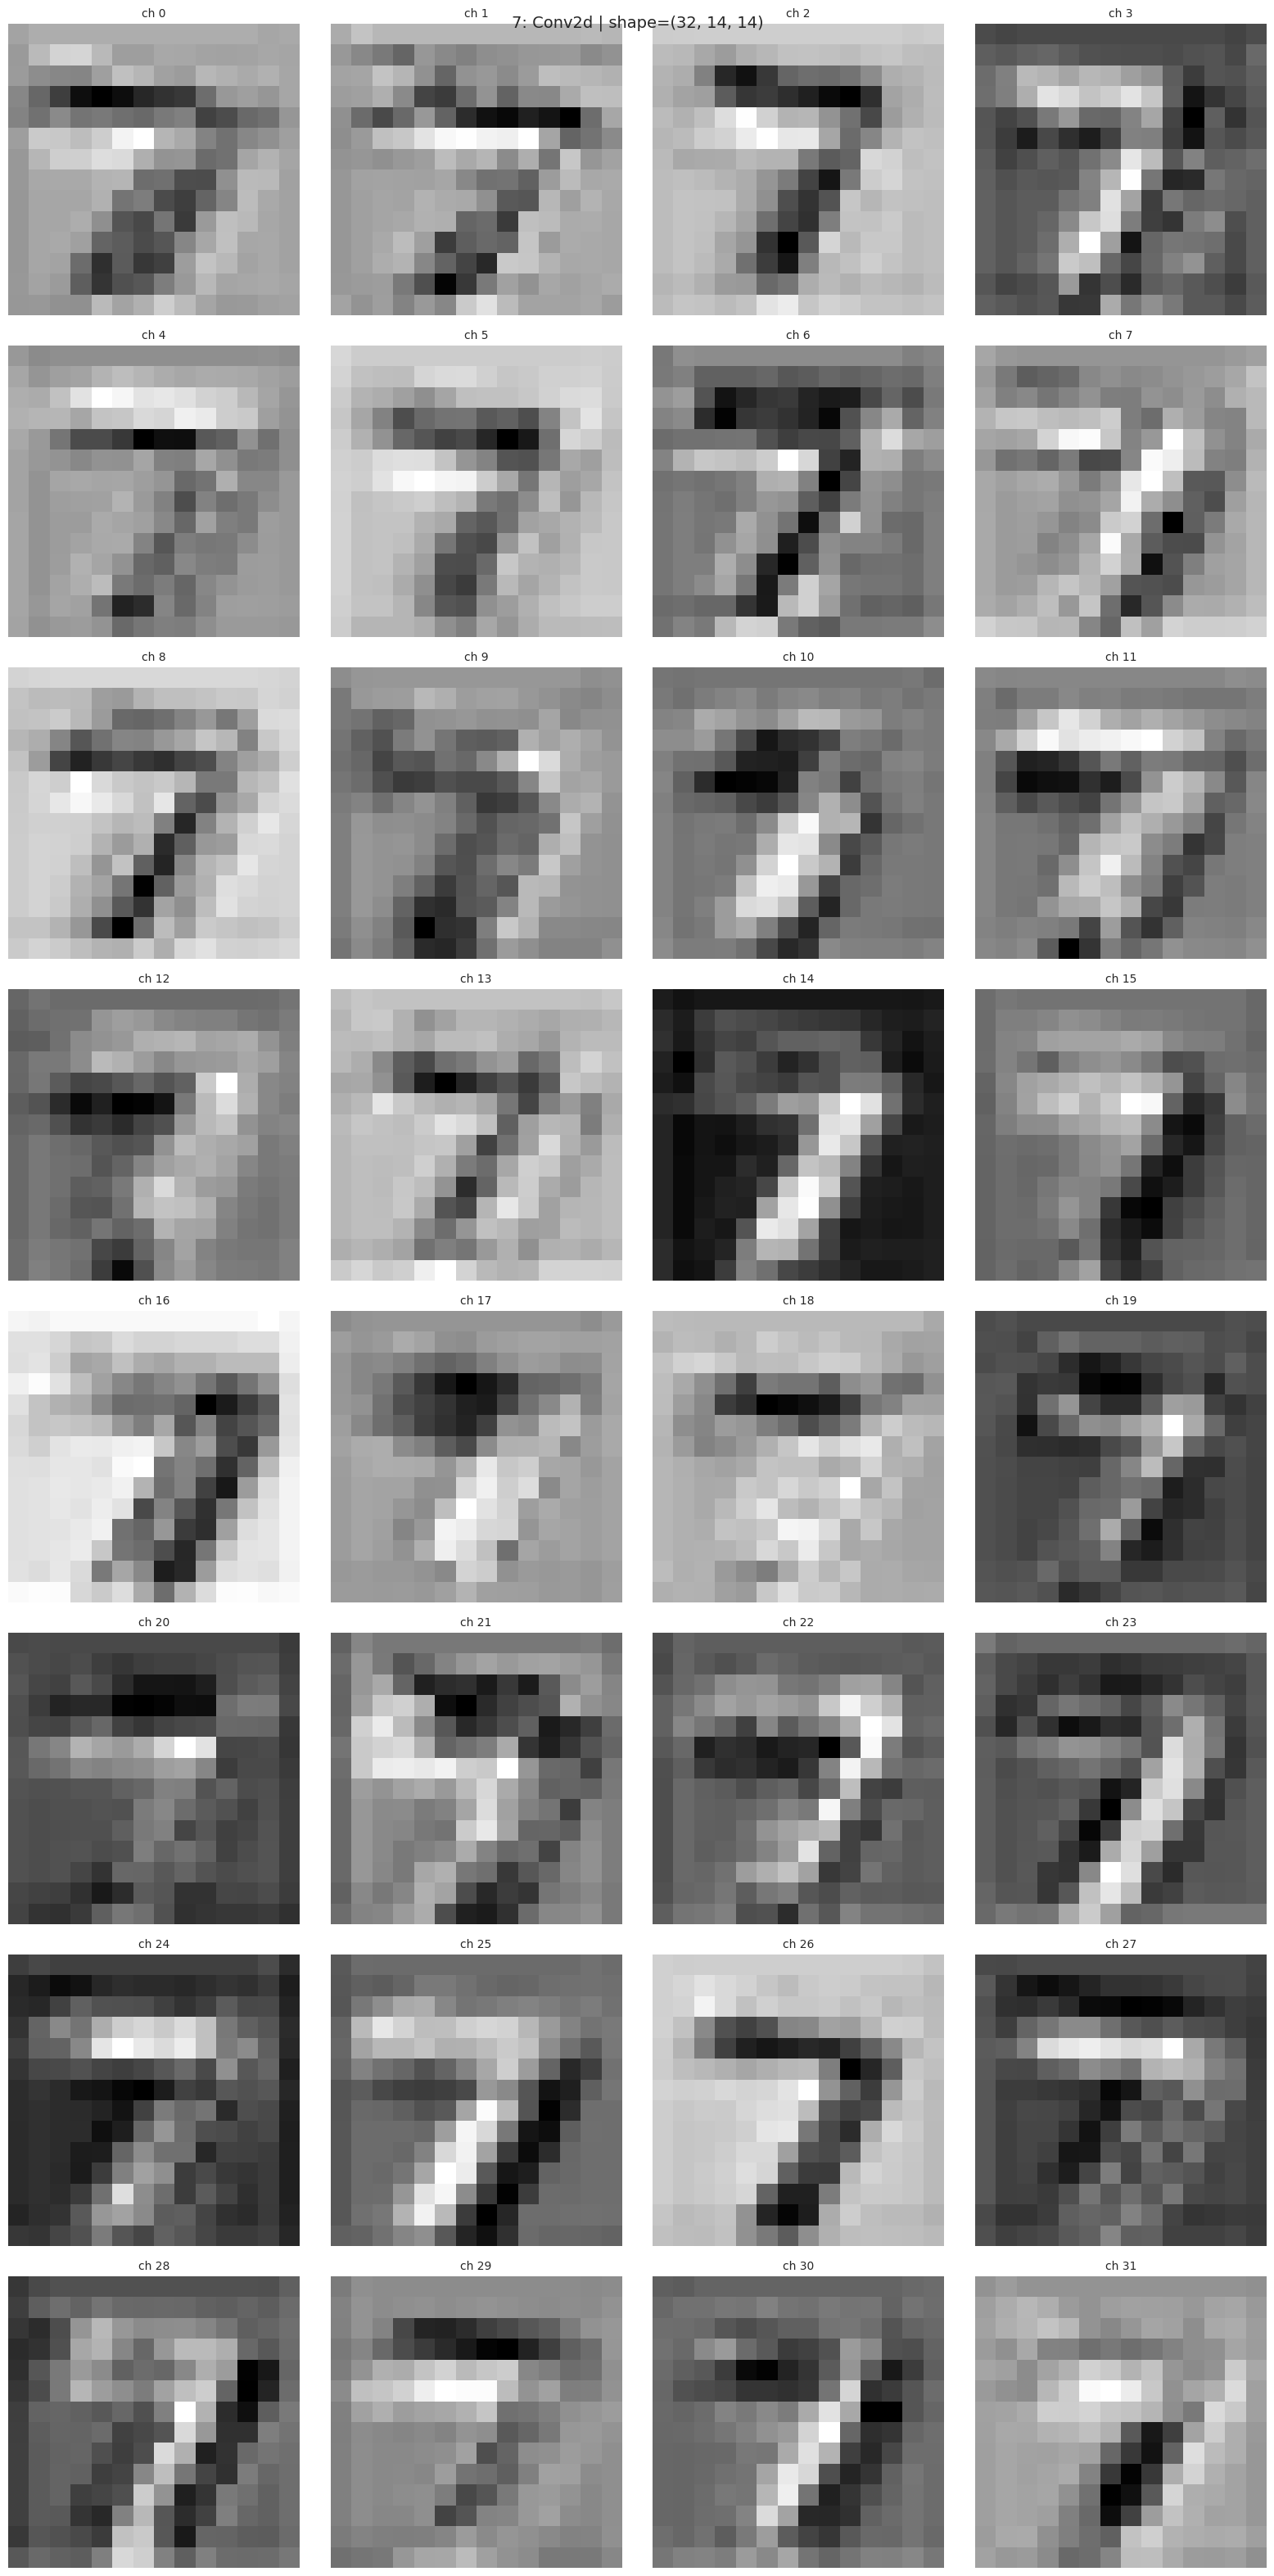

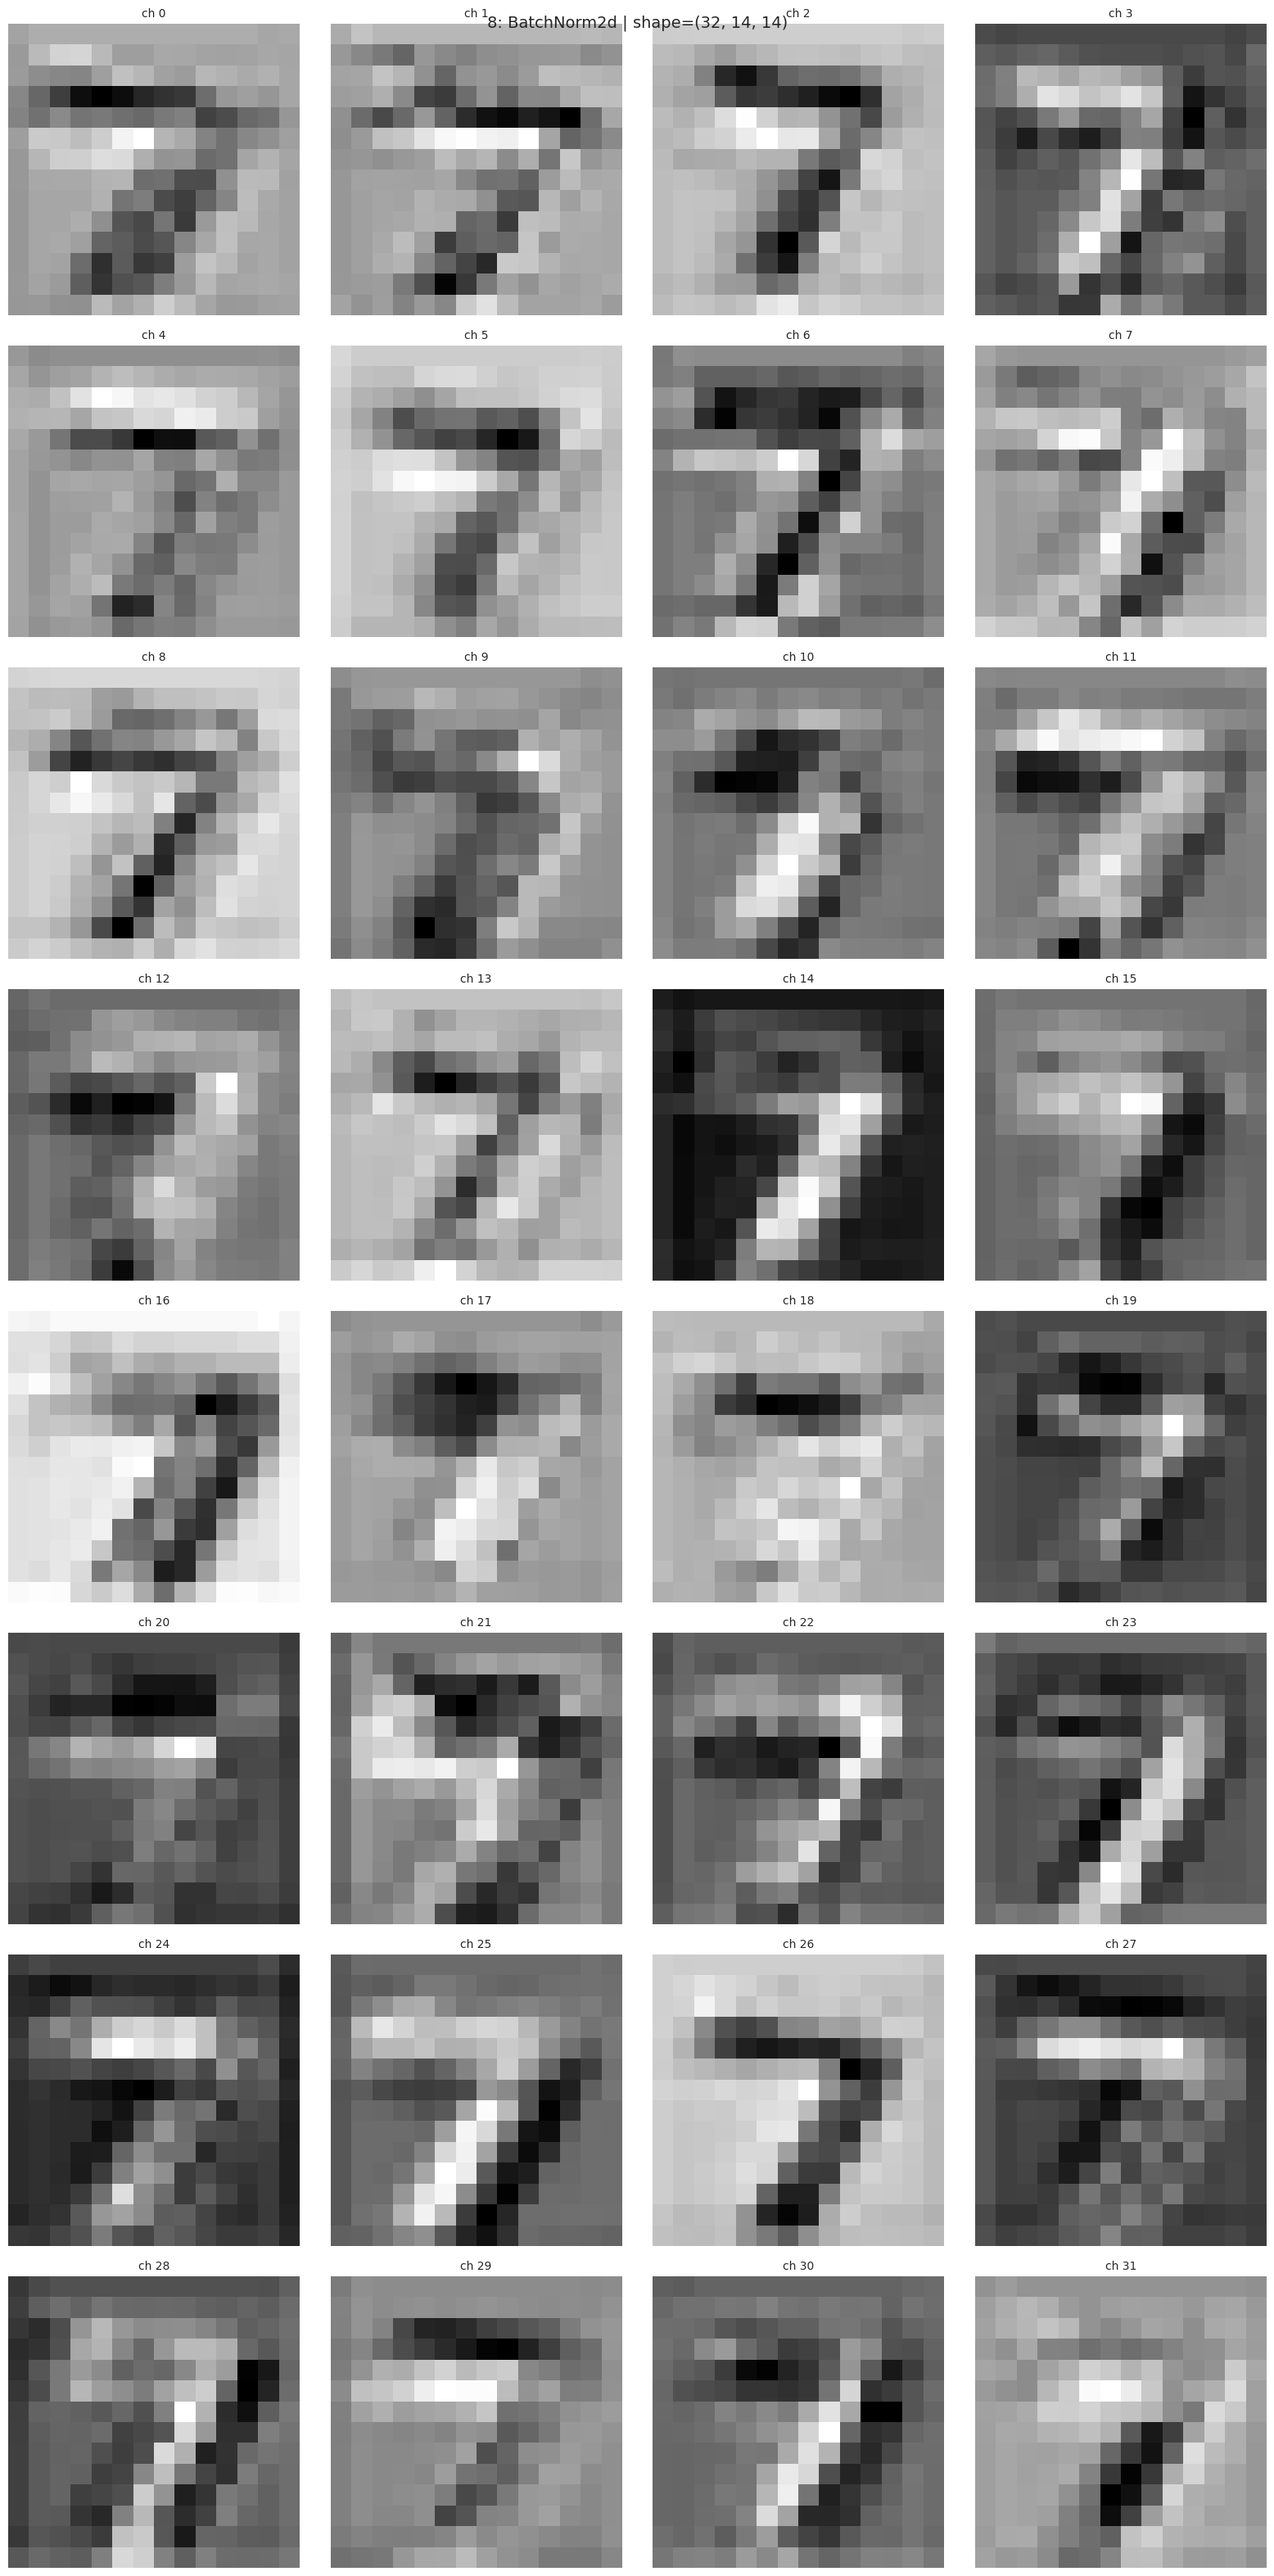

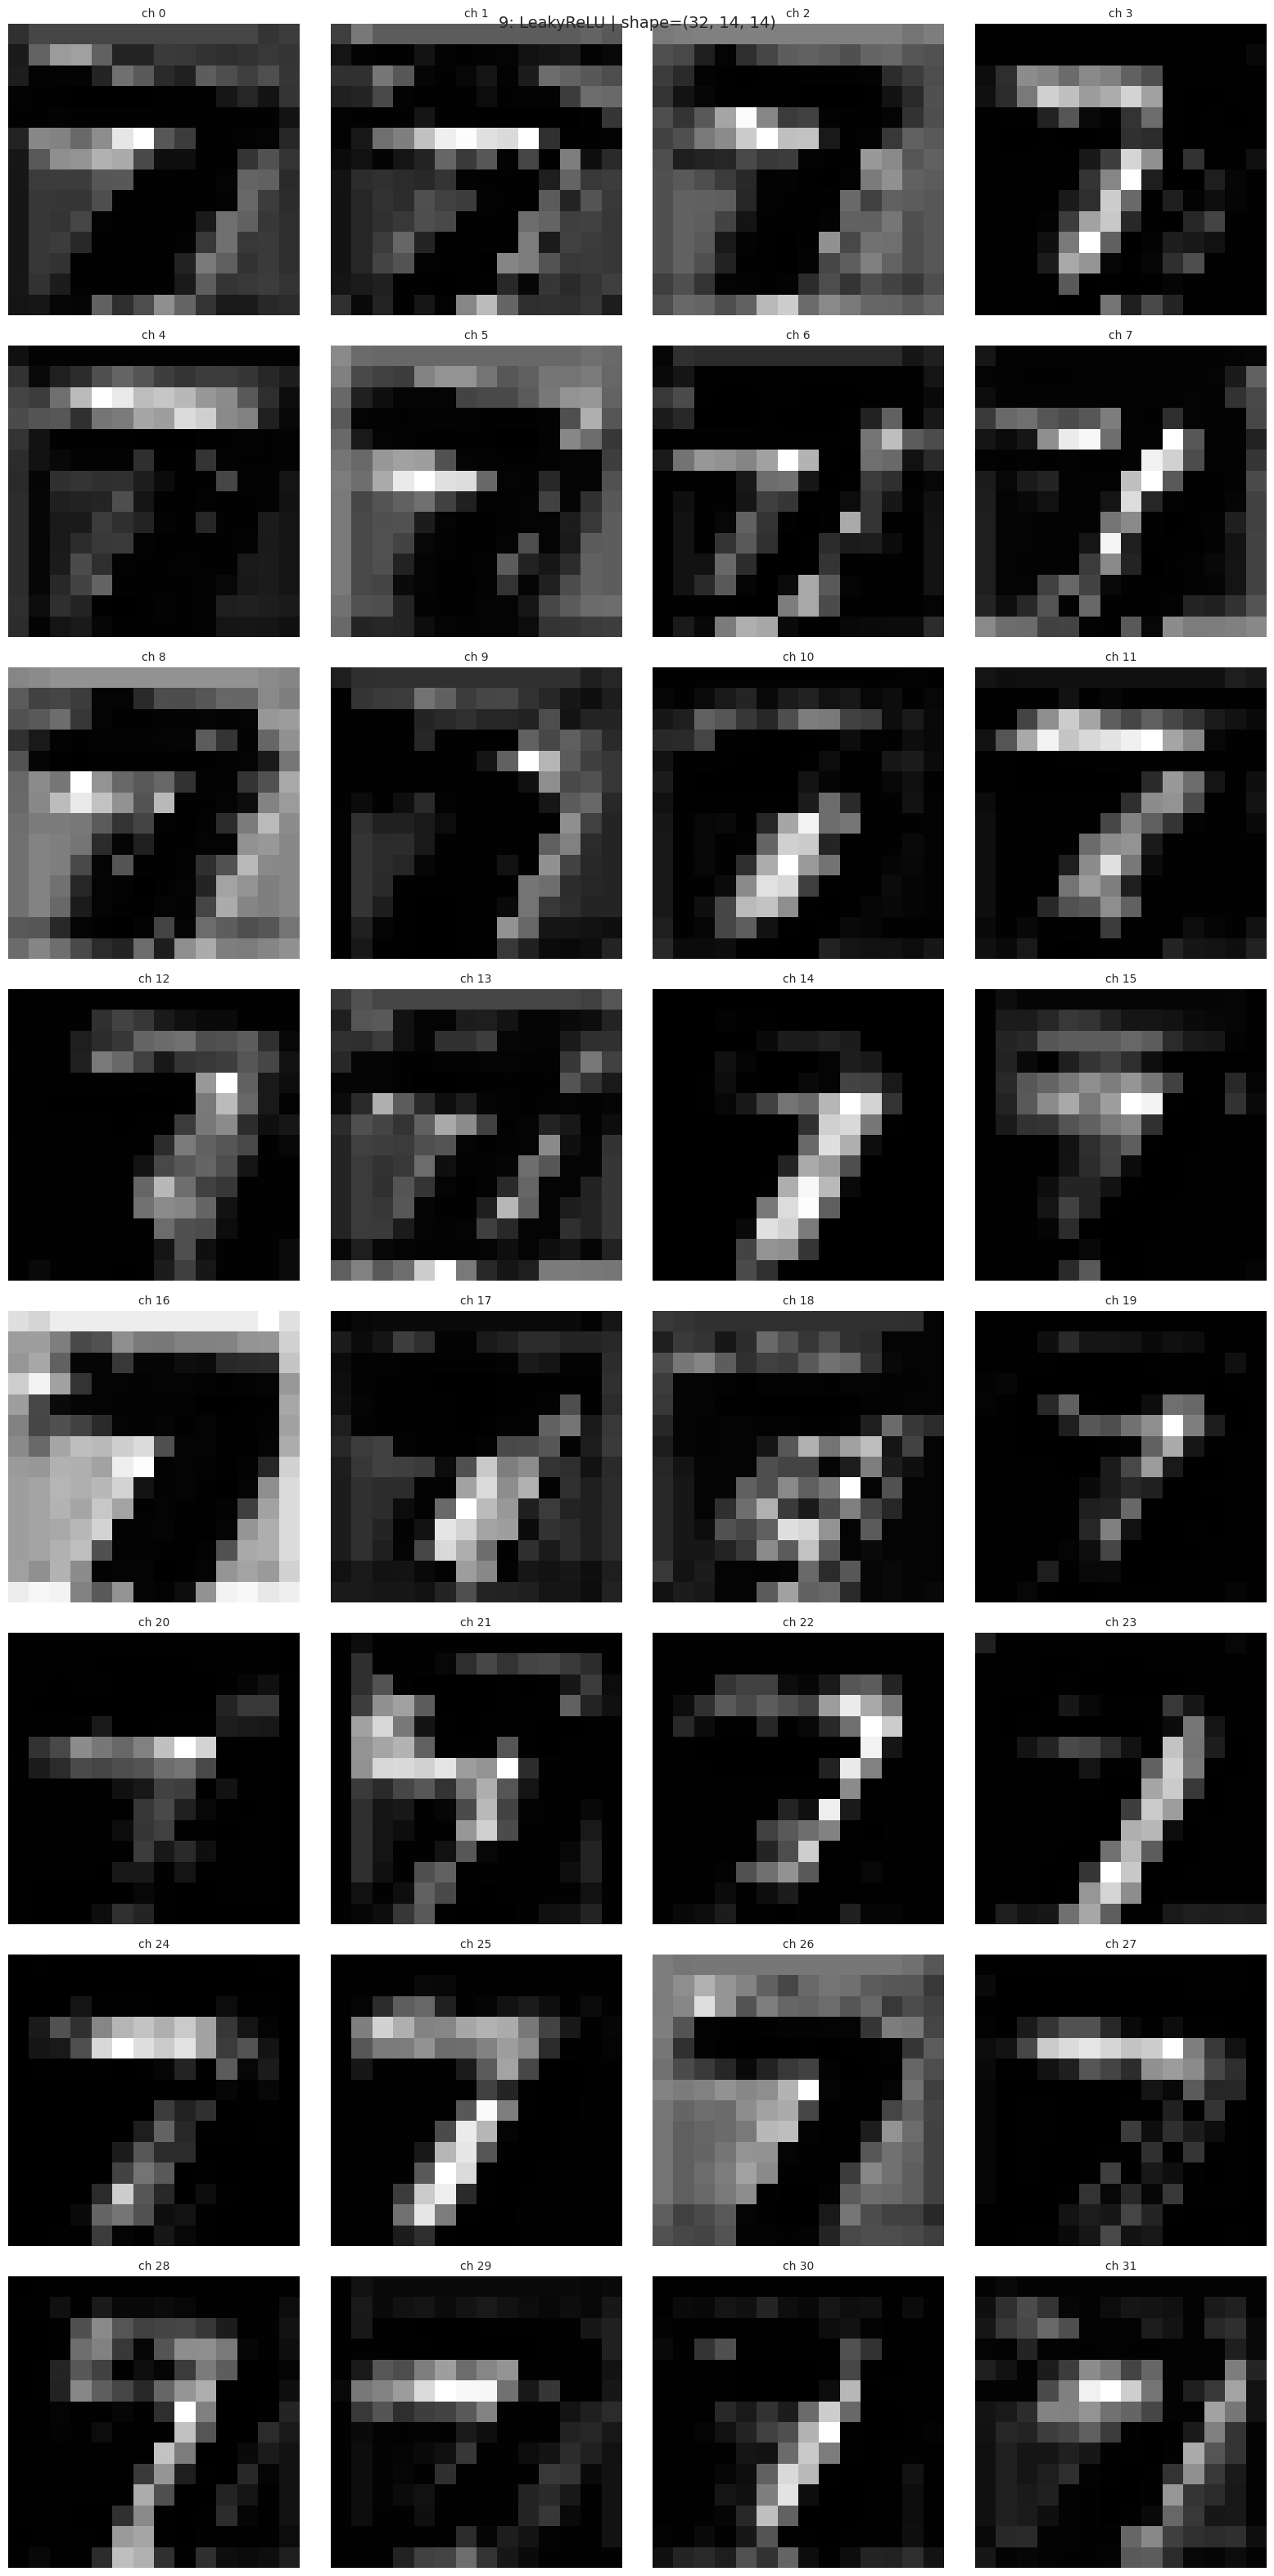

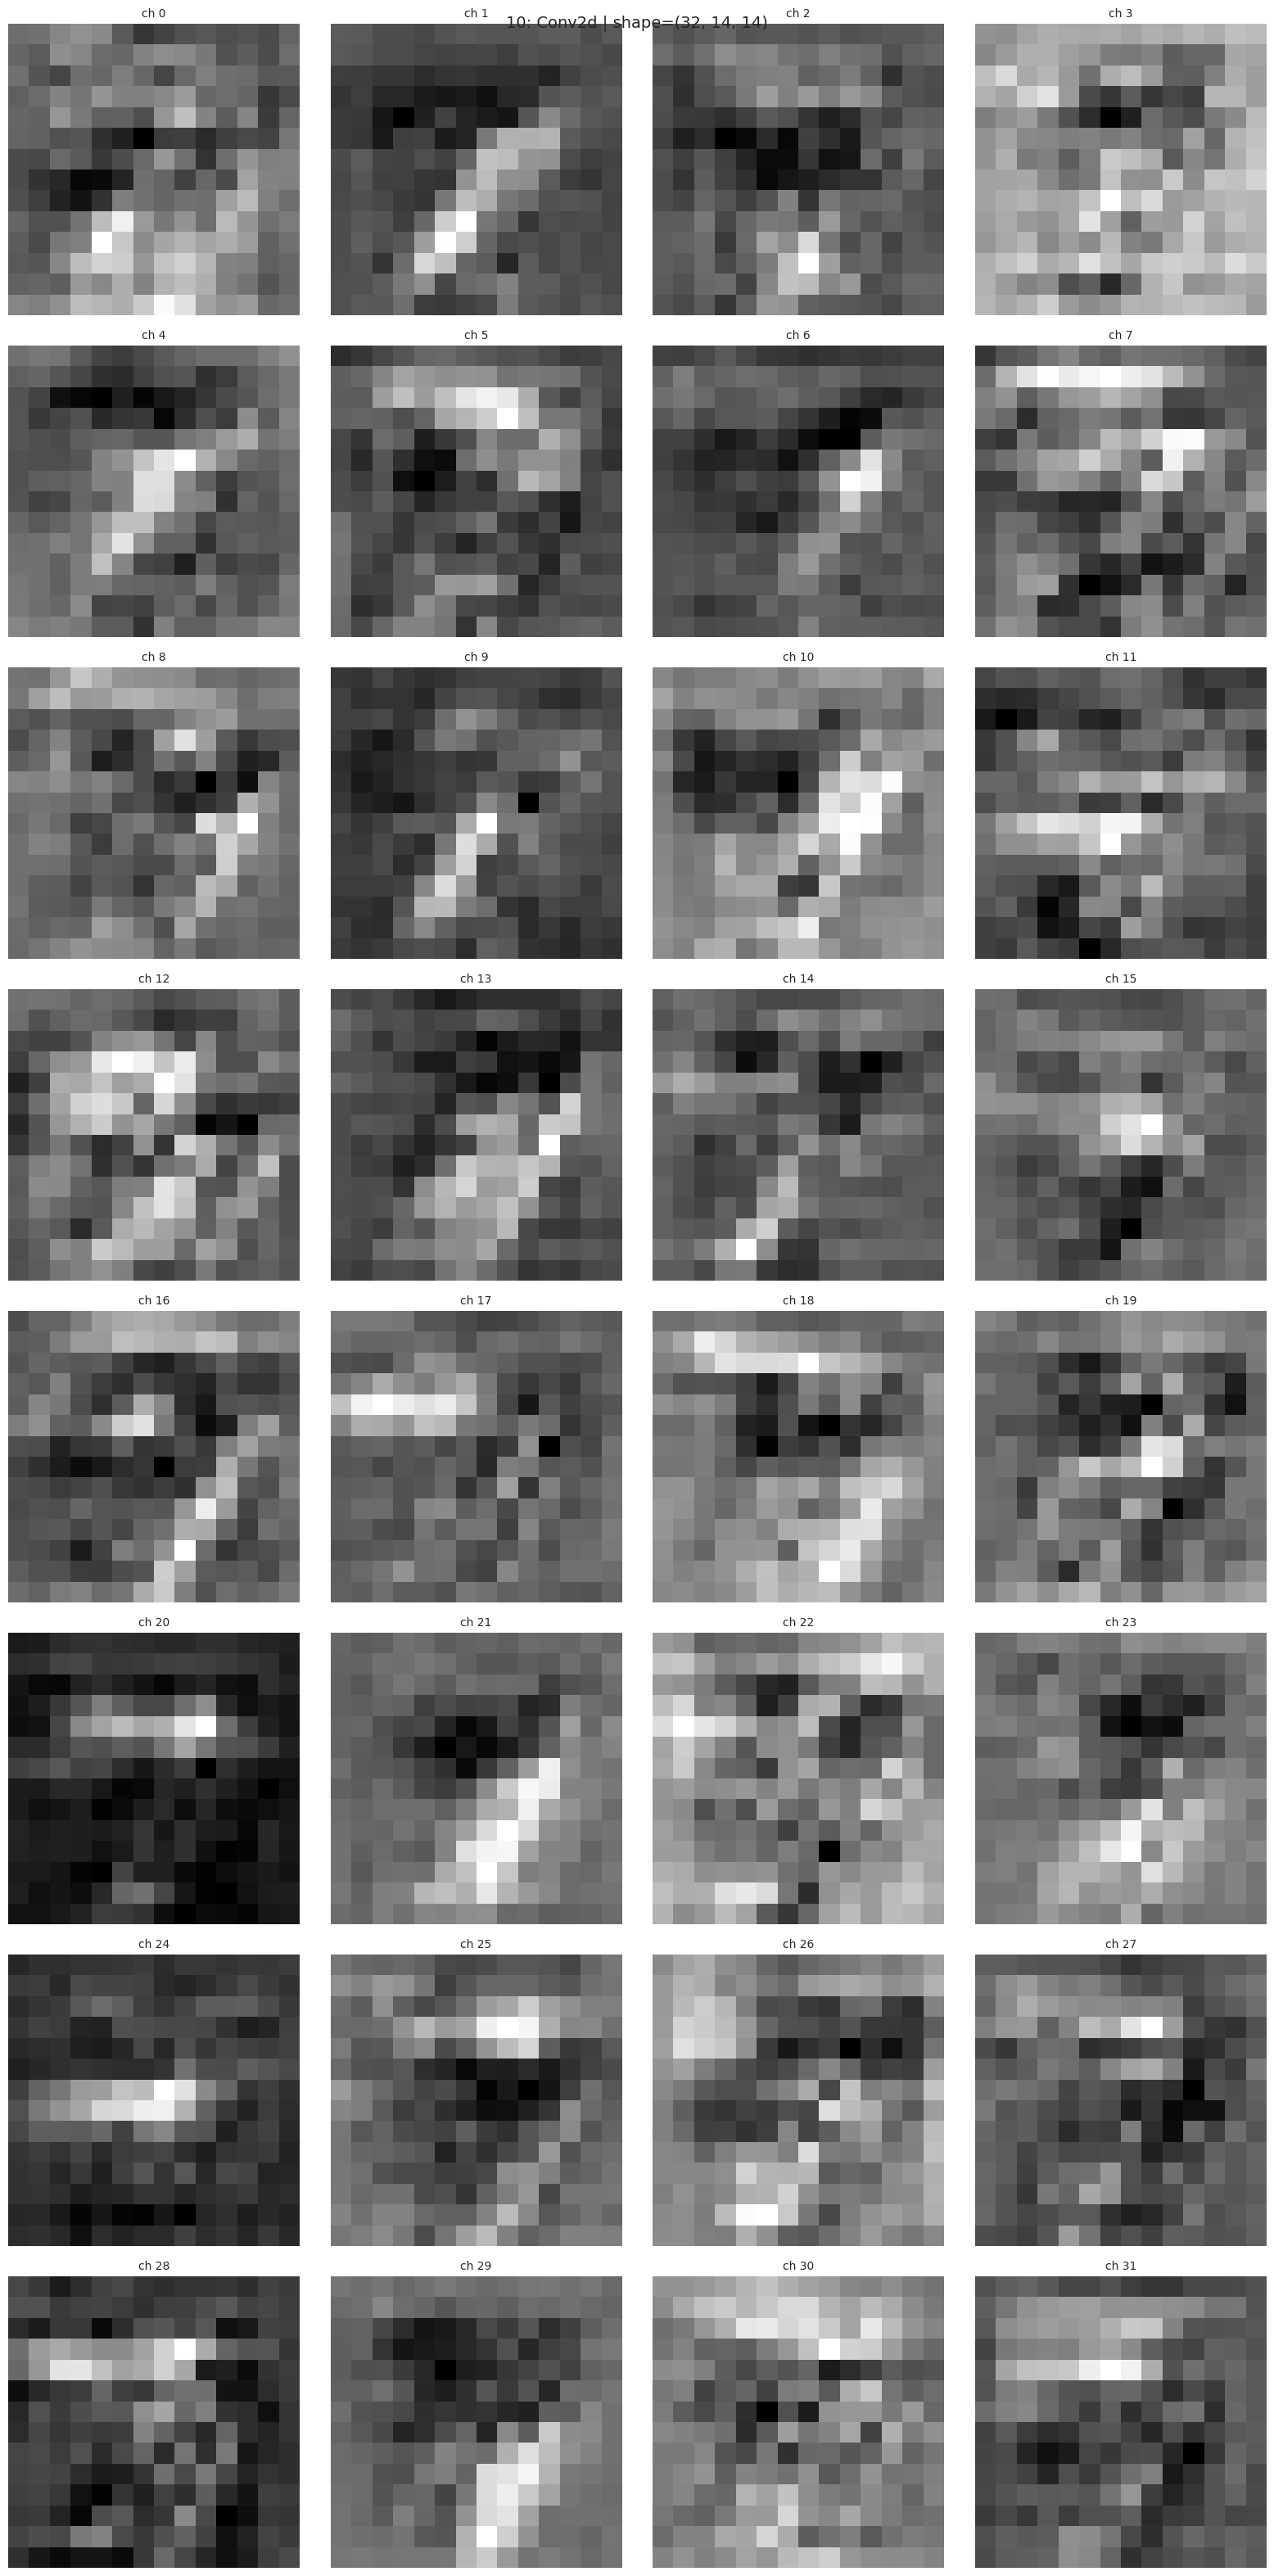

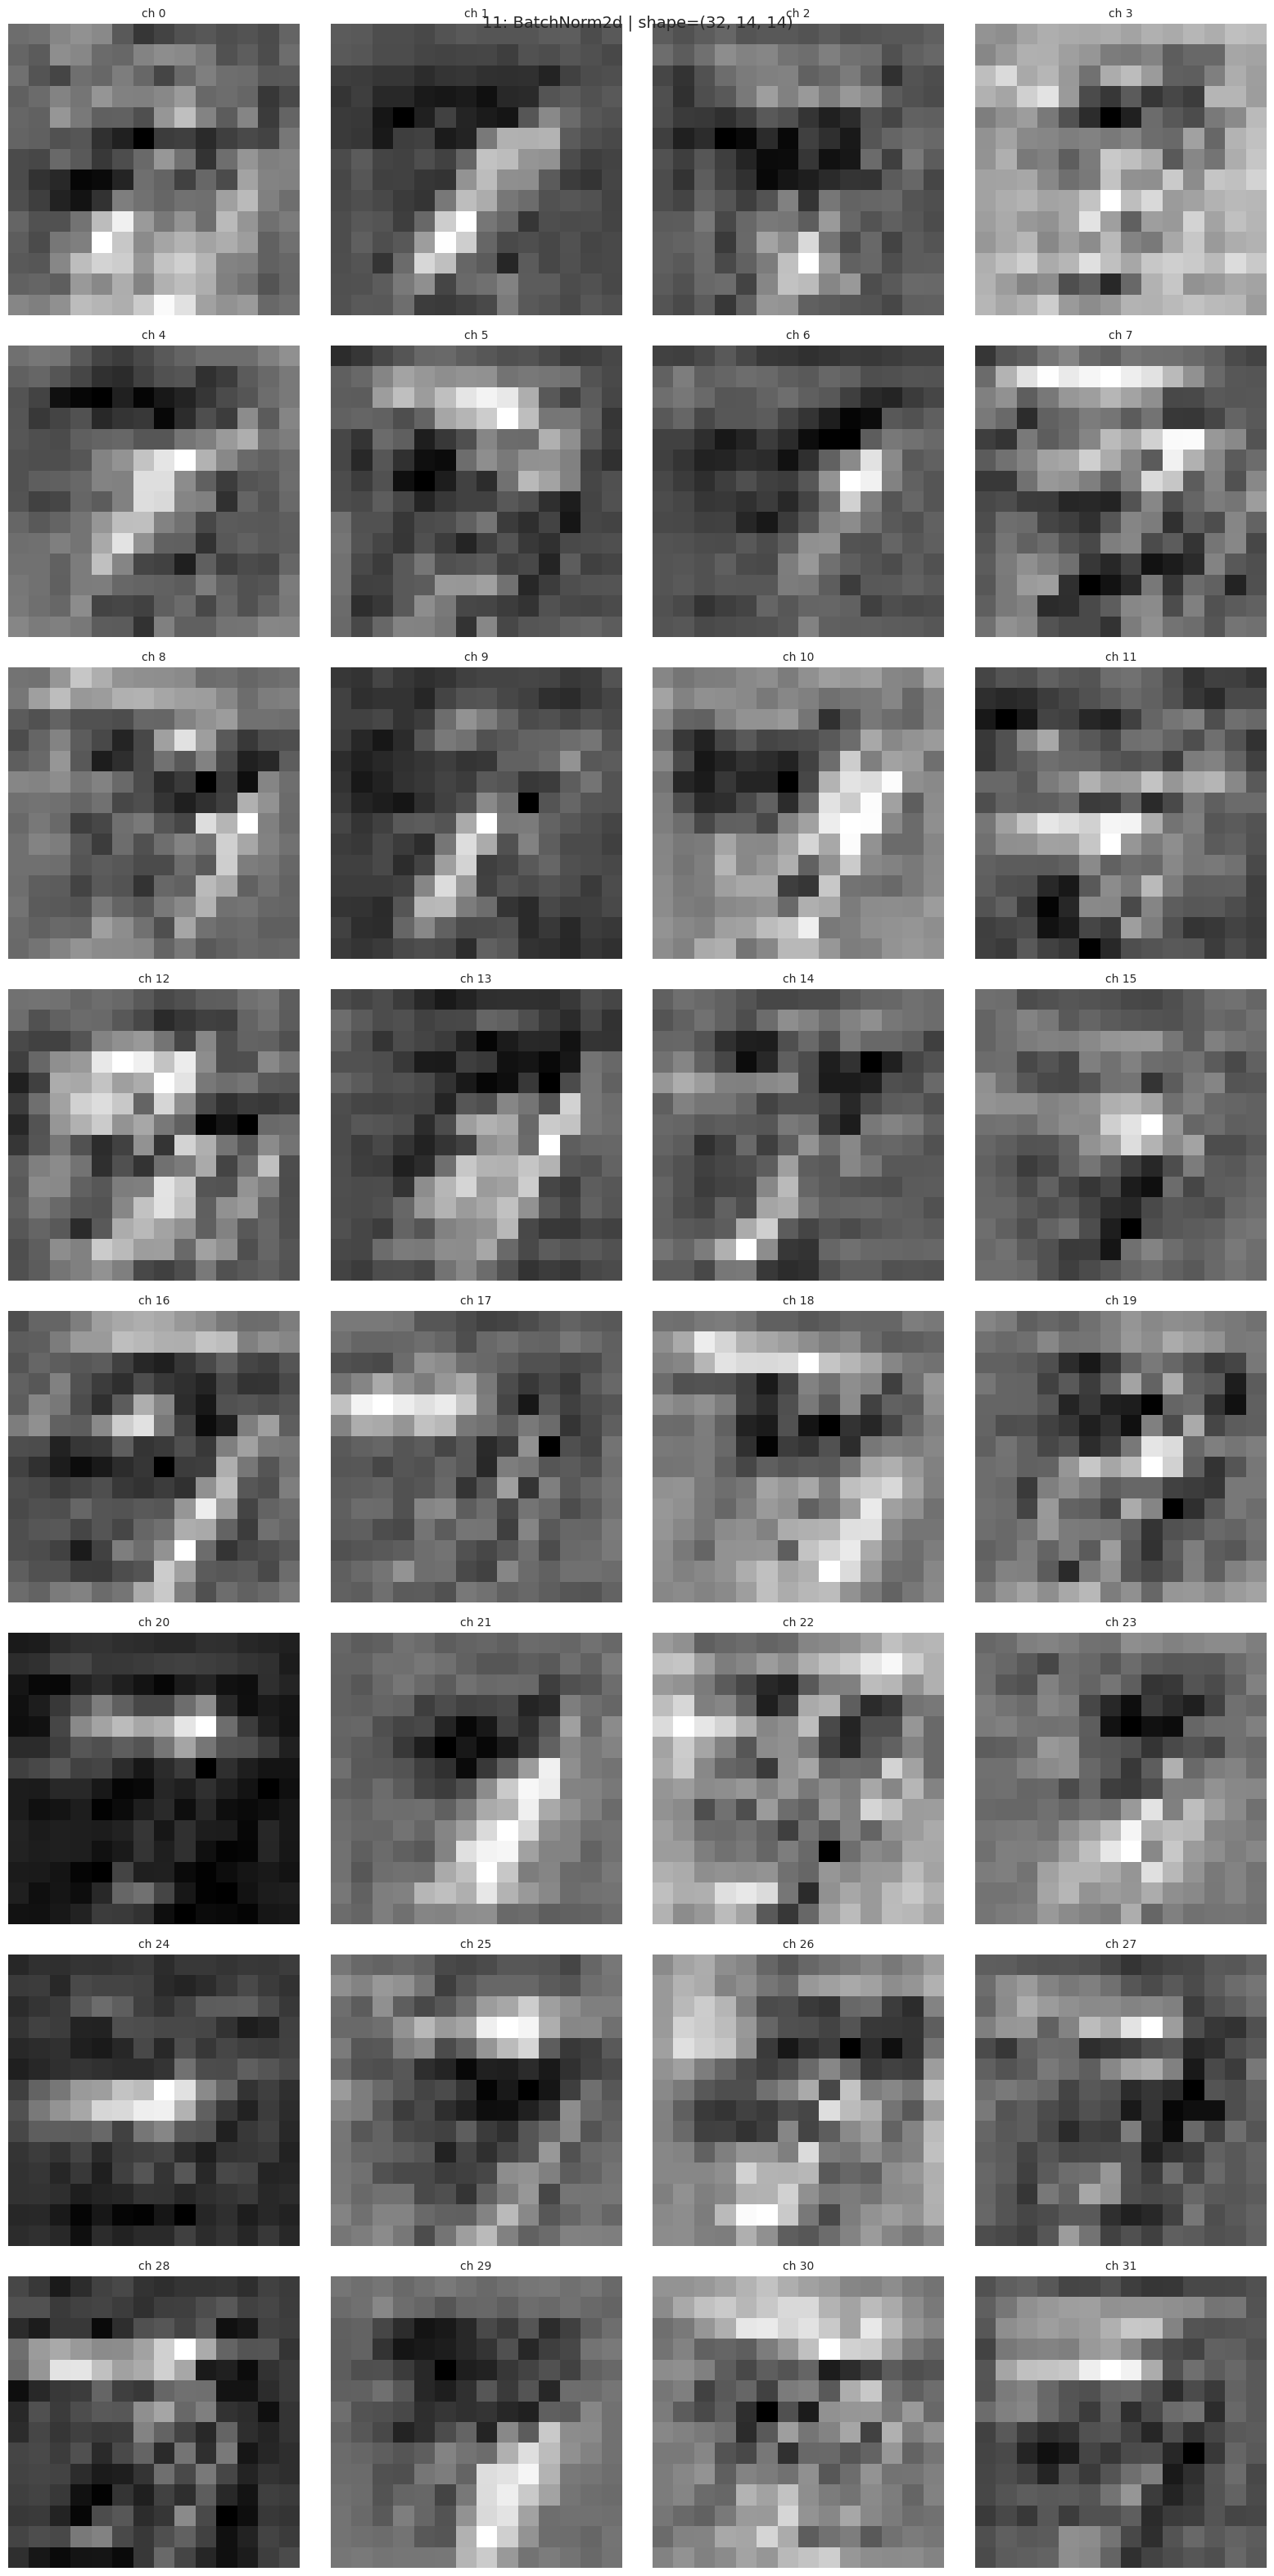

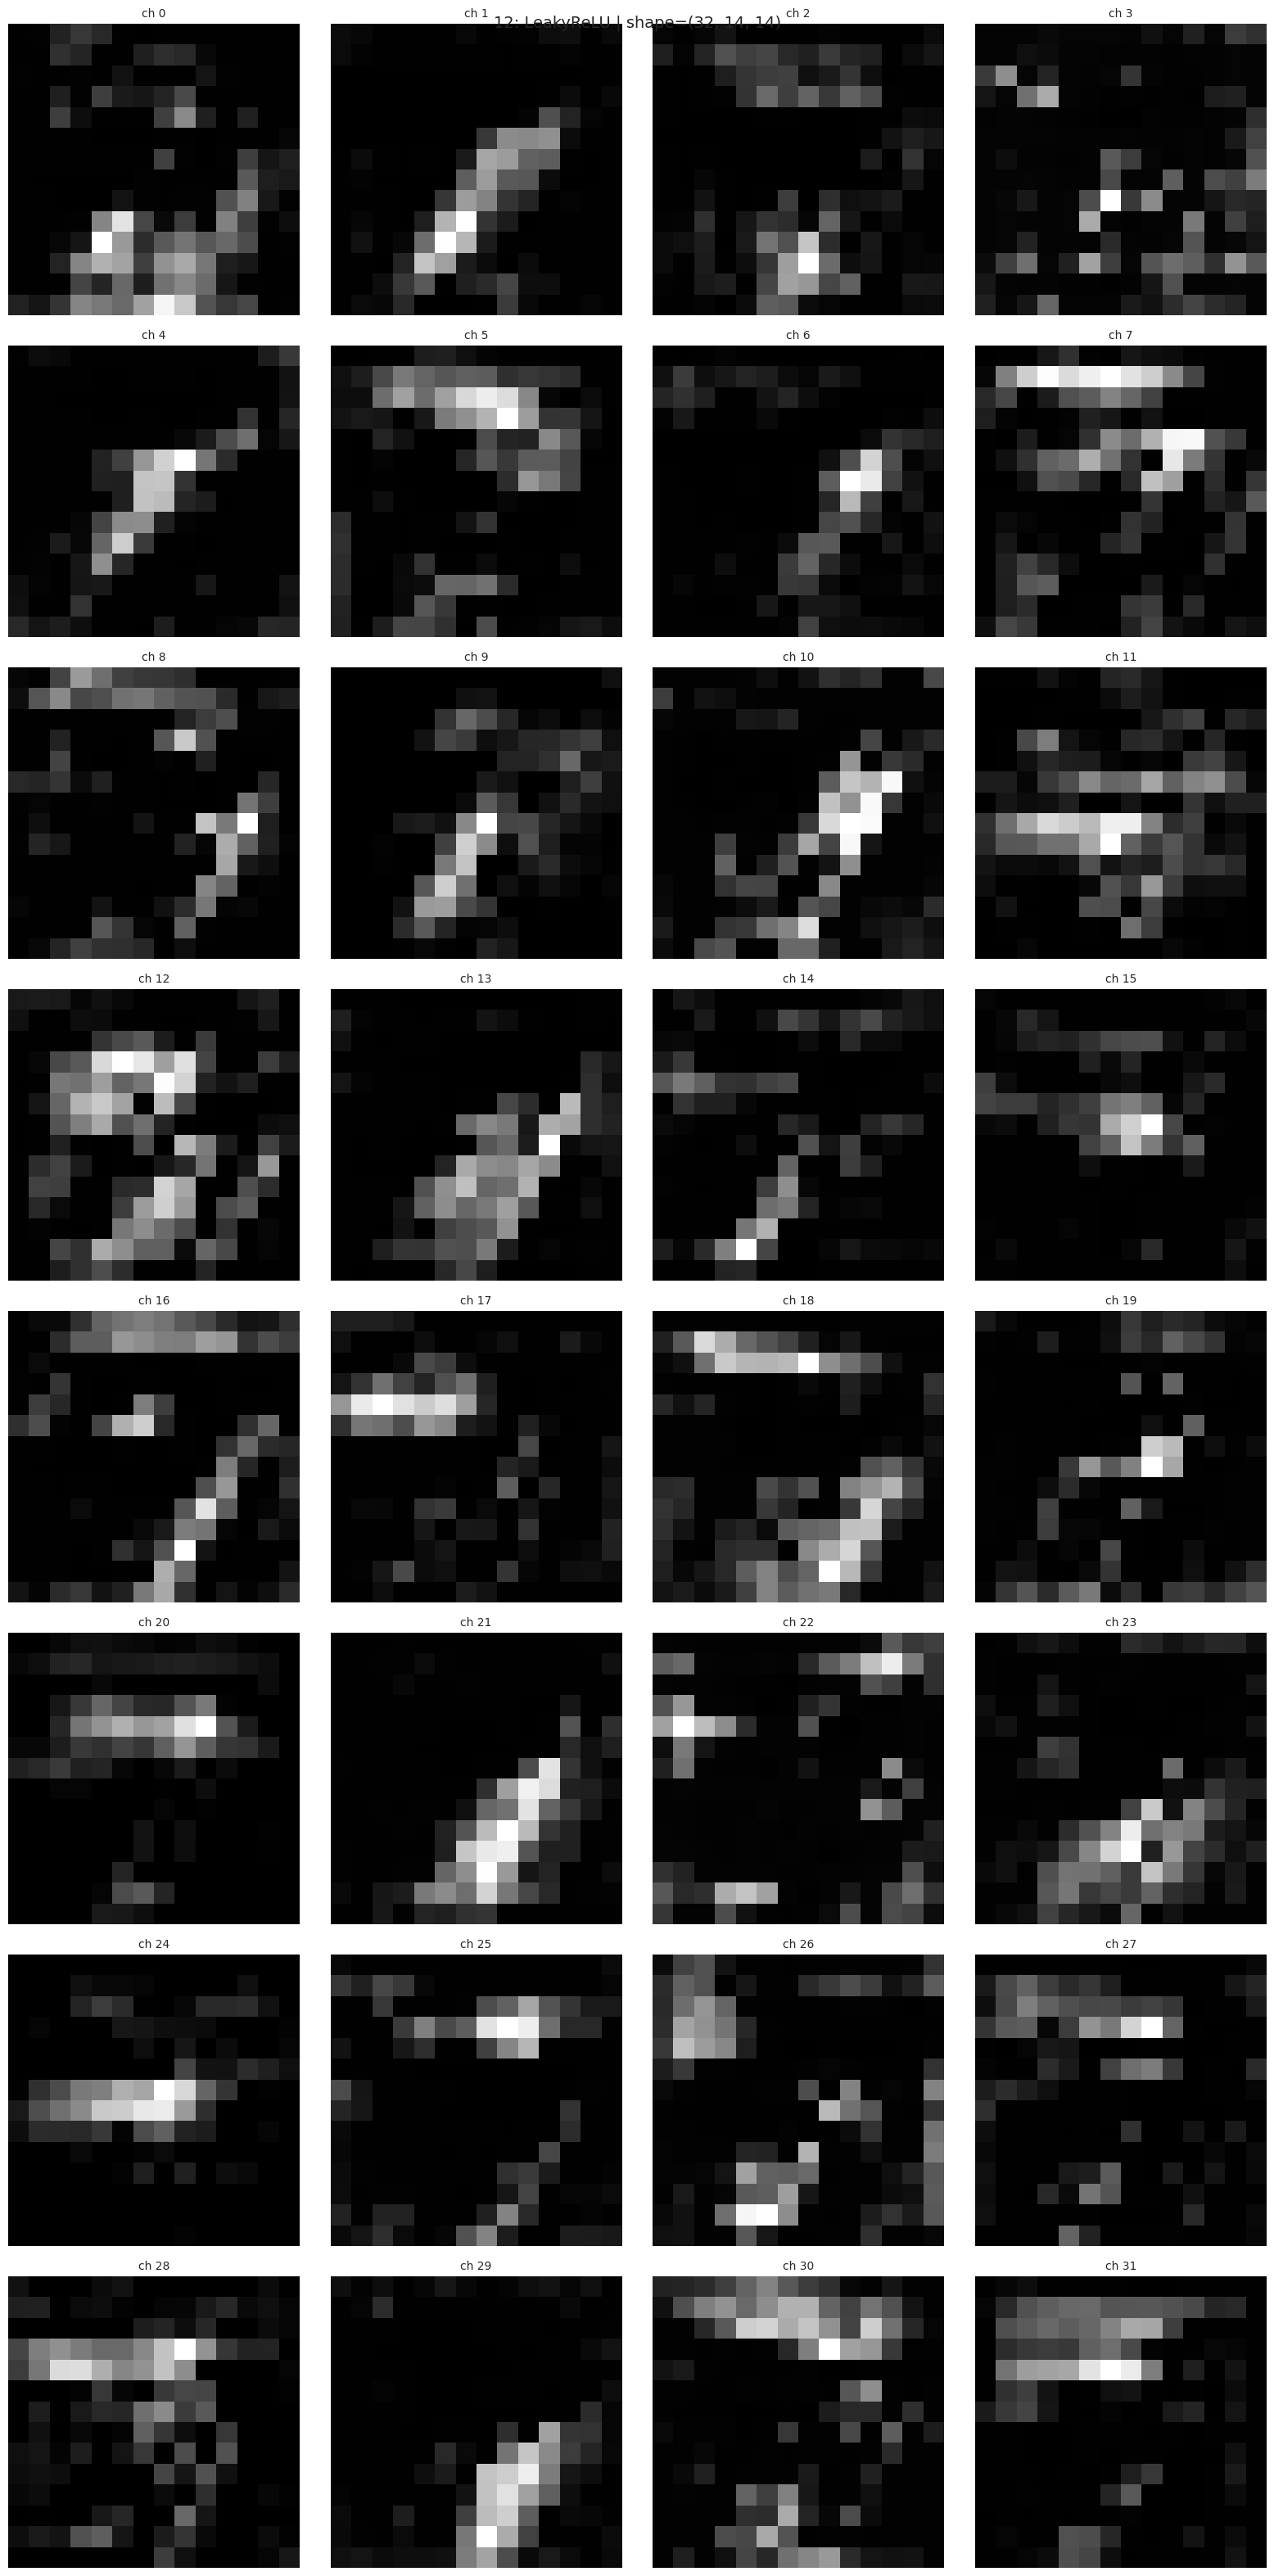

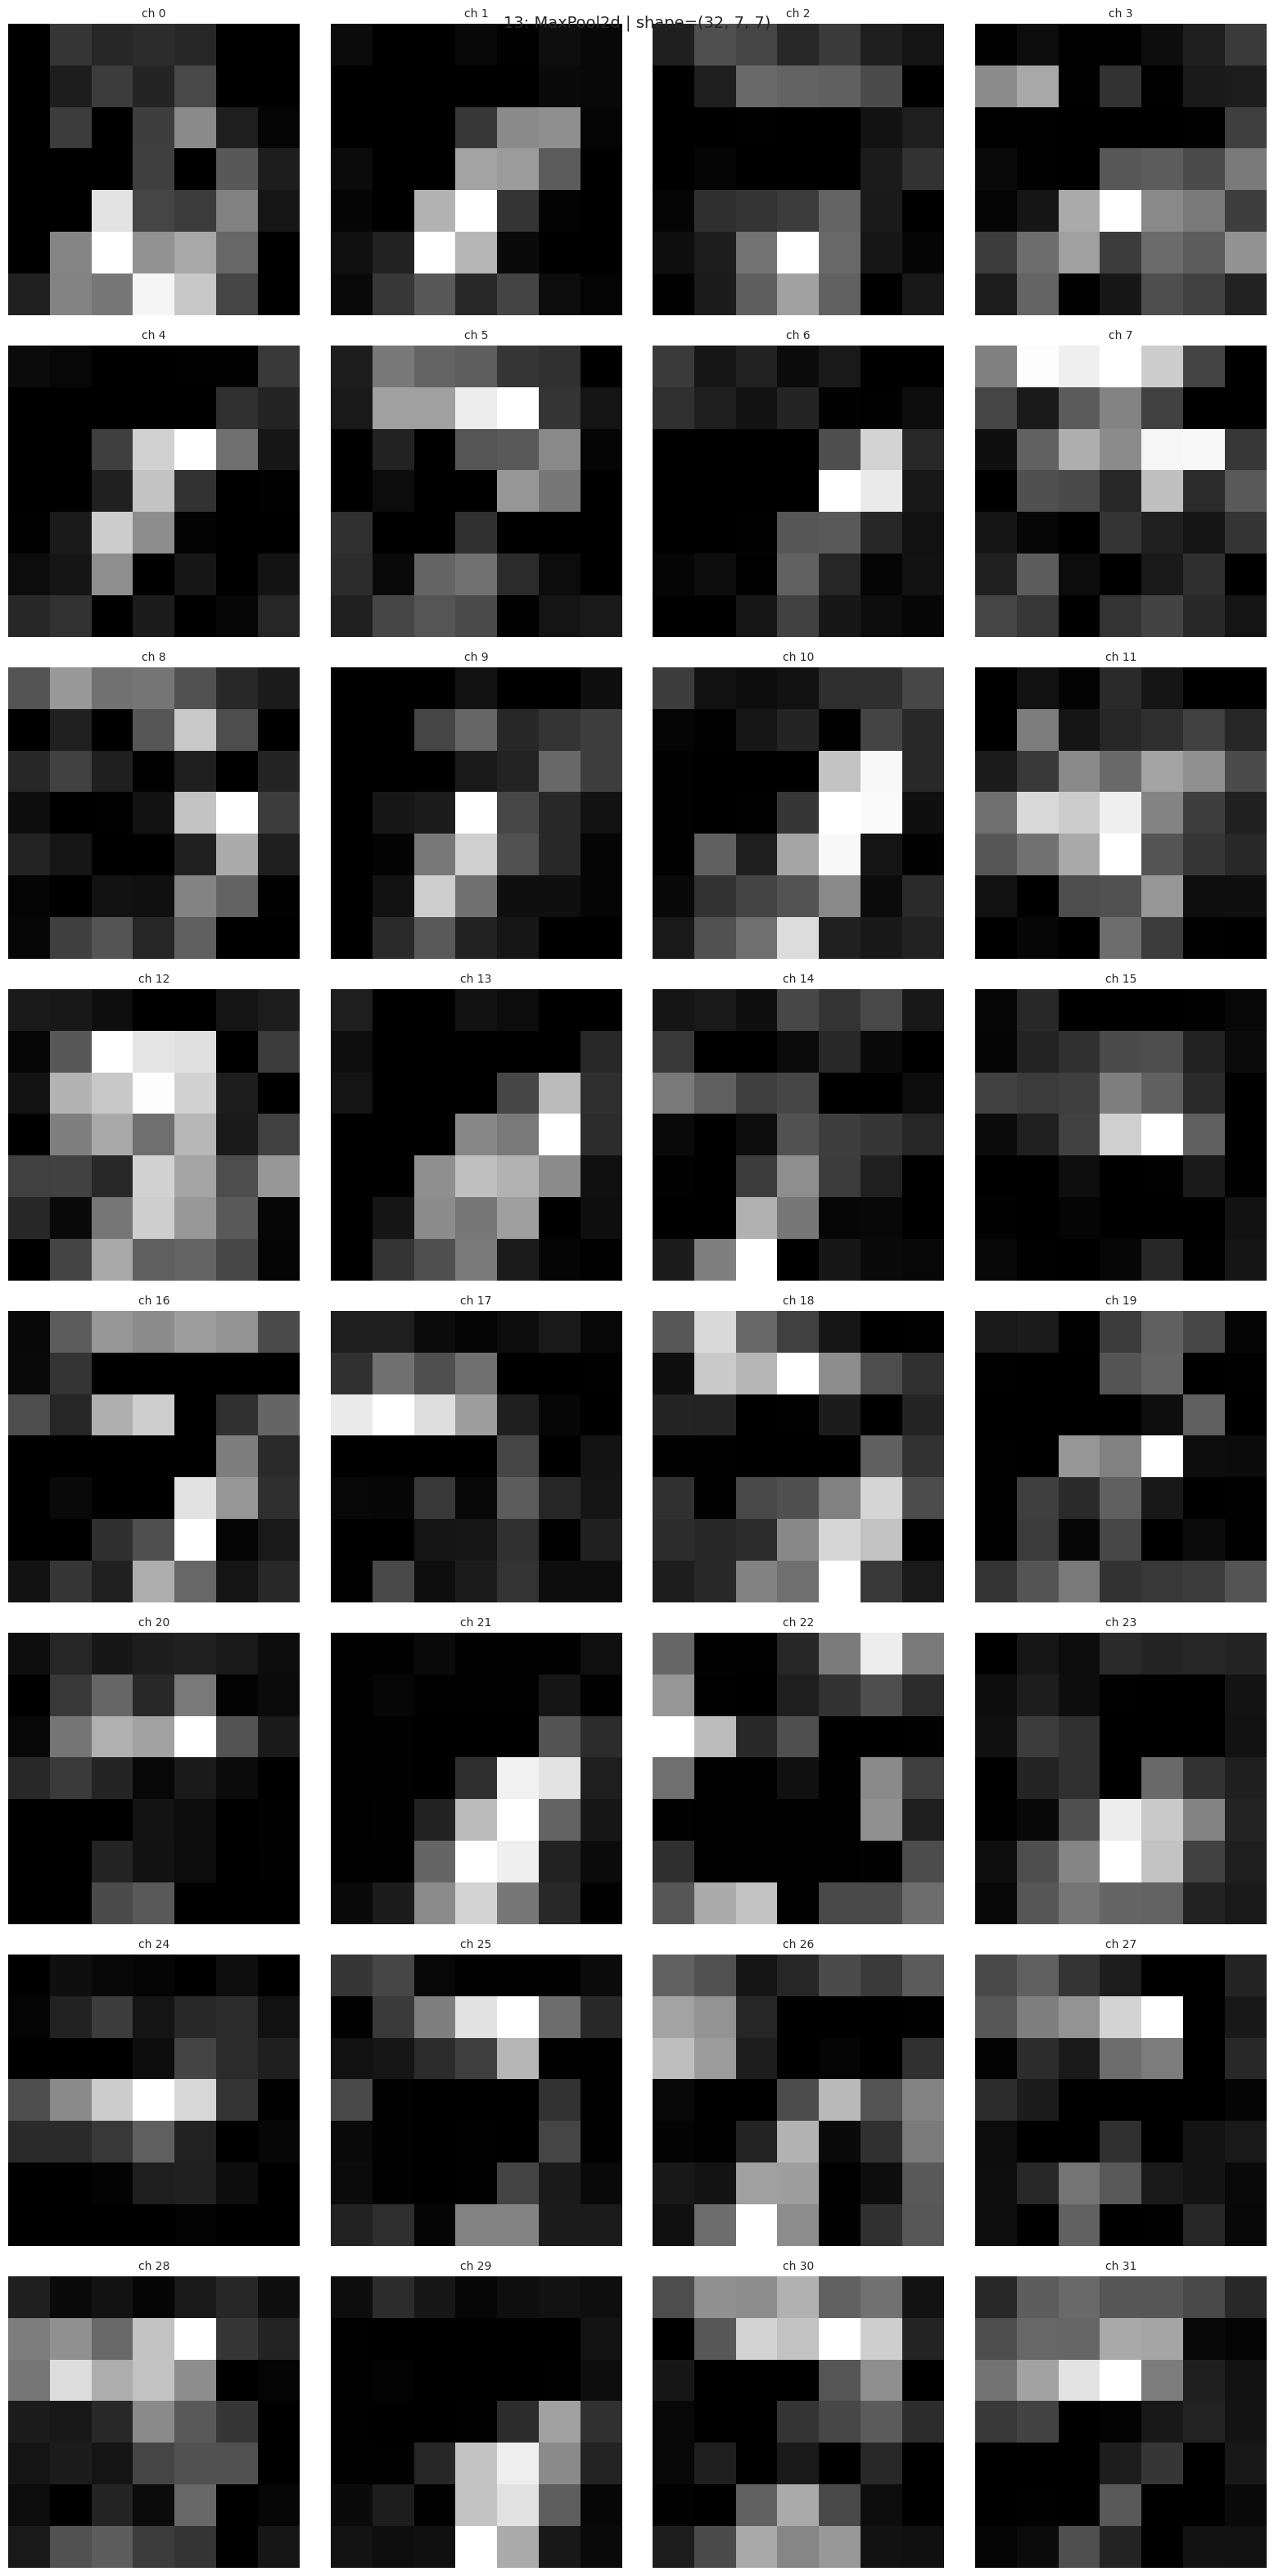

In [ ]:
from torch.nn.modules import activation
import math
idx = 0 # Я выбрал первое изображение из датасета
x, y = val_dataset[idx]
x = x.unsqueeze(0).to(device)

print("Label:", y)

activations = []
layer_names = []

current = x

for i, layer in enumerate(model):
  if isinstance(layer, nn.Flatten):
    break
  current = layer(current)

  activations.append(current.detach().cpu())
  layer_names.append(f"{i}: {layer.__class__.__name__}")
  print(f"Layer {i}: {layer.__class__.__name__}, output shape = {tuple(current.shape)}")

def show_32_feature_maps(feature_tensor, title=""):
    if feature_tensor.dim() == 4:
        feature_tensor = feature_tensor[0]

    num_channels = feature_tensor.shape[0]
    H, W = feature_tensor.shape[1], feature_tensor.shape[2]

    cols = 4
    rows = math.ceil(num_channels / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for c in range(num_channels):
        fm = feature_tensor[c]
        fm_min, fm_max = fm.min(), fm.max()
        if fm_max > fm_min:
            fm = (fm - fm_min) / (fm_max - fm_min)

        axes[c].imshow(fm, cmap='gray')
        axes[c].set_title(f"ch {c}", fontsize=10)
        axes[c].axis("off")

    for j in range(num_channels, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{title} | shape=({num_channels}, {H}, {W})", fontsize=14)
    plt.tight_layout()
    plt.show()

for name, act in zip(layer_names, activations):
    show_32_feature_maps(act, name)

Какие выводы можно сделать о том, как работает ваша сверточная сеть?

На начальных слоях видны куски линий и шум.
На средних слоях можно увидеть уже диагональ от семерки и иногда уже саму цифру.
На последних слоях отчетливо видна цифра 7
Это значит, последние каналы - детектирую паттерн - сама цифра, а не углы или прямые как в начальных слоях.

Визуализируйте, какие объекты, подаваемые на вход нейросети, в наибольшей степени активируют нейроны в сверточных слоях. Для этого оптимизируйте изображение, чтобы максимизировать выход нейрона.

Ниже представлен шаблон функции, которая находит изображение, максимально усиливающее реакцию нейрона. Пример можно посмотреть в <a href="https://thetahat.ru/files/ad/main/7/CV_complex_no_pause.pdf" target="_blank">презентации</a> с занятия.

In [ ]:
# При реализации запрещено пользоваться ИИ-инструментами.


def visualize_filter(
    model: nn.Module,
    layer_index: int,
    target_kernel: int,
    learning_rate: float = 1,
    steps: int = 10_000,
    image_size: int = 28,
    device: Union[str, torch.device] = "cpu",
) -> torch.Tensor:
    """Визуализирует фильтр сверточного слоя нейронной сети путем оптимизации
    входного изображения, которое максимизирует активацию заданного фильтра.

    Параметры:
        model (nn.Module): Модель нейронной сети, содержащая целевой сверточный слой.
        layer_index (int): Индекс целевого сверточного слоя в модели (по порядку в model.children()).
        target_kernel (int): Индекс фильтра в целевом слое для визуализации.
        learning_rate (float, optional): Скорость обучения для оптимизатора. По умолчанию 1.
        steps (int, optional): Количество шагов оптимизации. По умолчанию 10000.
        image_size (int, optional): Размер стороны квадратного входного изображения. По умолчанию 28.
        device (str|torch.device, optional): Устройство для вычислений ('cpu' или 'cuda'). По умолчанию "cpu".

    Возвращает:
        torch.Tensor: Оптимизированное изображение (тензор формы [1, C, H, W]),
                     которое максимизирует активацию целевого фильтра.
    """

    model.eval().to(device)  # Переводим модель в режим оценки
    for param in model.parameters():
      param.requires_grad_(False)

    layers = list(model.children())
    # Инициализируем изображение случайным шумом
    input_img = torch.randn(1, 1, image_size, image_size, requires_grad=True, device=device)
    # Обратите внимание, что в данном случае мы оптимизируем не модель, а входную картинку
    optimizer = optim.SGD([input_img], lr=learning_rate)

    # Функция потерь: максимизируем активацию нужного ядра свертки
    for step in range(steps):
        optimizer.zero_grad()
        output = input_img
        for i, layer in enumerate(layers[:layer_index + 1]):
            output = layer(output)

        activation = output[0, target_kernel]
        # Пропускаем изображение через модель
        loss = -activation.mean()  # Минимизируемая функция

        # Обратное распространение
        loss.backward()
        optimizer.step()

        # Ограничиваем значения пикселей в разумных пределах
        input_img.data = torch.clamp(input_img.data, -1, 1)

        # Логируем лосс
        if step % 500 == 0:
            print(f"Step {step}/{steps}, Loss: {loss.item():.4f}")

    # Преобразуем оптимизированное изображение
    img = input_img.detach().cpu()

    return img

Step 0/2000, Loss: -0.0594
Step 500/2000, Loss: -0.0672
Step 1000/2000, Loss: -0.0698
Step 1500/2000, Loss: -0.0723
Step 0/2000, Loss: 0.2758
Step 500/2000, Loss: 0.2680
Step 1000/2000, Loss: 0.2538
Step 1500/2000, Loss: 0.2398
Step 0/2000, Loss: 0.1153
Step 500/2000, Loss: 0.0971
Step 1000/2000, Loss: 0.0831
Step 1500/2000, Loss: 0.0693
Step 0/2000, Loss: -0.1226
Step 500/2000, Loss: -0.1225
Step 1000/2000, Loss: -0.1228
Step 1500/2000, Loss: -0.1232
Step 0/2000, Loss: -0.1099
Step 500/2000, Loss: -0.1097
Step 1000/2000, Loss: -0.1117
Step 1500/2000, Loss: -0.1137
Step 0/2000, Loss: -0.1456
Step 500/2000, Loss: -0.1582
Step 1000/2000, Loss: -0.1650
Step 1500/2000, Loss: -0.1717
Step 0/2000, Loss: 0.0310
Step 500/2000, Loss: 0.0220
Step 1000/2000, Loss: 0.0068
Step 1500/2000, Loss: -0.0082
Step 0/2000, Loss: 0.1836
Step 500/2000, Loss: 0.1843
Step 1000/2000, Loss: 0.1828
Step 1500/2000, Loss: 0.1812


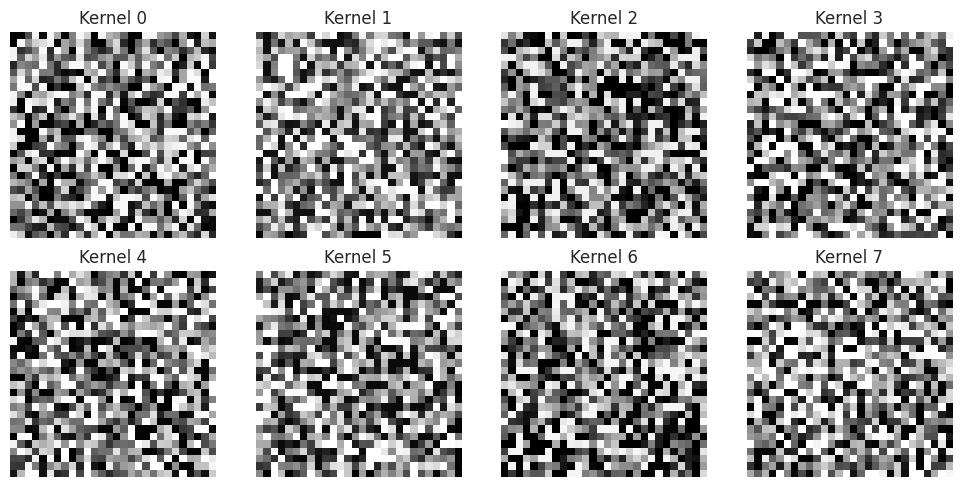

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for k, ax in enumerate(axes.flat):
    img = visualize_filter(
        model=model,
        layer_index=0,
        target_kernel=k,
        learning_rate=0.1,
        steps=2000,
        image_size=28,
        device=device,
    )
    ax.imshow(img[0, 0], cmap="gray")
    ax.set_title(f"Kernel {k}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Визуализация показала, что картинки, активирующие фильтры сильнее всего - абстрактные текстуры. Это из-за того, что без регуляризации град спуск находит экстремальные значения пикселей, которые дают наибольший отклик.

Сделайте выводы о том, как с глубиной слоя меняется способность нейрона видеть различные паттерны на изображении.

Первые слои - пиксели, простые паттерны
Средние слои - куски изображения
Последние слои - почти все изображение
Это так, так как ядро размера(например 3*3) видит только 3*3 картинку, то есть всего 9 пикселей. Следующие нейроны уже видят предыдущие нейроны, которые видят нейроны на предыдущем слое и следовательно видят больше.

---
### Задача 3. Перенос стиля

*Данную задачу, возможно, проще сделать в Google Colab.*

В данной задаче вы потренируетесь в работе с картинками и составлением промптов. Используя код с <a href="https://thetahat.ru/courses/ad/main/7/cv_complex_examples" target="_blank">семинара</a>, проведите перенос стиля на хотя бы 4 своих примерах.

> Заметьте, что в примерах с семинара в качестве картинок стиля и контента использовались картинки среднего разрешения. Если возникают проблемы, например:
> * оптимизация останавливается на 0-й эпохе и не создает картинку;
> * loss в какой-то момент стал nan;
> * нехватка RAM;
>
> то либо уменьшите разрешение ваших картинок, либо попробуйте картинку полегче.

In [ ]:
import os
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

sns.set(palette="Set2")

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/nazianafis/Neural-Style-Transfer
# Перейдем в директорию скачанного репозитория
%cd /content/Neural-Style-Transfer/

# Небольшая обработка скрипта, не менять!
file_path = "NST.py"
with open(file_path, "r") as file:
    # Убираем автоматический запуск
    lines = file.readlines()[:183]
# Вывод логов только каждые 100 эпох
lines = lines[:175] + ["            if cnt % 100 == 0:\n"] + lines[175:]
lines[176] = "    " + lines[176]
with open(file_path, "w") as file:
    file.writelines(lines)

from NST import *

Cloning into 'Neural-Style-Transfer'...
remote: Enumerating objects: 379, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 379 (delta 72), reused 105 (delta 34), pack-reused 225 (from 1)
Receiving objects: 100% (379/379), 92.21 MiB | 32.84 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/Neural-Style-Transfer


In [ ]:
def run_neural_style_transfer(content_image="c1.jpg", style_image="s1.jpg"):
    """
    Функция для запуска метода Neural Style Transfer.

    :param content_image: имя файла картинки контента
    :param style_image: имя файла картинки стиля
    :return: results_path -- путь к папке, в которую сохранился результат
    """
    PATH = "/content/drive/MyDrive/Colab Notebooks/Введение_в_АД"
    default_resource_dir = os.path.join(PATH, "Data")
    content_images_dir = os.path.join(default_resource_dir, "content-images")
    style_images_dir = os.path.join(default_resource_dir, "style-images")
    output_img_dir = os.path.join(default_resource_dir, "output-images")
    img_format = (4, ".jpg")

    # Задаем конфиги, включая вес компонент лосса
    optimization_config = {
        "content_img_name": content_image,
        "style_img_name": style_image,
        "height": 400,
        "content_weight": 100000.0,
        "style_weight": 30000.0,
        "tv_weight": 1.0,
    }
    optimization_config["content_images_dir"] = content_images_dir
    optimization_config["style_images_dir"] = style_images_dir
    optimization_config["output_img_dir"] = output_img_dir
    optimization_config["img_format"] = img_format

    results_path = neural_style_transfer(optimization_config)
    return results_path

def visualize_style_transfer(content_image, style_image, results_path):
    """
    Визуализация результатов.

    :param content_image: имя файла картинки контента
    :param style_image: имя файла картинки стиля
    :param results_path: путь к папке, в которую сохранился результат
    """
    if len(os.listdir(results_path)) == 0:
        return

    PATH = "/content/drive/MyDrive/Colab Notebooks/Введение_в_АД"
    data_dir = os.path.join(PATH, "Data")

    plt.figure(figsize=(13, 3))

    combined_image = Path(content_image).stem + "_" + Path(style_image).stem + ".jpg"

    image_paths = [
        os.path.join(data_dir, "content-images", content_image),
        os.path.join(results_path, combined_image),
        os.path.join(data_dir, "style-images", style_image),
    ]

    titles = ["Контент", "Результат", "Стиль"]

    for i in range(len(image_paths)):
        plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(plt.imread(image_paths[i]))
        plt.title(titles[i])
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
content_images = sorted(os.listdir("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/content-images"))
style_images = sorted(os.listdir("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/style-images"))

result_paths = []
for content_image, style_image in zip(content_images, style_images):
    results_path = run_neural_style_transfer(content_image, style_image)
    result_paths.append(results_path)

Using VGG19 in the optimization procedure.
L-BFGS | iteration: 000, total loss=508268838912.0000, content_loss=      0.0000, style loss=508257180000.0000, tv loss=11649072.0000
L-BFGS | iteration: 100, total loss=8915448832.0000, content_loss=1444344335.9375, style loss=7457943750.0000, tv loss=13161108.0000
L-BFGS | iteration: 200, total loss=4047865088.0000, content_loss=1492531835.9375, style loss=2542335937.5000, tv loss=12997366.0000
L-BFGS | iteration: 300, total loss=3026119168.0000, content_loss=1480420019.5312, style loss=1532648437.5000, tv loss=13050896.0000
L-BFGS | iteration: 400, total loss=2641471232.0000, content_loss=1461566406.2500, style loss=1166863945.3125, tv loss=13040947.0000
L-BFGS | iteration: 500, total loss=2433060864.0000, content_loss=1443059179.6875, style loss=976926503.9062, tv loss=13075151.0000
L-BFGS | iteration: 600, total loss=2301794048.0000, content_loss=1427098144.5312, style loss=861503613.2812, tv loss=13192403.0000
L-BFGS | iteration: 700, to

In [ ]:
for content_image, style_image, results_path in zip(
    content_images, style_images, result_paths
):
  visualize_style_transfer(content_image, style_image, results_path)

Output hidden; open in https://colab.research.google.com to view.

Для тех же пар изображений контест-стиль попытайтесь сгенерировать картинку с таким контекстом и стилем с помощью диффузионной модели, рассмотренной на семинаре, задав нужный промпт.

In [ ]:
!pip install -q diffusers

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16"
).to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

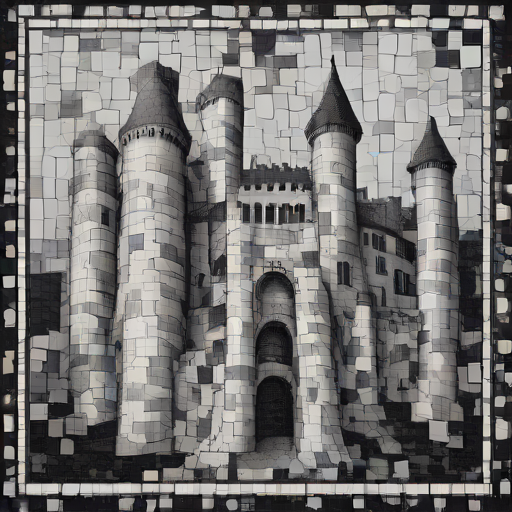

In [ ]:
prompt = "Medival castle, \
black and white mosaic"

# Передаем prompt в pipe, указываем параметры
# Модель проводит генерацию картинки, соответствующей запросу
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
image.save("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/diffusion/castle.png")
image

  0%|          | 0/1 [00:00<?, ?it/s]

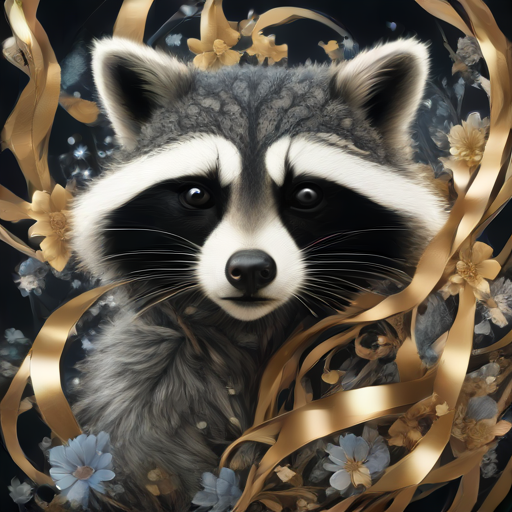

In [ ]:
prompt = "raccoon with flowers, \
Abstract futuristic fractal composition with glowing, \
golden flowing ribbons, intricate swirling patterns,\
    3D render"

# Передаем prompt в pipe, указываем параметры
# Модель проводит генерацию картинки, соответствующей запросу
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
image.save("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/diffusion/raccoon.png")
image

  0%|          | 0/1 [00:00<?, ?it/s]

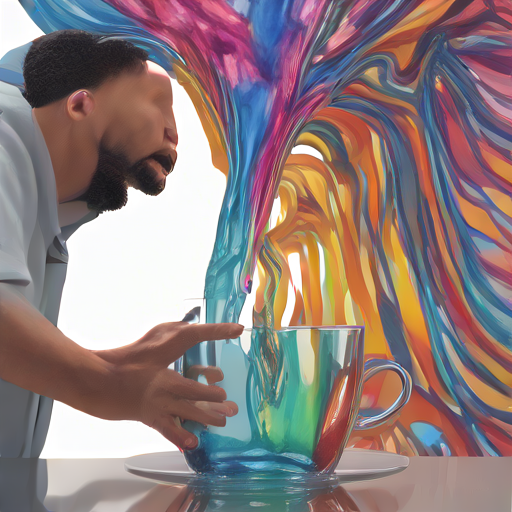

In [ ]:
prompt = "A man forces another man to drink water in a restaurant by pouring a glass of water down his throat\
We can see both man\
The style is abstract, all the colors of the rainbow, as if acrylic had been spilled, 3D render"
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
image.save("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/diffusion/mans.png")
image

  0%|          | 0/1 [00:00<?, ?it/s]

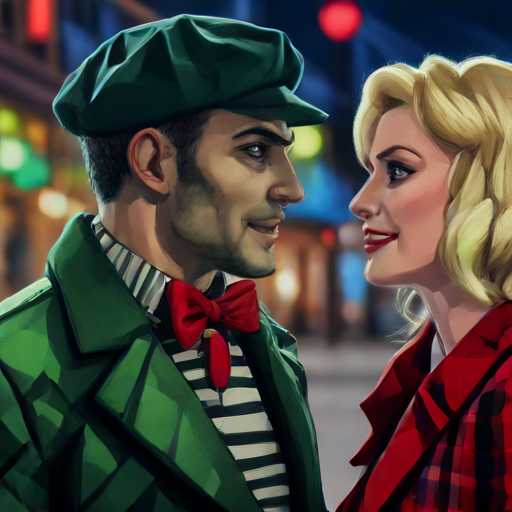

In [ ]:
prompt = "A man in green face paint wearing a black beret, \
striped shirt and red bow tie talking to a blonde woman in a checkered coat, \
night scene outdoors, cinematic lighting, vivid colors, shallow depth of field, film still\
Low-poly geometric style, triangular facets, vibrant colors, 3D render"

# Передаем prompt в pipe, указываем параметры
# Модель проводит генерацию картинки, соответствующей запросу
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
image.save("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/diffusion/man_with_green_face.png")
image

In [ ]:
def visualize_all_style_transfer(content_image, style_image, results_path, diffusion_images):
    """
    Визуализация результатов.

    :param content_image: имя файла картинки контента
    :param style_image: имя файла картинки стиля
    :param results_path: путь к папке, в которую сохранился результат
    """
    if len(os.listdir(results_path)) == 0:
        return

    PATH = "/content/drive/MyDrive/Colab Notebooks/Введение_в_АД"
    data_dir = os.path.join(PATH, "Data")

    plt.figure(figsize=(13, 3))

    combined_image = Path(content_image).stem + "_" + Path(style_image).stem + ".jpg"

    image_paths = [
        os.path.join(data_dir, "content-images", content_image),
        os.path.join(results_path, combined_image),
        os.path.join(data_dir, "diffusion", diffusion_image),
        os.path.join(data_dir, "style-images", style_image),
    ]

    titles = ["Контент", "Результат Neural-Style-Transfer", "Результат diffusion", "Стиль"]

    for i in range(len(image_paths)):
        plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(plt.imread(image_paths[i]))
        plt.title(titles[i])
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

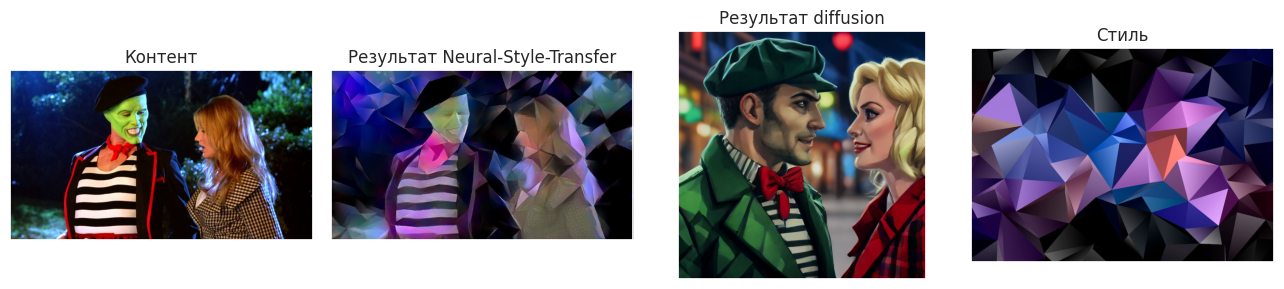

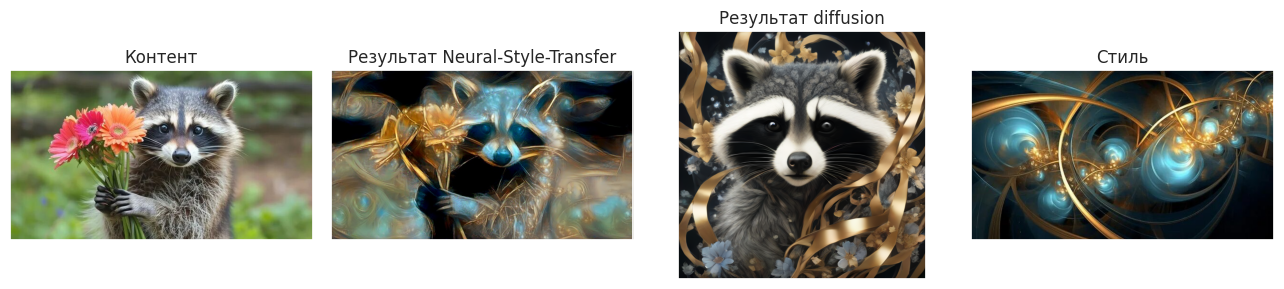

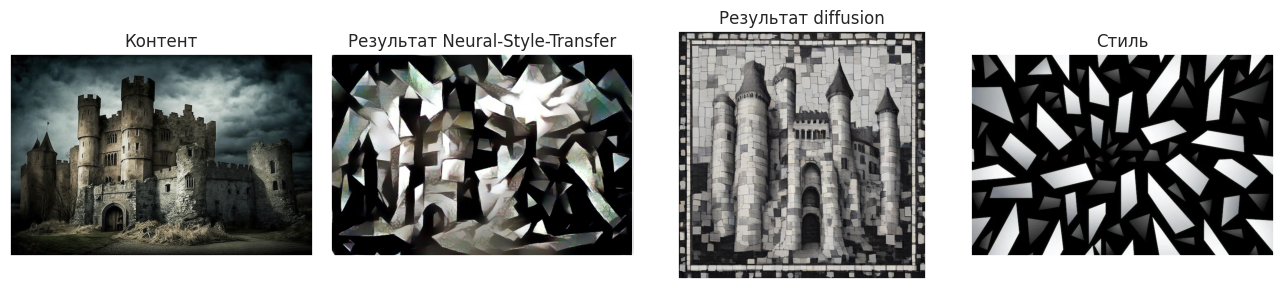

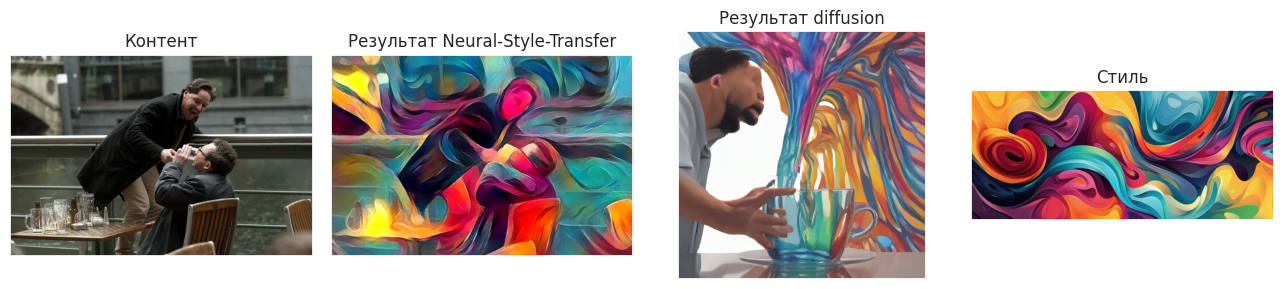

In [ ]:
diffusion_images = ['man_with_green_face.png',  'raccoon.png' ,'castle.png', 'mans.png']
content_images = sorted(os.listdir("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/content-images"))
style_images = sorted(os.listdir("/content/drive/MyDrive/Colab Notebooks/Введение_в_АД/Data/style-images"))
for content_image, style_image, results_path, diffusion_image in zip(
    content_images, style_images, result_paths, diffusion_images
):
  visualize_all_style_transfer(content_image, style_image, results_path, diffusion_image)

**Вывод:**

Для промптов нужно задавать конкретные словосочетания. Такие как scinematic scene, dark patterns или vivid colors. Вот тут gpt хорошо написала, что использовать можно. https://chatgpt.com/share/69c6425a-06f0-8328-8ece-e07573661423

- диффузионная модель хорошо восстановила из контента
- Получилось словами передать стиль
- diffusion уступает nst в правдоподобии, так как diffusion генерирует изображения, а nst использует уже готовые. Видно, что человек совсем не похож на человека в 4-м примере.
- Если задать правильный промпт, то diffusion работает очень правдоподобно. Но проблема в том, что не все можно и не все просто описать словами.
- diffusion дает более свободную генерацию, но хуже гарантирует соответствие контенту

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД